# Clustering des profils humains — approche à deux étages

**Objectif** : identifier des profils de comportement d'occupants à partir du CO₂,
en préservant la temporalité (144 points / jour).

| Étage | Unité | Signal | Résultat |
|---|---|---|---|
| 1 | journée (logement, date) | dérivée du CO₂ z-normalisé, 144 pts | K day-types ("journées types") |
| 2 | logement | histogramme des day-types + entropie | profils de logements |

**Choix méthodologiques** :
- **Dérivée seule** (pas le niveau) : le niveau reflète le bâtiment, la dérivée les
  événements humains (montée = présence, descente = aération/départ)
- **Z-normalisation par logement** avant dérivée : enlève l'effet baseline/volume
- **Pas de DTW** : les journées sont alignées sur l'horloge et l'ancrage horaire
  est justement l'information comportementale
- **Ventilation en validation** (pas dans le clustering) : constante par logement,
  elle regrouperait les journées par bâtiment et non par comportement


## 1. Configuration et chargement

In [2]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import savgol_filter
from tslearn.clustering import TimeSeriesKMeans
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

sns.set_theme(style='whitegrid', font_scale=1.05)
plt.rcParams['figure.dpi'] = 110
pd.set_option('display.max_columns', 60)

DATA = '../data/cln1/Raw'

SG_WINDOW   = 13      # fenêtre Savitzky-Golay (points de 10 min -> 30 min)
SG_POLY     = 2      # ordre du polynôme

In [3]:
# Chargement de la série CO2
co2 = pd.read_csv(f'{DATA}/Mesures_Confort_Dynamique/CNL1_SERIE_CO2.txt',
                  sep='\t', encoding='latin1',
                  usecols=['CODELIEU', 'DATE_HEURE', 'VALEUR'],
                  parse_dates=['DATE_HEURE'])
co2['VALEUR'] = pd.to_numeric(co2['VALEUR'], errors='coerce')
co2 = co2.dropna(subset=['VALEUR'])

co2['DATE'] = co2['DATE_HEURE'].dt.normalize()
co2['slot'] = co2['DATE_HEURE'].dt.hour * 6 + co2['DATE_HEURE'].dt.minute // 10

print(f'{len(co2):,} mesures — {co2["CODELIEU"].nunique()} logements')


514,425 mesures — 535 logements


In [4]:
# Référentiels partagés 

pieces_ref = pd.read_csv(f'{DATA}/Identite_Logement/CNL1_LISTE_PIECE.csv',
                         sep=';', encoding='utf-16')
cap = (pd.read_csv(f'{DATA}/Mesures_Confort_Dynamique/CNL1_SERIE_CO2.txt',
                  sep='\t', encoding='latin1',
                  usecols=['CODELIEU', 'IDN_PIECE'])
       .groupby('CODELIEU')['IDN_PIECE'].first())
cap_type = cap.map(pieces_ref.set_index('IDN_PIECE')['TYPEPIECE'])

# Type de ventilation (KVNT) par logement
KVNT_LABELS = {1: 'VMC', 2: 'Extracteurs', 3: 'Naturelle', 4: 'Aucune'}
ventilation = pd.read_csv(f'{DATA}/Questionnaires_Comportement/CNL1_Q_LOGEMENT_MENAGE_DATA.csv',
                          sep=';', encoding='latin1', usecols=['CODELIEU', 'KVNT'])
ventilation['KVNT'] = pd.to_numeric(ventilation['KVNT'], errors='coerce')
ventilation = ventilation.assign(
    aeration=lambda d: d['KVNT'].map(KVNT_LABELS)).set_index('CODELIEU')['aeration']

# Semainier (présence par pièce, 7 jours) et carnet journalier (activités, 1 jour)
sem = pd.read_csv(f'{DATA}/Questionnaires_Comportement/CNL1_SEMAINIER_DATA.txt',
                  sep='\t', encoding='latin1')
sem['DATE'] = pd.to_datetime(sem['DATE'], format='%d/%m/%Y')

journalier = pd.read_csv(f'{DATA}/Questionnaires_Comportement/CNL1_JOURNALIER_DATA.csv',
                         sep=';', encoding='latin1',
                         usecols=['CODELIEU', 'NUM_OCCUPANT', 'CODE_HEURE',
                                  'ACTIV_A', 'ACTIV_B', 'ACTIV_C'])

ib = pd.read_csv(f'{DATA}/Questionnaires_Comportement/CNL1_INFOS_BETA.csv',
                 sep=';', encoding='utf-16',
                 usecols=['CODELIEU', 'NUM_OCCUPANT', 'DATE_JOURNALIER'])

# Correspondance CODE_HEURE -> heure du jour (V_1001..V_1144 = 00h00..24h00)
heures = pd.read_excel(f'{DATA}/Dictionnaires/CNL1_BETA_DICO.xlsx',
                       sheet_name='Table_correspondance_heures')
hm = heures['TRANCHE_HORAIRE'].str.extract(r'(\d+)h(\d+)').astype(float)
heures['h_debut'] = hm[0] + hm[1] / 60
grille_jour = heures.loc[~heures['TRANCHE_HORAIRE'].str.startswith('veille'),
                        'h_debut'].sort_values().to_numpy()

# Constantes partagées par les fonctions d'affichage (affiche_logement, affiche_journee)
IDN_EXTERIEUR = 90   # LISTE_PIECE : 90 = EXT0 "Extérieur"
ACT_DORS      = 1    # "JE DORS"
ACT_DEJEUNE   = 9    # "JE DEJEUNE"
ACT_SORS      = 10   # "JE SORS"
ACT_DINE      = 13   # "JE DINE"
ACT_RENTRE    = 17   # "JE RENTRE"
ACT_AERE      = 29   # "J'AERE"
ACT_CUISINE   = 30   # "JE FAIS LA CUISINE"
ACT_SPORT     = 59   # "JE FAIS MA SEANCE DE SPORT"

HTICKS = range(0, 25, 2)
HLABELS = [f'{h}h' for h in HTICKS]
SLOT_H = 1 / 6

print(f'{len(pieces_ref)} pièces référencées — {len(ventilation)} logements avec KVNT — '
      f'{sem["CODELIEU"].nunique()} logements dans le semainier')


62 pièces référencées — 567 logements avec KVNT — 519 logements dans le semainier


## 2. Distribution du CO2

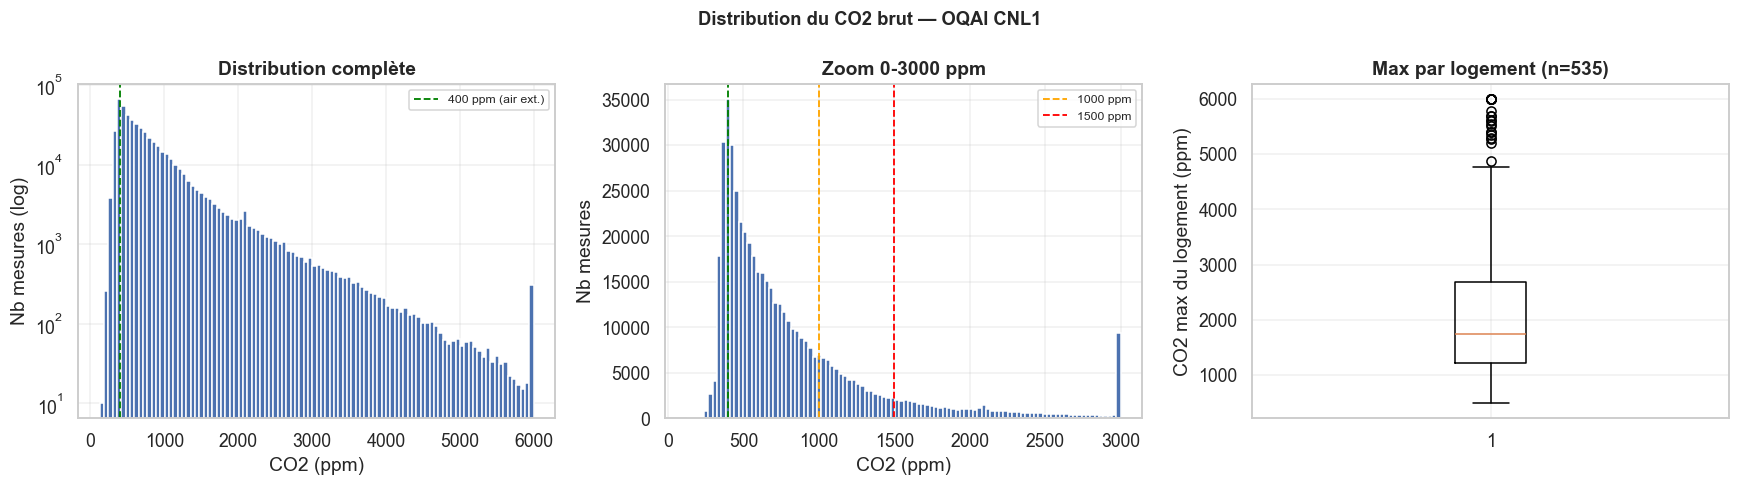

In [5]:
# Distribution du CO2 brut — recherche d'outliers
vals = co2['VALEUR']

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# Histogramme complet (échelle log en y pour voir la queue)
ax = axes[0]
ax.hist(vals, bins=100, color='#4C72B0', edgecolor='white')
ax.set_yscale('log')
ax.axvline(400, color='green', ls='--', lw=1.2, label='400 ppm (air ext.)')
ax.set_xlabel('CO2 (ppm)'); ax.set_ylabel('Nb mesures (log)')
ax.set_title('Distribution complète', fontweight='bold')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# Zoom 0-3000 ppm
ax = axes[1]
ax.hist(vals.clip(upper=3000), bins=100, color='#4C72B0', edgecolor='white')
ax.axvline(400, color='green', ls='--', lw=1.2)
ax.axvline(1000, color='orange', ls='--', lw=1.2, label='1000 ppm')
ax.axvline(1500, color='red', ls='--', lw=1.2, label='1500 ppm')
ax.set_xlabel('CO2 (ppm)'); ax.set_ylabel('Nb mesures')
ax.set_title('Zoom 0-3000 ppm', fontweight='bold')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# Boxplot du max par logement (les outliers viennent-ils de quelques capteurs ?)
ax = axes[2]
max_par_log = co2.groupby('CODELIEU')['VALEUR'].max()
ax.boxplot(max_par_log, vert=True)
ax.set_ylabel('CO2 max du logement (ppm)')
ax.set_title(f'Max par logement (n={len(max_par_log)})', fontweight='bold')
ax.grid(True, alpha=0.3)

plt.suptitle('Distribution du CO2 brut — OQAI CNL1', fontweight='bold', fontsize=12)
plt.tight_layout(); plt.show()

### 2.1 Journées avec valeurs saturées à 6000 ppm

19 journées touchées par la saturation (8 logements)

CODELIEU       DATE  n_sat
 01-M020 2004-10-19     22
 01-M020 2004-10-20     19
 01-M020 2004-10-21     13
 02-M040 2004-04-27      5
 02-M047 2004-04-07     11
 02-M047 2004-04-09      8
 02-M047 2004-04-10     31
 02-M047 2004-04-11     19
 02-M047 2004-04-12     28
 02-M047 2004-04-13     14
 03-M052 2004-04-06      4
 03-M052 2004-04-07      8
 05-M060 2004-05-09     24
 06-M015 2003-10-13     15
 06-M015 2003-10-14     23
 06-M015 2003-10-15      4
 06-M015 2003-10-20      6
 10-M031 2005-10-24     10
 12-M011 2003-10-30     20


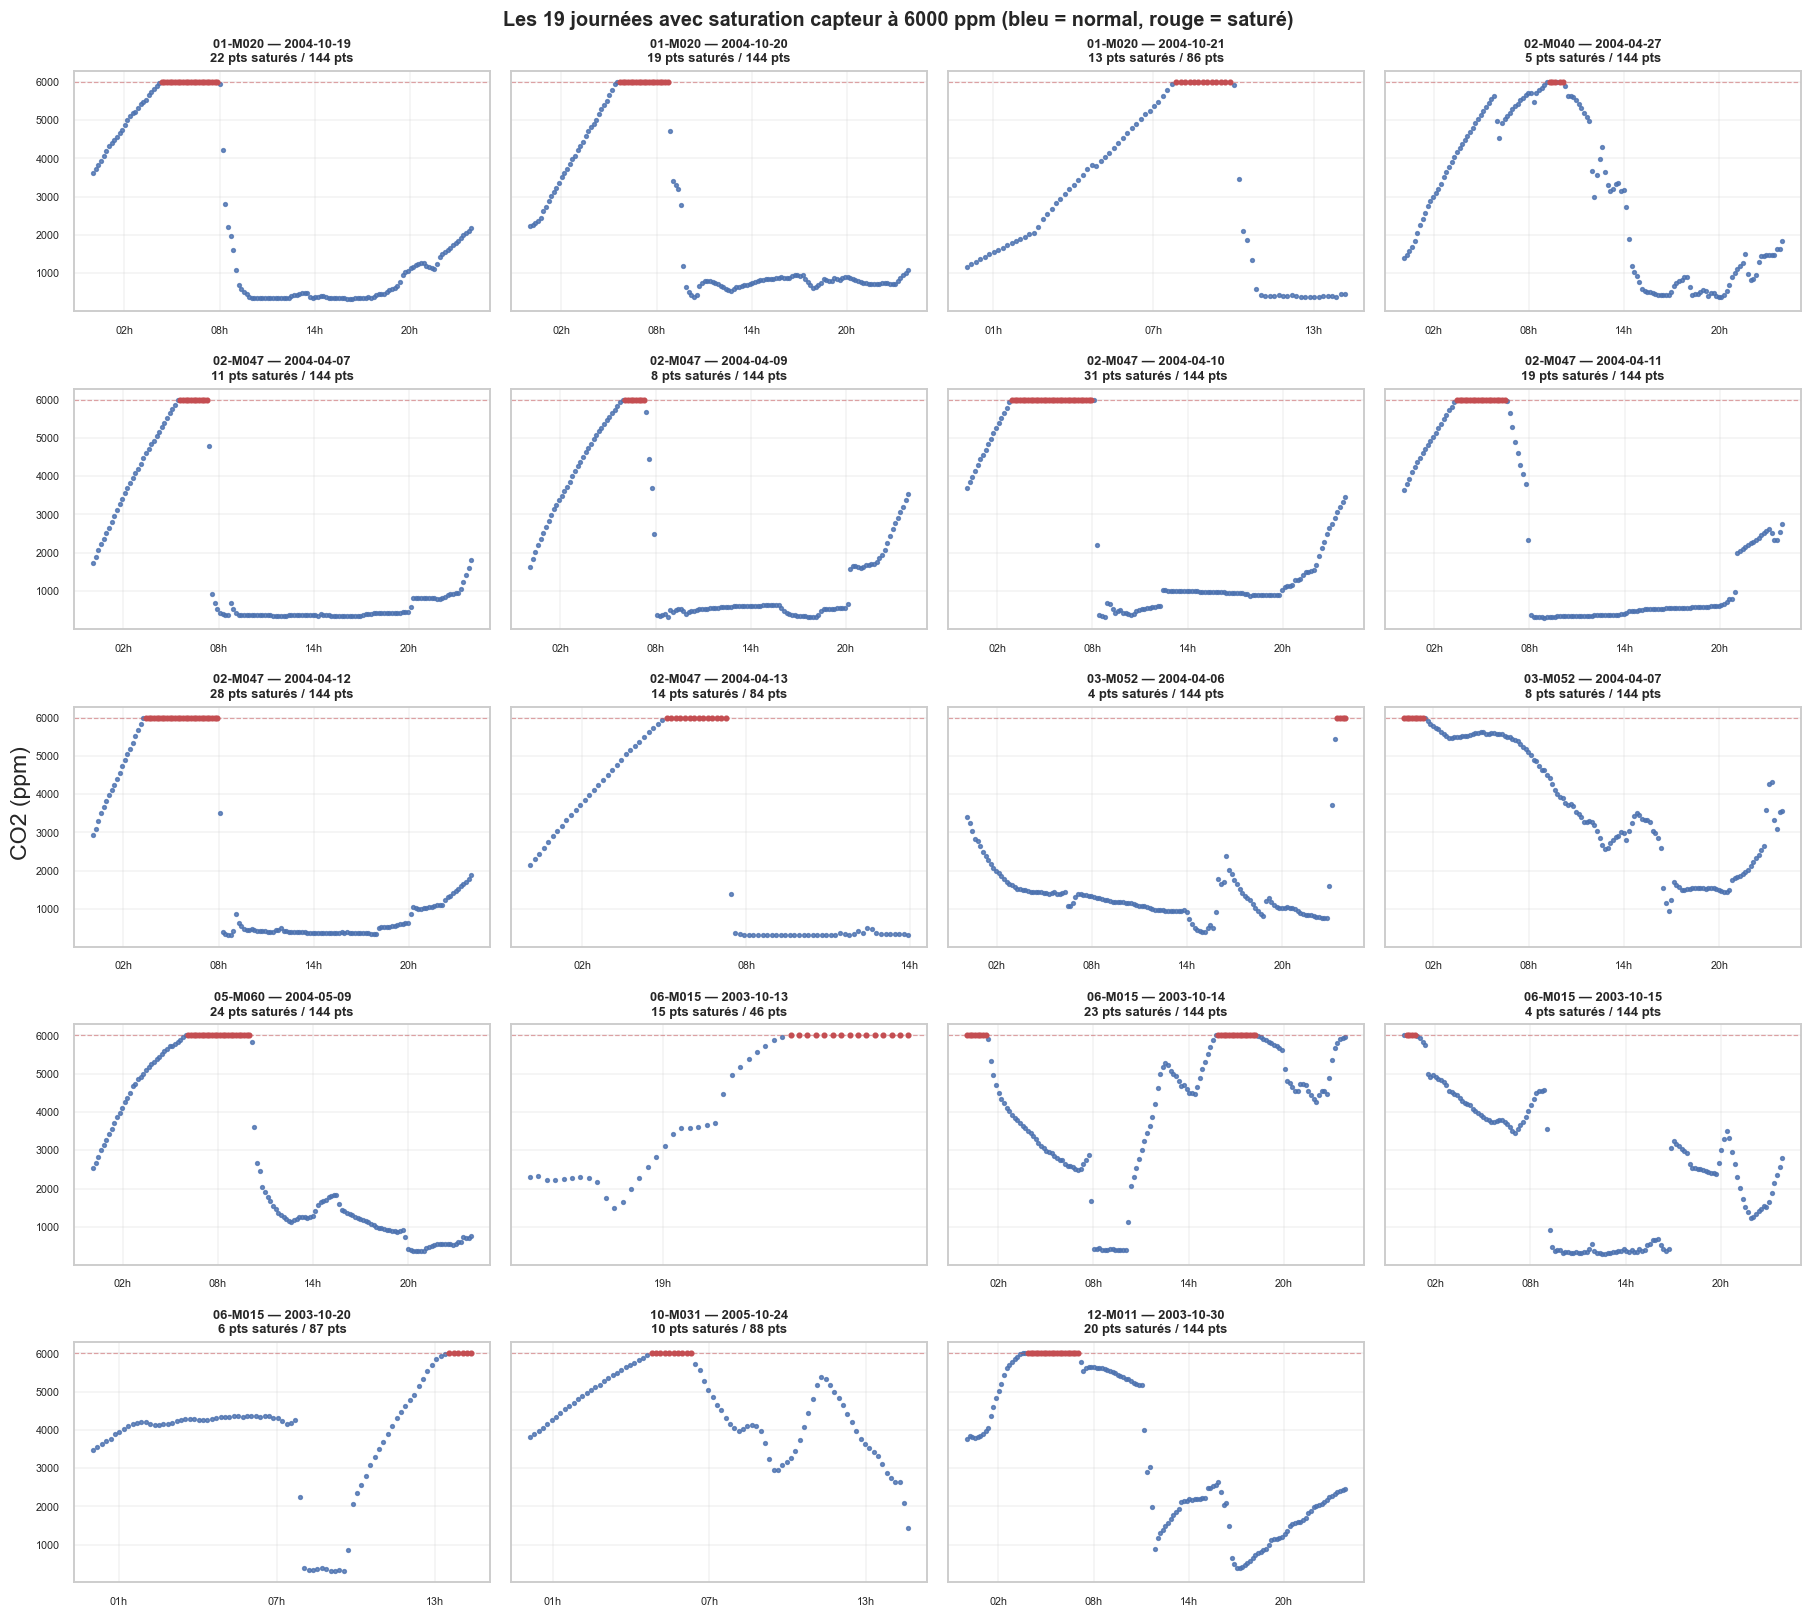

In [36]:
# Les 19 journées contenant des mesures saturées à 6000 ppm — points bruts
import matplotlib.dates as mdates

sat = co2[co2['VALEUR'] >= 6000]
jours_sat = (sat.groupby(['CODELIEU', 'DATE']).size()
             .rename('n_sat').reset_index()
             .sort_values(['CODELIEU', 'DATE']))
print(f'{len(jours_sat)} journées touchées par la saturation '
      f'({jours_sat["CODELIEU"].nunique()} logements)\n')
print(jours_sat.to_string(index=False))

n_plots = len(jours_sat)
n_cols = 4
n_rows = int(np.ceil(n_plots / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.2*n_cols, 3*n_rows), sharey=True)
axes = axes.ravel()

for ax, (_, row) in zip(axes, jours_sat.iterrows()):
    jour_sat = co2[(co2['CODELIEU'] == row['CODELIEU'])
                   & (co2['DATE'] == row['DATE'])].sort_values('DATE_HEURE')
    est_sat = jour_sat['VALEUR'] >= 6000
    ax.scatter(jour_sat.loc[~est_sat, 'DATE_HEURE'], jour_sat.loc[~est_sat, 'VALEUR'],
               s=6, color='#4C72B0', alpha=0.8)
    ax.scatter(jour_sat.loc[est_sat, 'DATE_HEURE'], jour_sat.loc[est_sat, 'VALEUR'],
               s=9, color='#C44E52')
    ax.axhline(6000, color='#C44E52', ls='--', lw=0.8, alpha=0.5)
    ax.set_title(f"{row['CODELIEU']} — {row['DATE'].date()}\n"
                 f"{row['n_sat']} pts saturés / {len(jour_sat)} pts",
                 fontsize=8.5, fontweight='bold')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Hh'))
    ax.xaxis.set_major_locator(mdates.HourLocator(interval=6))
    ax.tick_params(labelsize=7)
    ax.grid(True, alpha=0.25)

for ax in axes[n_plots:]:
    ax.axis('off')

fig.supylabel('CO2 (ppm)')
plt.suptitle('Les 19 journées avec saturation capteur à 6000 ppm '
             '(bleu = normal, rouge = saturé)',
             fontweight='bold', fontsize=13)
plt.tight_layout(); plt.show()

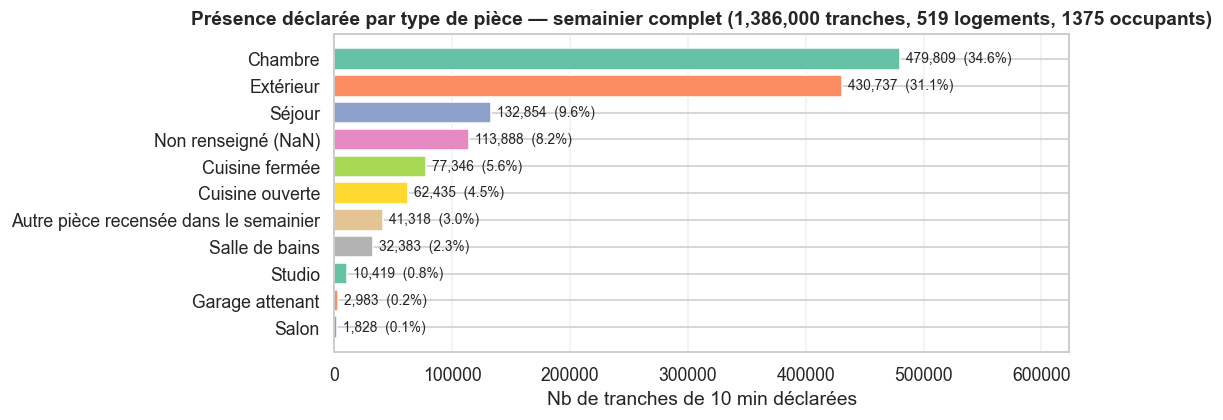

lieu
Chambre                                   479809
Extérieur                                 430737
Séjour                                    132854
Non renseigné (NaN)                       113888
Cuisine fermée                             77346
Cuisine ouverte                            62435
Autre pièce recensée dans le semainier     41318
Salle de bains                             32383
Studio                                     10419
Garage attenant                             2983
Salon                                       1828


In [37]:
# Distribution de la présence déclarée (semainier complet, toutes tranches)
sem_all = sem.merge(pieces_ref, on='IDN_PIECE', how='left')
sem_all['lieu'] = sem_all['TYPEPIECE'].fillna('Non renseigné (NaN)')

total = len(sem_all)
counts = sem_all['lieu'].value_counts()

fig, ax = plt.subplots(figsize=(10, max(4, 0.35 * len(counts))))
colors = sns.color_palette('Set2', len(counts))
bars = ax.barh(counts.index, counts.values, color=colors, edgecolor='white')
ax.bar_label(bars,
             labels=[f'{v:,}  ({100*v/total:.1f}%)' for v in counts.values],
             padding=4, fontsize=9)
ax.set_xlabel('Nb de tranches de 10 min déclarées')
ax.set_title(f'Présence déclarée par type de pièce — semainier complet '
             f'({total:,} tranches, {sem_all["CODELIEU"].nunique()} logements, '
             f'{sem_all.groupby("CODELIEU")["NUM_OCCUPANT"].nunique().sum()} occupants)',
             fontweight='bold')
ax.set_xlim(0, counts.max() * 1.30)
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)
plt.tight_layout(); plt.show()

print(counts.to_string())


## 3. Lissage Savitzky-Golay — exploration visuelle

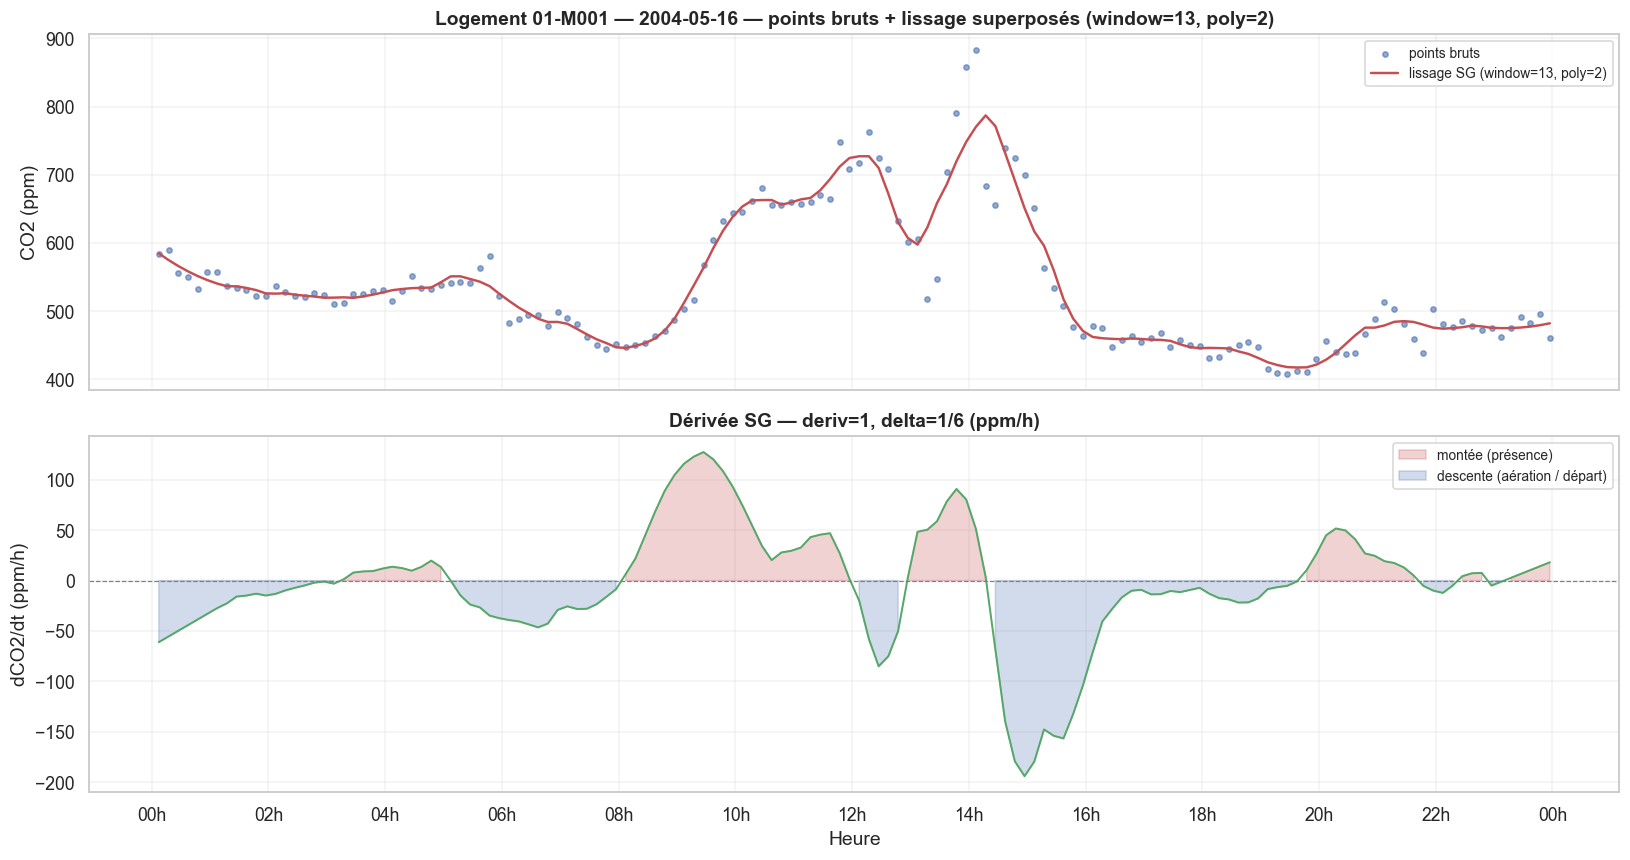

In [38]:
import matplotlib.dates as mdates

def plot_jour_zoom(jour_df, sg_window, sg_poly, titre):
    """Points bruts + lissage SG (panneau 1) et dérivée SG (panneau 2)
    pour une seule journée. Réutilisé pour comparer différents réglages
    ou différentes journées sans dupliquer le code de tracé."""
    vals  = jour_df['VALEUR'].to_numpy(dtype=float)
    lisse = savgol_filter(vals, sg_window, sg_poly)
    deriv = savgol_filter(vals, sg_window, sg_poly, deriv=1, delta=1/6)

    fig, axes = plt.subplots(2, 1, figsize=(15, 8), sharex=True)

    ax = axes[0]
    ax.scatter(jour_df['DATE_HEURE'], vals, s=12, color='#4C72B0', alpha=0.6,
               label='points bruts')
    ax.plot(jour_df['DATE_HEURE'], lisse, lw=1.6, color='#C44E52',
            label=f'lissage SG (window={sg_window}, poly={sg_poly})')
    ax.set_ylabel('CO2 (ppm)')
    ax.set_title(titre, fontweight='bold')
    ax.legend(fontsize=9); ax.grid(True, alpha=0.25)

    ax = axes[1]
    ax.plot(jour_df['DATE_HEURE'], deriv, lw=1.3, color='#55A868')
    ax.fill_between(jour_df['DATE_HEURE'], deriv, 0, where=deriv > 0, alpha=0.25,
                    color='#C44E52', label='montée (présence)')
    ax.fill_between(jour_df['DATE_HEURE'], deriv, 0, where=deriv < 0, alpha=0.25,
                    color='#4C72B0', label='descente (aération / départ)')
    ax.axhline(0, color='grey', lw=0.8, ls='--')
    ax.set_xlabel('Heure'); ax.set_ylabel('dCO2/dt (ppm/h)')
    ax.set_title('Dérivée SG — deriv=1, delta=1/6 (ppm/h)', fontweight='bold')
    ax.legend(fontsize=9); ax.grid(True, alpha=0.25)

    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Hh'))
    ax.xaxis.set_major_locator(mdates.HourLocator(interval=2))
    plt.tight_layout(); plt.show()


# Zoom sur une seule journée : points bruts + lissage SG + dérivée SG
ex_code = '01-M001'
JOUR    = '2004-05-16'   # journée à zoomer (logement ex_code)

serie_ex = co2[co2['CODELIEU'] == ex_code].sort_values('DATE_HEURE')
jour_ex  = serie_ex[serie_ex['DATE'] == JOUR]

plot_jour_zoom(jour_ex, SG_WINDOW, SG_POLY,
              f'Logement {ex_code} — {JOUR} — points bruts + lissage superposés '
              f'(window={SG_WINDOW}, poly={SG_POLY})')


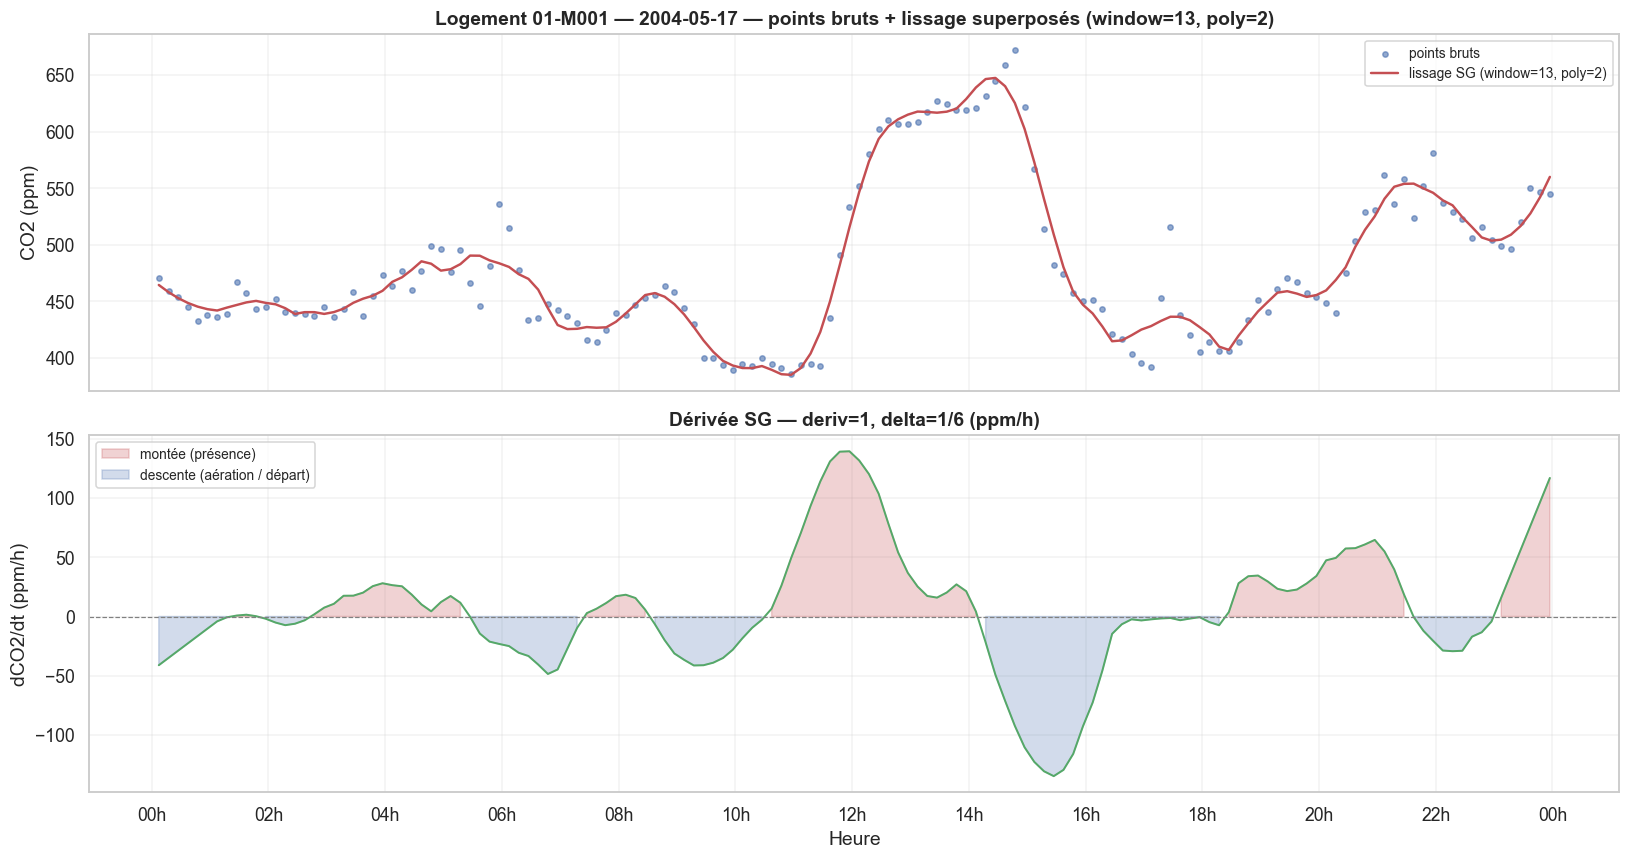

In [39]:
# Zoom sur la journée du lendemain — réutilise plot_jour_zoom (cellule précédente)
JOUR2 = (pd.Timestamp(JOUR) + pd.Timedelta(days=1)).strftime('%Y-%m-%d')

jour_ex2 = serie_ex[serie_ex['DATE_HEURE'].dt.normalize() == JOUR2].copy()

plot_jour_zoom(jour_ex2, SG_WINDOW, SG_POLY,
              f'Logement {ex_code} — {JOUR2} — points bruts + lissage superposés '
              f'(window={SG_WINDOW}, poly={SG_POLY})')


## 4. Étage 1 — Clustering des journées

### 4.1 Préparation : 144 points de dérivée par journée

## Dérivée CO2 — tenseur brut partagé

Construit la dérivée SG sur la série CO2 **continue** de chaque logement (pas
encore normalisée), pivotée en journées de 144 points (`piv_dco2`,
`piv_co2_lvl`, `meta_dtw`). Ce tenseur brut est réutilisé par toutes les
versions de DTW ci-dessous, qui normalisent ensuite **par journée**
(`daynorm_*`) plutôt que par logement.


In [6]:
# construction du tenseur 3D (n_samples, 144, 1) 

# CO2 : dérivée SG (poly=2, window=3) sur la série continue de chaque logement
co2_t = co2.sort_values(['CODELIEU', 'DATE_HEURE']).copy()
co2_t['deriv'] = (co2_t.groupby('CODELIEU')['VALEUR']
                  .transform(lambda x: savgol_filter(x, SG_WINDOW, SG_POLY, deriv=1, delta=1/6)))

# Journées à exactement 144 mesures, slots par rang chronologique
n = co2_t.groupby(['CODELIEU', 'DATE'])['VALEUR'].transform('size')
co2_t = co2_t[n == 144]
co2_t['rang'] = co2_t.groupby(['CODELIEU', 'DATE']).cumcount()
piv_dco2 = co2_t.pivot(index=['CODELIEU', 'DATE'], columns='rang', values='deriv')

# Exclusion des journées saturées (>= 6000 ppm)
piv_co2_lvl = co2_t.pivot(index=['CODELIEU', 'DATE'], columns='rang', values='VALEUR')
piv_dco2 = piv_dco2.drop(piv_co2_lvl.index[(piv_co2_lvl.values >= 6000).any(axis=1)])

# Empilement -> (n_samples, 144, 1)
X = piv_dco2.values[:, :, None]
meta_dtw = piv_dco2.index.to_frame(index=False)
print(f'Tenseur X : {X.shape}  (canal : dCO2/dt) — '
      f'{meta_dtw["CODELIEU"].nunique()} logements')


Tenseur X : (2998, 144, 1)  (canal : dCO2/dt) — 513 logements


## Comparabilité de la dérivée CO2 à différentes échelles

Suggestion du tuteur de stage : avant de choisir une normalisation, évaluer
empiriquement à quel niveau les données deviennent réellement incomparables,
en regardant la distribution des valeurs de dérivée à 4 échelles croissantes :

1. **Une journée, un logement** — pas de normalisation (même capteur, même
   contexte physique).
2. **Toutes les journées d'un même logement** — pas de normalisation non
   plus (toujours le même logement).
3. **Plusieurs logements, une seule journée** (celle où le plus de logements
   sont disponibles simultanément) — normalisation nécessaire : la courbe
   CO2 brute est normalisée **par logement/jour**, puis dérivée (plutôt que
   l'inverse), pour comparer brut vs normalisé sur ce même jour.
4. **Toutes les journées x tous les logements** — même normalisation
   (courbe → puis dérivée) appliquée à l'ensemble, brut vs normalisé.


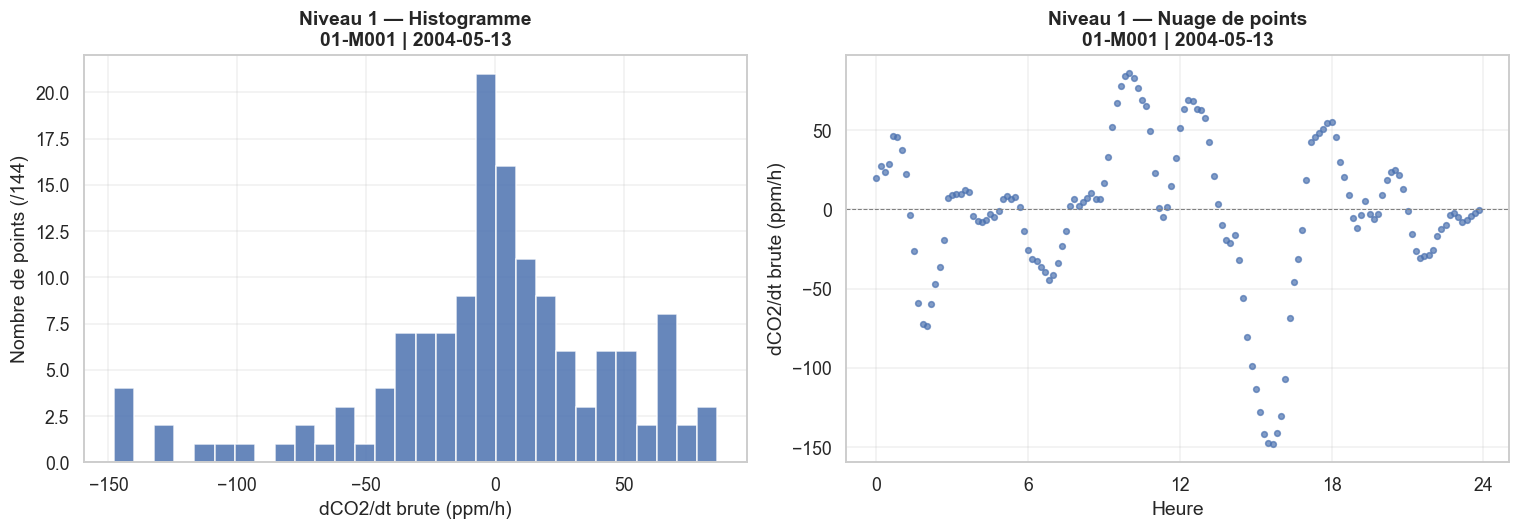

01-M001 — 2004-05-13 : min=-147.8, max=86.0, std=47.4 ppm/h


In [8]:
# Niveau 1
hours = np.arange(144) / 6
idx1 = 0   # première journée valide du jeu de données (arbitraire mais déterministe)
code1, date1 = meta_dtw.loc[idx1, 'CODELIEU'], meta_dtw.loc[idx1, 'DATE']
vals1 = piv_dco2.values[idx1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(vals1, bins=30, color='#4C72B0', alpha=0.85)
axes[0].set_title(f'Niveau 1 — Histogramme\n{code1} | {date1.date()}', fontweight='bold')
axes[0].set_xlabel('dCO2/dt brute (ppm/h)'); axes[0].set_ylabel('Nombre de points (/144)')
axes[0].grid(True, alpha=0.3)

axes[1].scatter(hours, vals1, s=14, color='#4C72B0', alpha=0.7)
axes[1].axhline(0, color='grey', lw=0.7, ls='--')
axes[1].set_title(f'Niveau 1 — Nuage de points\n{code1} | {date1.date()}', fontweight='bold')
axes[1].set_xlabel('Heure'); axes[1].set_ylabel('dCO2/dt brute (ppm/h)')
axes[1].set_xticks([0, 6, 12, 18, 24])
axes[1].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

print(f'{code1} — {date1.date()} : min={vals1.min():.1f}, max={vals1.max():.1f}, '
      f'std={vals1.std():.1f} ppm/h')


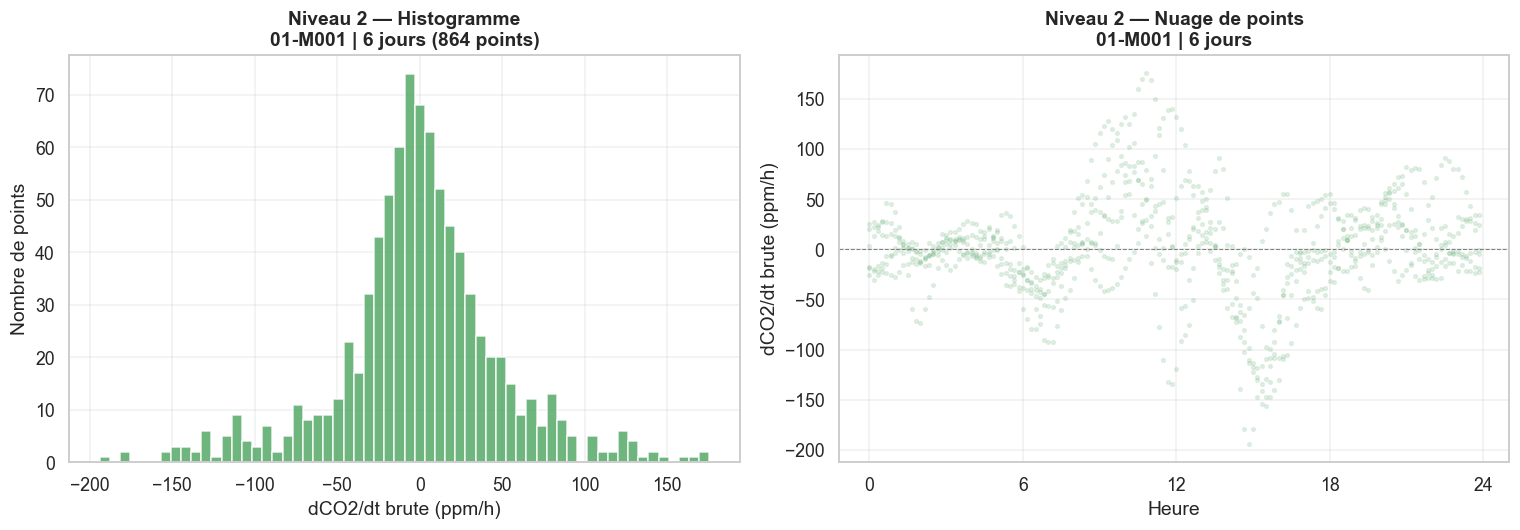

01-M001 : 6 journées, écart-type global = 49.8 ppm/h


In [9]:
# Niveau 2 
code2 = code1   # même logement que niveau 1, pour comparaison directe
sel2 = (meta_dtw['CODELIEU'] == code2).to_numpy()
vals2_2d = piv_dco2.values[sel2]           # (n_jours, 144)
vals2 = vals2_2d.ravel()
hours_rep2 = np.tile(hours, vals2_2d.shape[0])   # heure de chaque point (aligné avec vals2)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(vals2, bins=60, color='#55A868', alpha=0.85)
axes[0].set_title(f'Niveau 2 — Histogramme\n{code2} | {sel2.sum()} jours ({len(vals2):,} points)',
                  fontweight='bold')
axes[0].set_xlabel('dCO2/dt brute (ppm/h)'); axes[0].set_ylabel('Nombre de points')
axes[0].grid(True, alpha=0.3)

axes[1].scatter(hours_rep2, vals2, s=6, color='#55A868', alpha=0.15)
axes[1].axhline(0, color='grey', lw=0.7, ls='--')
axes[1].set_title(f'Niveau 2 — Nuage de points\n{code2} | {sel2.sum()} jours', fontweight='bold')
axes[1].set_xlabel('Heure'); axes[1].set_ylabel('dCO2/dt brute (ppm/h)')
axes[1].set_xticks([0, 6, 12, 18, 24])
axes[1].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

print(f'{code2} : {sel2.sum()} journées, écart-type global = {vals2.std():.1f} ppm/h')


Date avec le plus de logements disponibles : 2004-03-14 (16 logements)


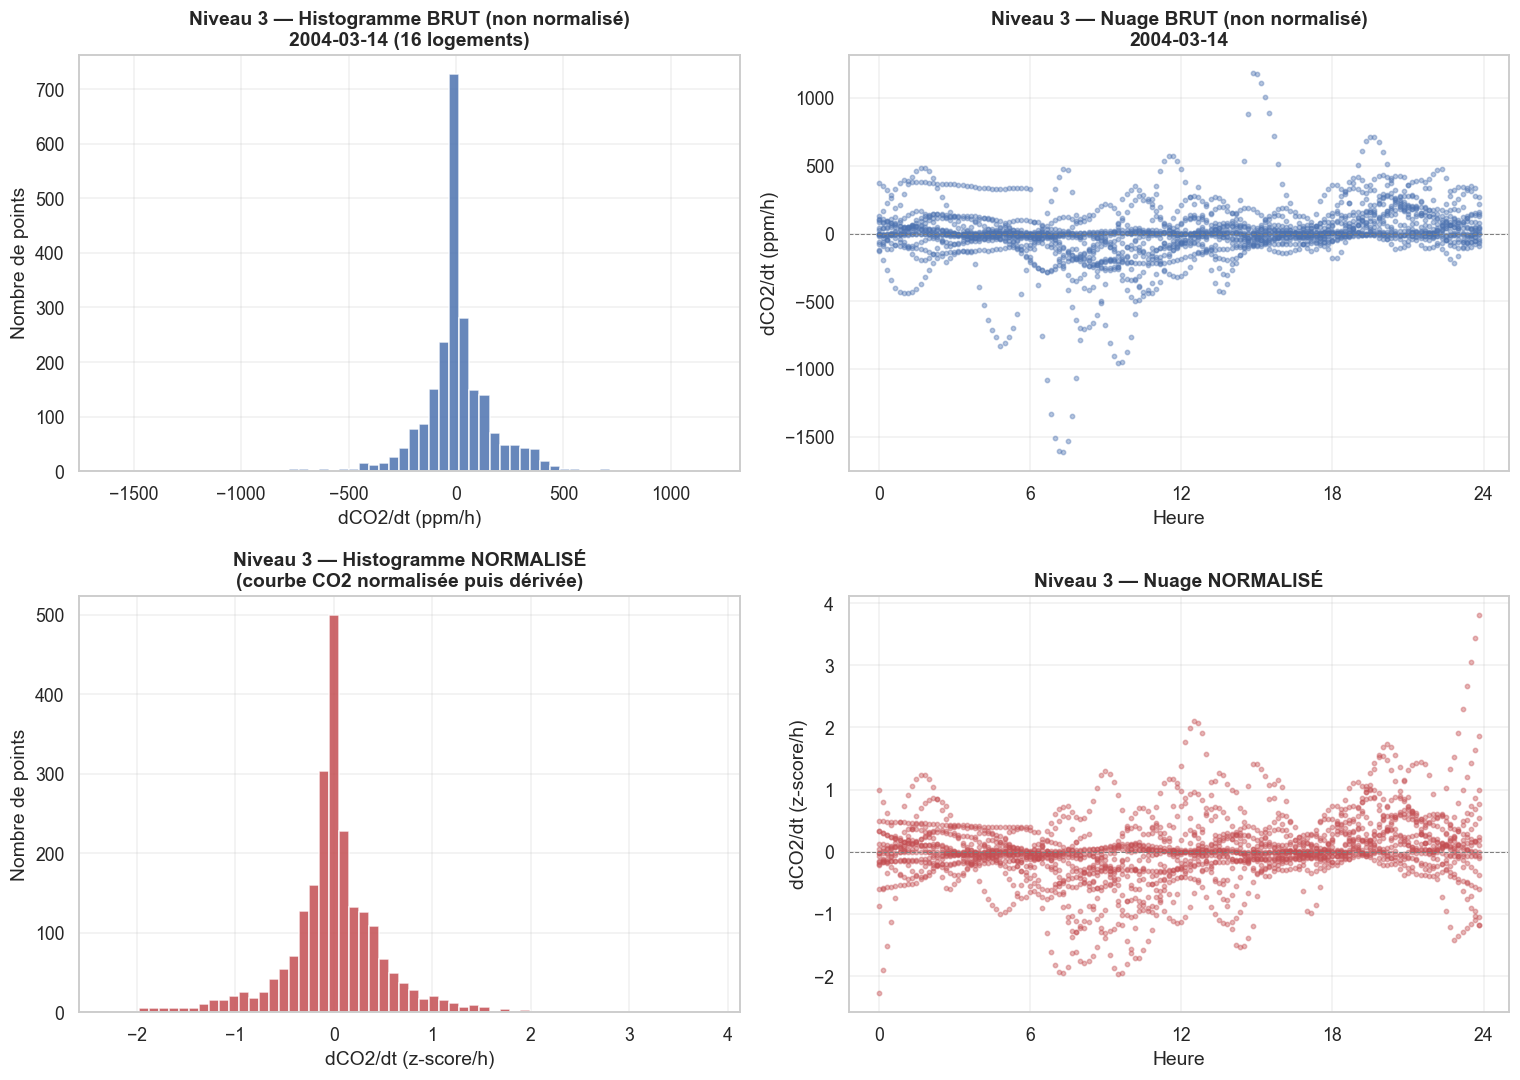

In [10]:
# Niveau 3 : plusieurs logements, LA journée avec le plus de logements disponibles
# Normalisation : courbe CO2 brute normalisée PAR LOGEMENT/JOUR, PUIS dérivée
counts_by_date = meta_dtw.groupby('DATE')['CODELIEU'].nunique()
best_date = counts_by_date.idxmax()
n_logs_best = counts_by_date.max()
print(f'Date avec le plus de logements disponibles : {best_date.date()} ({n_logs_best} logements)')

sel3 = np.where((meta_dtw['DATE'] == best_date).to_numpy())[0]
raw_co2_lvl = piv_co2_lvl.loc[piv_dco2.index].values   # aligné sur piv_dco2 / meta_dtw

vals3_raw_2d = piv_dco2.values[sel3]        # (n_logements, 144), dérivée brute ce jour-là
vals3_raw = vals3_raw_2d.ravel()
hours_rep3 = np.tile(hours, vals3_raw_2d.shape[0])

# Normalisation de la courbe CO2 (par logement/jour), PUIS dérivée
vals3_norm_list = []
for i in sel3:
    co2_curve = raw_co2_lvl[i]
    mu, sig = co2_curve.mean(), co2_curve.std()
    co2_norm = (co2_curve - mu) / max(sig, 1e-9)
    vals3_norm_list.append(savgol_filter(co2_norm, SG_WINDOW, SG_POLY, deriv=1, delta=1/6))
vals3_norm_2d = np.array(vals3_norm_list)
vals3_norm = vals3_norm_2d.ravel()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].hist(vals3_raw, bins=60, color='#4C72B0', alpha=0.85)
axes[0, 0].set_title(f'Niveau 3 — Histogramme BRUT (non normalisé)\n{best_date.date()} ({n_logs_best} logements)',
                     fontweight='bold')
axes[0, 0].set_xlabel('dCO2/dt (ppm/h)'); axes[0, 0].set_ylabel('Nombre de points')
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].scatter(hours_rep3, vals3_raw, s=8, color='#4C72B0', alpha=0.4)
axes[0, 1].axhline(0, color='grey', lw=0.7, ls='--')
axes[0, 1].set_title(f'Niveau 3 — Nuage BRUT (non normalisé)\n{best_date.date()}', fontweight='bold')
axes[0, 1].set_xlabel('Heure'); axes[0, 1].set_ylabel('dCO2/dt (ppm/h)')
axes[0, 1].set_xticks([0, 6, 12, 18, 24])
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].hist(vals3_norm, bins=60, color='#C44E52', alpha=0.85)
axes[1, 0].set_title('Niveau 3 — Histogramme NORMALISÉ\n(courbe CO2 normalisée puis dérivée)',
                     fontweight='bold')
axes[1, 0].set_xlabel('dCO2/dt (z-score/h)'); axes[1, 0].set_ylabel('Nombre de points')
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].scatter(hours_rep3, vals3_norm, s=8, color='#C44E52', alpha=0.4)
axes[1, 1].axhline(0, color='grey', lw=0.7, ls='--')
axes[1, 1].set_title('Niveau 3 — Nuage NORMALISÉ', fontweight='bold')
axes[1, 1].set_xlabel('Heure'); axes[1, 1].set_ylabel('dCO2/dt (z-score/h)')
axes[1, 1].set_xticks([0, 6, 12, 18, 24])
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()


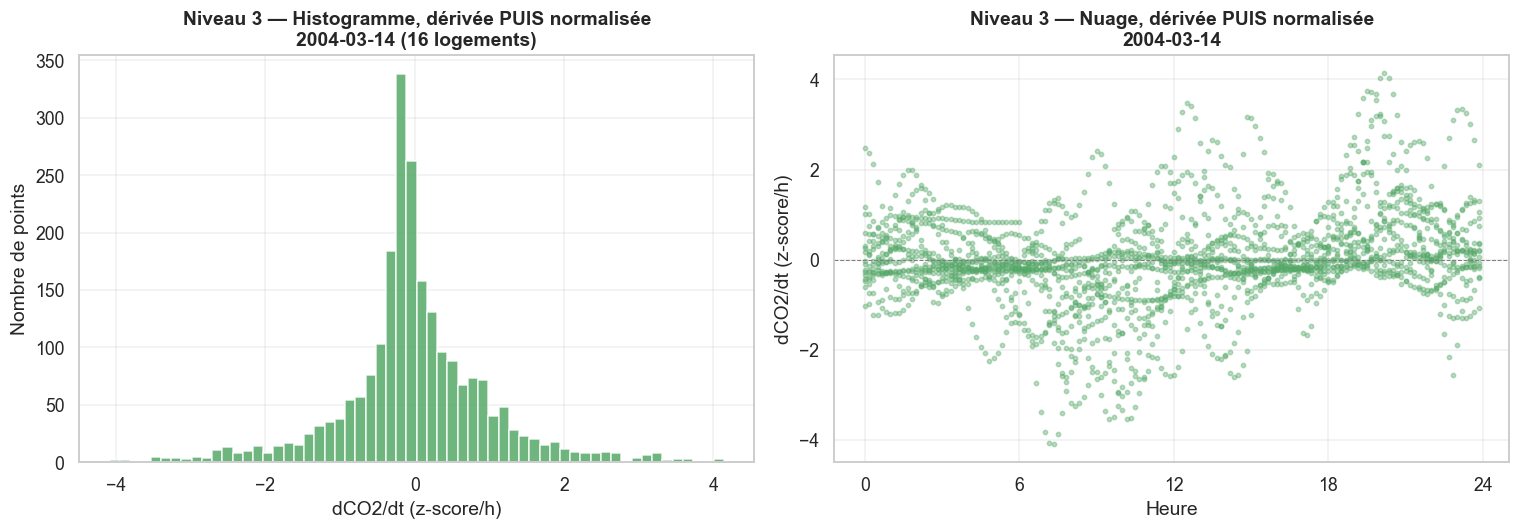

In [11]:
# Niveau 3 (variante) — dérivée BRUTE (déjà calculée) PUIS normalisée par journée
# (au lieu de normaliser la courbe CO2 avant de dériver) — comme D_day dans daynorm_prep
mu_d3 = vals3_raw_2d.mean(axis=1, keepdims=True)
sig_d3 = vals3_raw_2d.std(axis=1, keepdims=True)
vals3_derivnorm = ((vals3_raw_2d - mu_d3) / np.clip(sig_d3, 1e-9, None)).ravel()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(vals3_derivnorm, bins=60, color='#55A868', alpha=0.85)
axes[0].set_title(f'Niveau 3 — Histogramme, dérivée PUIS normalisée\n{best_date.date()} ({n_logs_best} logements)',
                  fontweight='bold')
axes[0].set_xlabel('dCO2/dt (z-score/h)'); axes[0].set_ylabel('Nombre de points')
axes[0].grid(True, alpha=0.3)

axes[1].scatter(hours_rep3, vals3_derivnorm, s=8, color='#55A868', alpha=0.4)
axes[1].axhline(0, color='grey', lw=0.7, ls='--')
axes[1].set_title(f'Niveau 3 — Nuage, dérivée PUIS normalisée\n{best_date.date()}', fontweight='bold')
axes[1].set_xlabel('Heure'); axes[1].set_ylabel('dCO2/dt (z-score/h)')
axes[1].set_xticks([0, 6, 12, 18, 24])
axes[1].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()


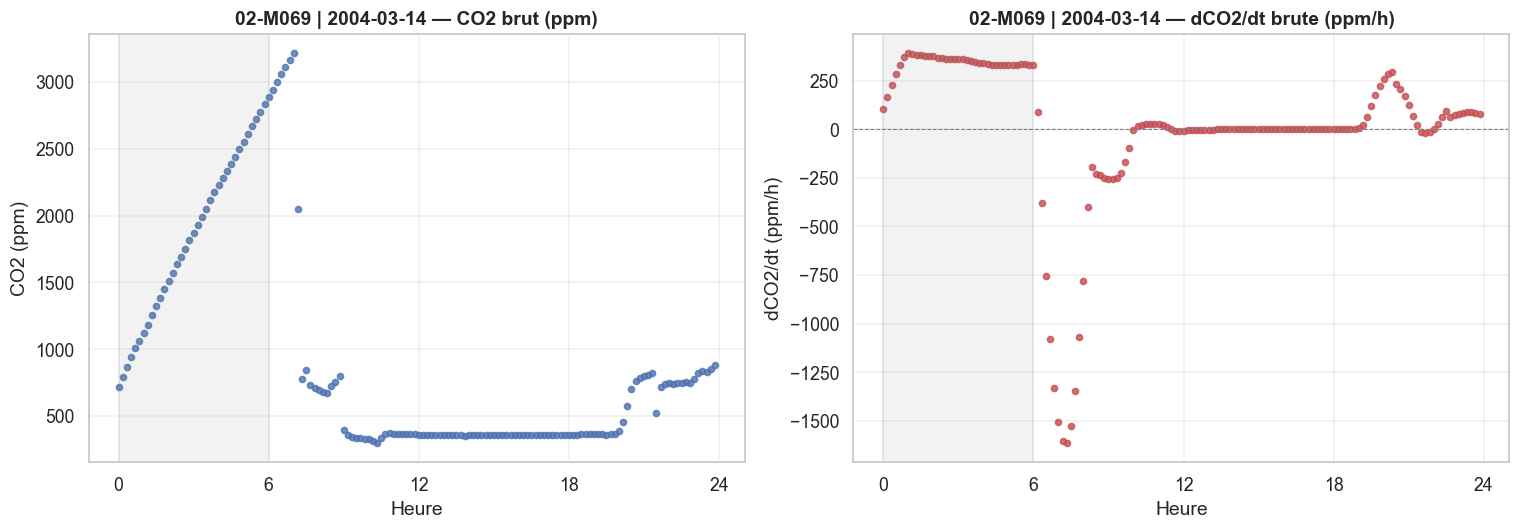

02-M069 | 2004-03-14 — 0h-6h : std=57.29, min=102.10, max=391.25 ppm/h
CO2 sur 0h-6h : min=720, max=2887 ppm


In [12]:
# Zoom sur la journée quasi-plate repérée dans le nuage "dérivée puis normalisée"
code_zoom = '02-M069'
pos_zoom = np.where((meta_dtw['CODELIEU'] == code_zoom).to_numpy()
                    & (meta_dtw['DATE'] == best_date).to_numpy())[0][0]

co2_zoom   = raw_co2_lvl[pos_zoom]
deriv_zoom = piv_dco2.values[pos_zoom]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(hours, co2_zoom, s=16, color='#4C72B0', alpha=0.8)
axes[0].set_title(f'{code_zoom} | {best_date.date()} — CO2 brut (ppm)', fontweight='bold')
axes[0].set_xlabel('Heure'); axes[0].set_ylabel('CO2 (ppm)')
axes[0].set_xticks([0, 6, 12, 18, 24])
axes[0].axvspan(0, 6, color='grey', alpha=0.1)
axes[0].grid(True, alpha=0.3)

axes[1].scatter(hours, deriv_zoom, s=16, color='#C44E52', alpha=0.8)
axes[1].axhline(0, color='grey', lw=0.7, ls='--')
axes[1].set_title(f'{code_zoom} | {best_date.date()} — dCO2/dt brute (ppm/h)', fontweight='bold')
axes[1].set_xlabel('Heure'); axes[1].set_ylabel('dCO2/dt (ppm/h)')
axes[1].set_xticks([0, 6, 12, 18, 24])
axes[1].axvspan(0, 6, color='grey', alpha=0.1)
axes[1].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

seg = deriv_zoom[:37]   
print(f'{code_zoom} | {best_date.date()} — 0h-6h : std={seg.std():.2f}, '
     f'min={seg.min():.2f}, max={seg.max():.2f} ppm/h')
print(f'CO2 sur 0h-6h : min={co2_zoom[:37].min():.0f}, max={co2_zoom[:37].max():.0f} ppm')


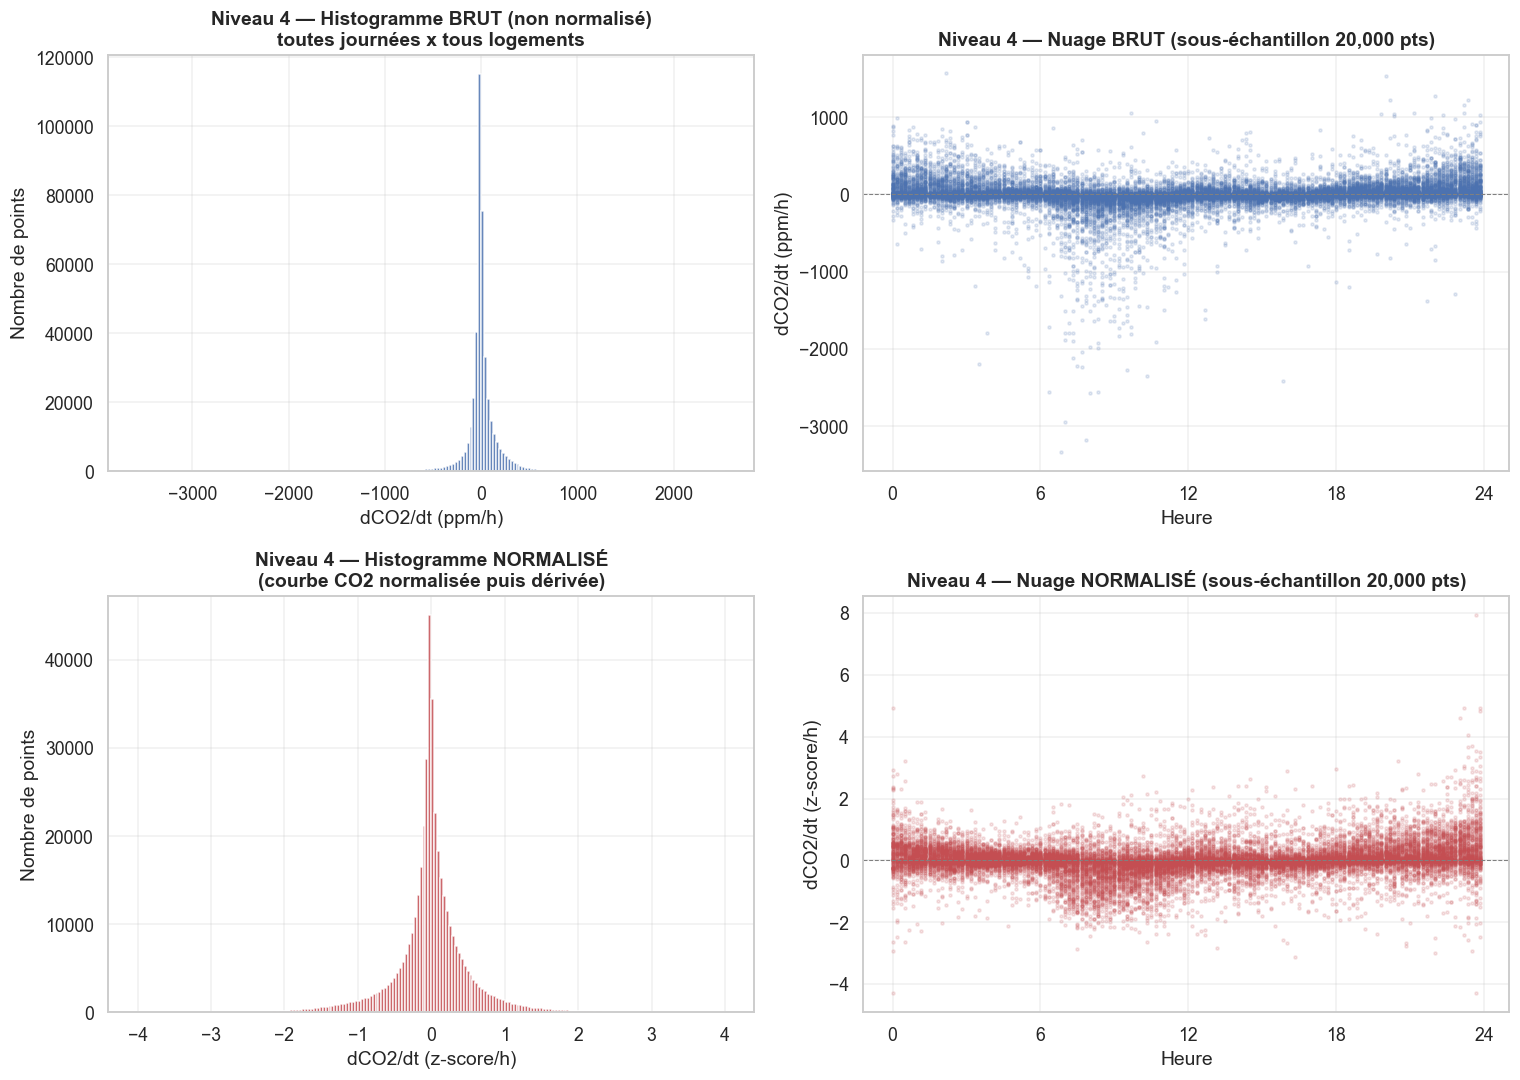

In [13]:
# Niveau 4 : toutes les journées x tous les logements
# Même normalisation que niveau 3 (courbe CO2 normalisée par logement/jour, PUIS dérivée)
vals4_raw_2d = piv_dco2.values
vals4_raw = vals4_raw_2d.ravel()

vals4_norm_2d = np.apply_along_axis(
    lambda co2_curve: savgol_filter(
        (co2_curve - co2_curve.mean()) / max(co2_curve.std(), 1e-9),
        SG_WINDOW, SG_POLY, deriv=1, delta=1 / 6),
    1, raw_co2_lvl)
vals4_norm = vals4_norm_2d.ravel()

# Sous-echantillonnage POUR LE NUAGE DE POINTS uniquement (trop de points sinon) —
# l'histogramme, lui, reste calcule sur la totalite des points
SUBSAMPLE_SCATTER = 20_000
rng_scatter = np.random.RandomState(42)
sub_idx = rng_scatter.choice(len(vals4_raw), min(SUBSAMPLE_SCATTER, len(vals4_raw)), replace=False)
hours_rep4 = np.tile(hours, vals4_raw_2d.shape[0])

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].hist(vals4_raw, bins=200, color='#4C72B0', alpha=0.85)
axes[0, 0].set_title('Niveau 4 — Histogramme BRUT (non normalisé)\ntoutes journées x tous logements',
                     fontweight='bold')
axes[0, 0].set_xlabel('dCO2/dt (ppm/h)'); axes[0, 0].set_ylabel('Nombre de points')
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].scatter(hours_rep4[sub_idx], vals4_raw[sub_idx], s=4, color='#4C72B0', alpha=0.15)
axes[0, 1].axhline(0, color='grey', lw=0.7, ls='--')
axes[0, 1].set_title(f'Niveau 4 — Nuage BRUT (sous-échantillon {SUBSAMPLE_SCATTER:,} pts)',
                     fontweight='bold')
axes[0, 1].set_xlabel('Heure'); axes[0, 1].set_ylabel('dCO2/dt (ppm/h)')
axes[0, 1].set_xticks([0, 6, 12, 18, 24])
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].hist(vals4_norm, bins=200, range=(-4, 4), color='#C44E52', alpha=0.85)
axes[1, 0].set_title('Niveau 4 — Histogramme NORMALISÉ\n(courbe CO2 normalisée puis dérivée)',
                     fontweight='bold')
axes[1, 0].set_xlabel('dCO2/dt (z-score/h)'); axes[1, 0].set_ylabel('Nombre de points')
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].scatter(hours_rep4[sub_idx], vals4_norm[sub_idx], s=4, color='#C44E52', alpha=0.15)
axes[1, 1].axhline(0, color='grey', lw=0.7, ls='--')
axes[1, 1].set_title(f'Niveau 4 — Nuage NORMALISÉ (sous-échantillon {SUBSAMPLE_SCATTER:,} pts)',
                     fontweight='bold')
axes[1, 1].set_xlabel('Heure'); axes[1, 1].set_ylabel('dCO2/dt (z-score/h)')
axes[1, 1].set_xticks([0, 6, 12, 18, 24])
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()


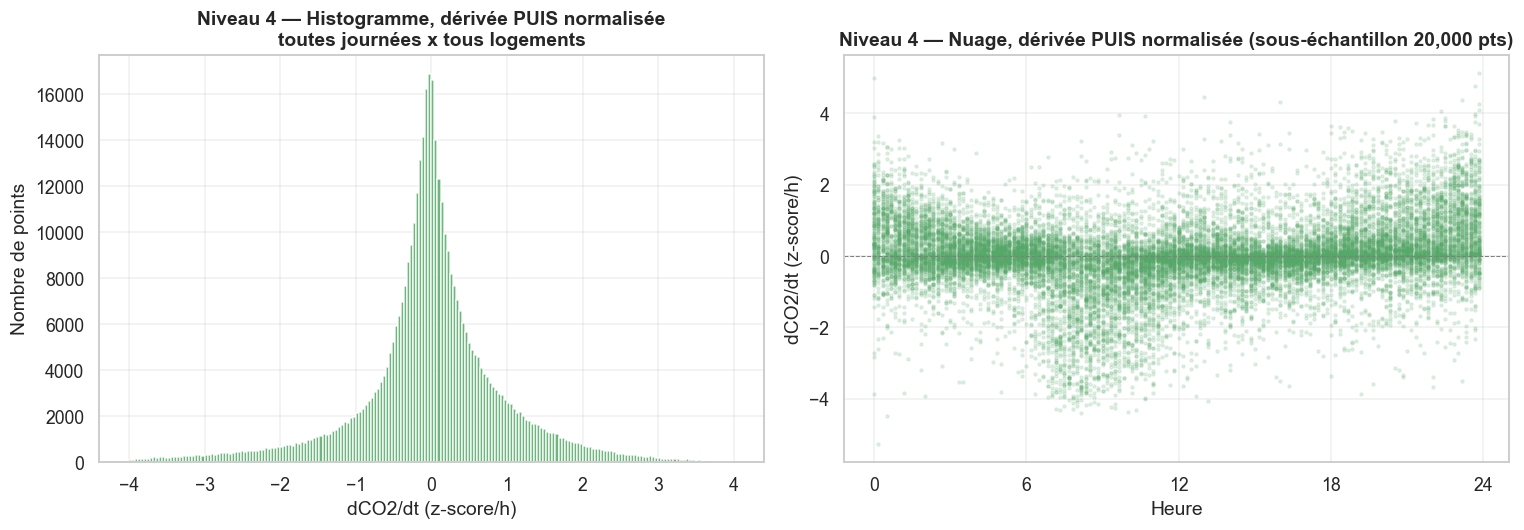

In [14]:
# Niveau 4 (variante) 
mu_d4 = vals4_raw_2d.mean(axis=1, keepdims=True)
sig_d4 = vals4_raw_2d.std(axis=1, keepdims=True)
vals4_derivnorm_2d = (vals4_raw_2d - mu_d4) / np.clip(sig_d4, 1e-9, None)
vals4_derivnorm = vals4_derivnorm_2d.ravel()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(vals4_derivnorm, bins=200, range=(-4, 4), color='#55A868', alpha=0.85)
axes[0].set_title('Niveau 4 — Histogramme, dérivée PUIS normalisée\ntoutes journées x tous logements',
                  fontweight='bold')
axes[0].set_xlabel('dCO2/dt (z-score/h)'); axes[0].set_ylabel('Nombre de points')
axes[0].grid(True, alpha=0.3)

axes[1].scatter(hours_rep4[sub_idx], vals4_derivnorm[sub_idx], s=4, color='#55A868', alpha=0.15)
axes[1].axhline(0, color='grey', lw=0.7, ls='--')
axes[1].set_title(f'Niveau 4 — Nuage, dérivée PUIS normalisée (sous-échantillon {SUBSAMPLE_SCATTER:,} pts)',
                  fontweight='bold')
axes[1].set_xlabel('Heure'); axes[1].set_ylabel('dCO2/dt (z-score/h)')
axes[1].set_xticks([0, 6, 12, 18, 24])
axes[1].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()


### DTW sur la dérivée normalisée PAR JOURNÉE



In [16]:
# Dérivée continue déjà calculée dans dtw_tensor (piv_dco2, ppm/h, non normalisée par logement)
raw_deriv_day = piv_dco2.values   # (n_jours, 144)

mu_day  = raw_deriv_day.mean(axis=1, keepdims=True)
sig_day = raw_deriv_day.std(axis=1, keepdims=True)
D_day = (raw_deriv_day - mu_day) / np.clip(sig_day, 1e-9, None)

meta_day = meta_dtw.copy()   # CODELIEU, DATE (index aligné avec piv_dco2 / dtw_tensor)
meta_day['we'] = meta_day['DATE'].dt.dayofweek >= 5

# Versions indexées (CODELIEU, DATE) — réutilisées par palier_* et multi_load
piv_day = pd.DataFrame(D_day, index=piv_dco2.index)
raw_co2_day = piv_co2_lvl.loc[piv_dco2.index].values   # CO2 brut aligné sur les mêmes lignes

print(f'D_day : {D_day.shape}  (dérivée normalisée par journée, moyenne/écart-type propres à chaque jour)')
print('Vérification — moyenne/écart-type par ligne (doivent être ~0 / ~1) :',
      D_day.mean(axis=1)[:3].round(3), D_day.std(axis=1)[:3].round(3))


D_day : (2998, 144)  (dérivée normalisée par journée, moyenne/écart-type propres à chaque jour)
Vérification — moyenne/écart-type par ligne (doivent être ~0 / ~1) : [-0. -0.  0.] [1. 1. 1.]


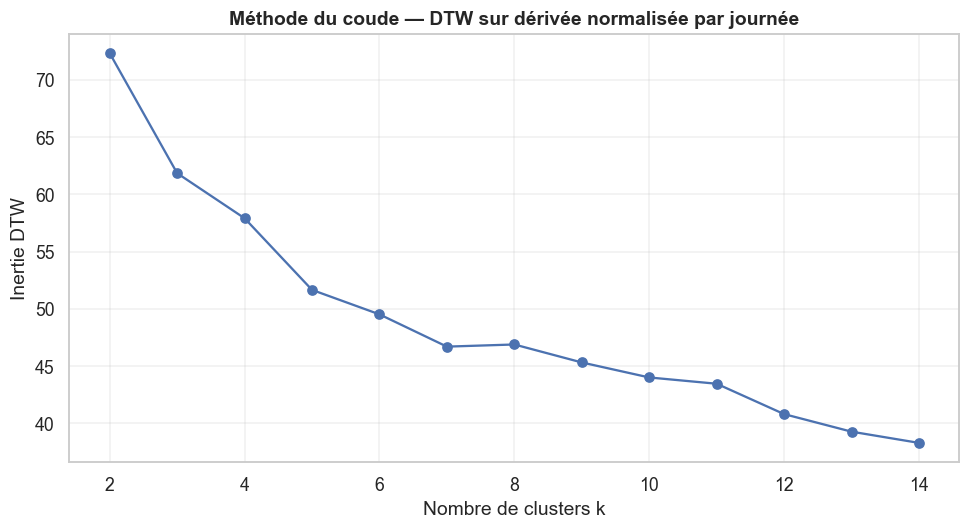

In [46]:
# Choix de K par méthode du coude (sous-échantillon — DTW coûteux)
SUBSAMPLE_DAY = 800
rng_day = np.random.RandomState(0)
sub_idx_day = rng_day.choice(len(D_day), min(SUBSAMPLE_DAY, len(D_day)), replace=False)
X_sub_day = D_day[sub_idx_day][:, :, None]

ks_day = range(2, 15)
inerties_day = []
for k in ks_day:
    km = TimeSeriesKMeans(n_clusters=k, metric='dtw',
                          metric_params={'global_constraint': 'sakoe_chiba', 'sakoe_chiba_radius': 6},
                          random_state=42, n_jobs=-1)
    km.fit(X_sub_day)
    inerties_day.append(km.inertia_)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(list(ks_day), inerties_day, marker='o')
ax.set_xlabel('Nombre de clusters k'); ax.set_ylabel('Inertie DTW')
ax.set_title('Méthode du coude — DTW sur dérivée normalisée par journée', fontweight='bold')
ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


In [80]:
K_DAY = 5

X_day = D_day[:, :, None]   # (n_samples, 144, 1)

model_day = TimeSeriesKMeans(
    n_clusters=K_DAY, metric='dtw',
    metric_params={'global_constraint': 'sakoe_chiba', 'sakoe_chiba_radius': 6},
    random_state=42, n_jobs=-1, verbose=1,
)
labels_day = model_day.fit_predict(X_day)
meta_day['cluster_day'] = labels_day

print(f'K_DAY={K_DAY}')
print('Taille des clusters (DTW normalisé par journée) :')
print(pd.Series(labels_day).value_counts().sort_index().to_string())


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 176 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 426 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 776 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 1226 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 1776 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 2426 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 2998 out of 2998 | elapsed:    0.1s finished
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 176 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 426 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 776 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 1226 tasks      | elapsed:    0.0s
[Parallel(n_job

80.680 --> 

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 176 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 426 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 776 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 1226 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 1776 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 2426 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 3176 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-1)]: Done 4026 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-1)]: Done 4976 tasks      | elapsed:    0.3s
[Parallel(n_jobs=-1)]: Done 6026 tasks      | elapsed:    0.4s
[Parallel(n_jobs=-1)]: Done 7176 tasks      | elapsed:    0.5s
[Parallel(n_jobs=-1)]: Done 8426 tasks      | elapsed:    0.5s
[Parallel(n_jobs=-1)]: Done 9776 tasks      | elapsed:    0.6s
[Parallel(n_jobs=-1)]: Done 11226 tasks 

57.539 --> 

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 176 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 426 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 776 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 1226 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 1776 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 2426 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 3176 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 4026 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-1)]: Done 4976 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-1)]: Done 6026 tasks      | elapsed:    0.3s
[Parallel(n_jobs=-1)]: Done 7176 tasks      | elapsed:    0.4s
[Parallel(n_jobs=-1)]: Done 8426 tasks      | elapsed:    0.5s
[Parallel(n_jobs=-1)]: Done 9776 tasks      | elapsed:    0.5s
[Parallel(n_jobs=-1)]: Done 11226 tasks 

...

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 176 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 426 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 776 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 1226 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 1776 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-1)]: Done 2426 tasks      | elapsed:    0.3s
[Parallel(n_jobs=-1)]: Done 3176 tasks      | elapsed:    0.3s
[Parallel(n_jobs=-1)]: Done 4026 tasks      | elapsed:    0.4s
[Parallel(n_jobs=-1)]: Done 4976 tasks      | elapsed:    0.5s
[Parallel(n_jobs=-1)]: Done 6026 tasks      | elapsed:    0.6s
[Parallel(n_jobs=-1)]: Done 7176 tasks      | elapsed:    0.8s
[Parallel(n_jobs=-1)]: Done 8426 tasks      | elapsed:    1.0s
[Parallel(n_jobs=-1)]: Done 9776 tasks      | elapsed:    1.2s
[Parallel(n_jobs=-1)]: Done 11226 tasks 

57.677 --> 


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 176 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 426 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 776 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 1226 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 1776 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 2426 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 3176 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-1)]: Done 4026 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-1)]: Done 4976 tasks      | elapsed:    0.3s
[Parallel(n_jobs=-1)]: Done 6026 tasks      | elapsed:    0.4s
[Parallel(n_jobs=-1)]: Done 7176 tasks      | elapsed:    0.4s
[Parallel(n_jobs=-1)]: Done 8426 tasks      | elapsed:    0.5s
[Parallel(n_jobs=-1)]: Done 9776 tasks      | elapsed:    0.6s
[Parallel(n_jobs=-1)]: Done 11226 tasks 

K_DAY=5
Taille des clusters (DTW normalisé par journée) :
0    357
1    681
2    629
3    874
4    457


[Parallel(n_jobs=-1)]: Done 14426 tasks      | elapsed:    0.9s
[Parallel(n_jobs=-1)]: Done 14990 out of 14990 | elapsed:    1.0s finished


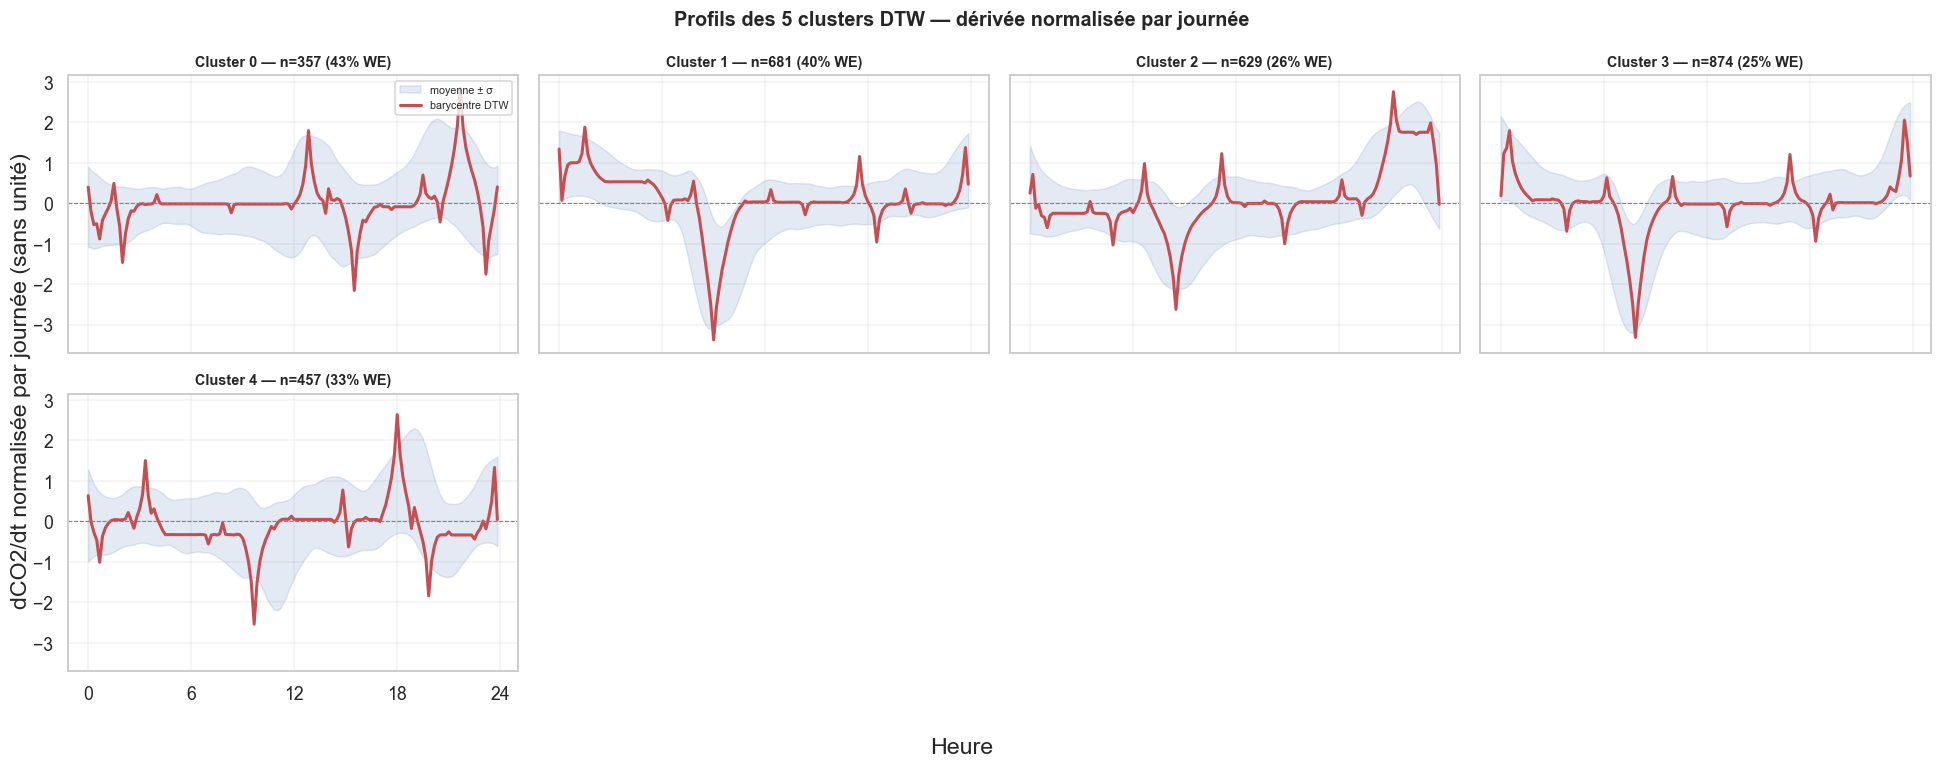

In [81]:
hours = np.arange(144) / 6
n_cols = min(K_DAY, 4)
n_rows = int(np.ceil(K_DAY / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.5 * n_cols, 3.5 * n_rows),
                         sharex=True, sharey=True)
axes = np.atleast_1d(axes).ravel()

for c in range(K_DAY):
    ax = axes[c]
    sel = labels_day == c
    n = sel.sum()
    pct_we = meta_day.loc[sel, 'we'].mean() * 100

    bary = model_day.cluster_centers_[c].ravel()
    m, s = D_day[sel].mean(axis=0), D_day[sel].std(axis=0)

    ax.fill_between(hours, m - s, m + s, alpha=0.15, color='#4C72B0',
                    label='moyenne ± σ')
    ax.plot(hours, bary, lw=2, color='#C44E52', label='barycentre DTW')
    ax.axhline(0, color='grey', lw=0.7, ls='--')
    ax.set_title(f'Cluster {c} — n={n:,} ({pct_we:.0f}% WE)', fontsize=9.5, fontweight='bold')
    ax.set_xticks([0, 6, 12, 18, 24])
    ax.grid(True, alpha=0.25)
    if c == 0:
        ax.legend(fontsize=7, loc='upper right')

for ax in axes[K_DAY:]:
    ax.axis('off')

fig.supxlabel('Heure'); fig.supylabel('dCO2/dt normalisée par journée (sans unité)')
plt.suptitle(f'Profils des {K_DAY} clusters DTW — dérivée normalisée par journée',
            fontweight='bold', fontsize=13)
plt.tight_layout(); plt.show()


Journées affichées (2 par cluster DTW normalisé par journée) :
CODELIEU       DATE  cluster_day
 08-M007 2004-12-19            0
 02-M070 2004-04-03            0
 12-M004 2003-11-16            1
 05-M019 2004-06-29            1
 10-M036 2005-10-17            2
 05-M051 2004-04-27            2
 11-M089 2005-07-15            3
 05-M026 2004-03-23            3
 08-M022 2004-11-25            4
 02-M038 2005-03-15            4


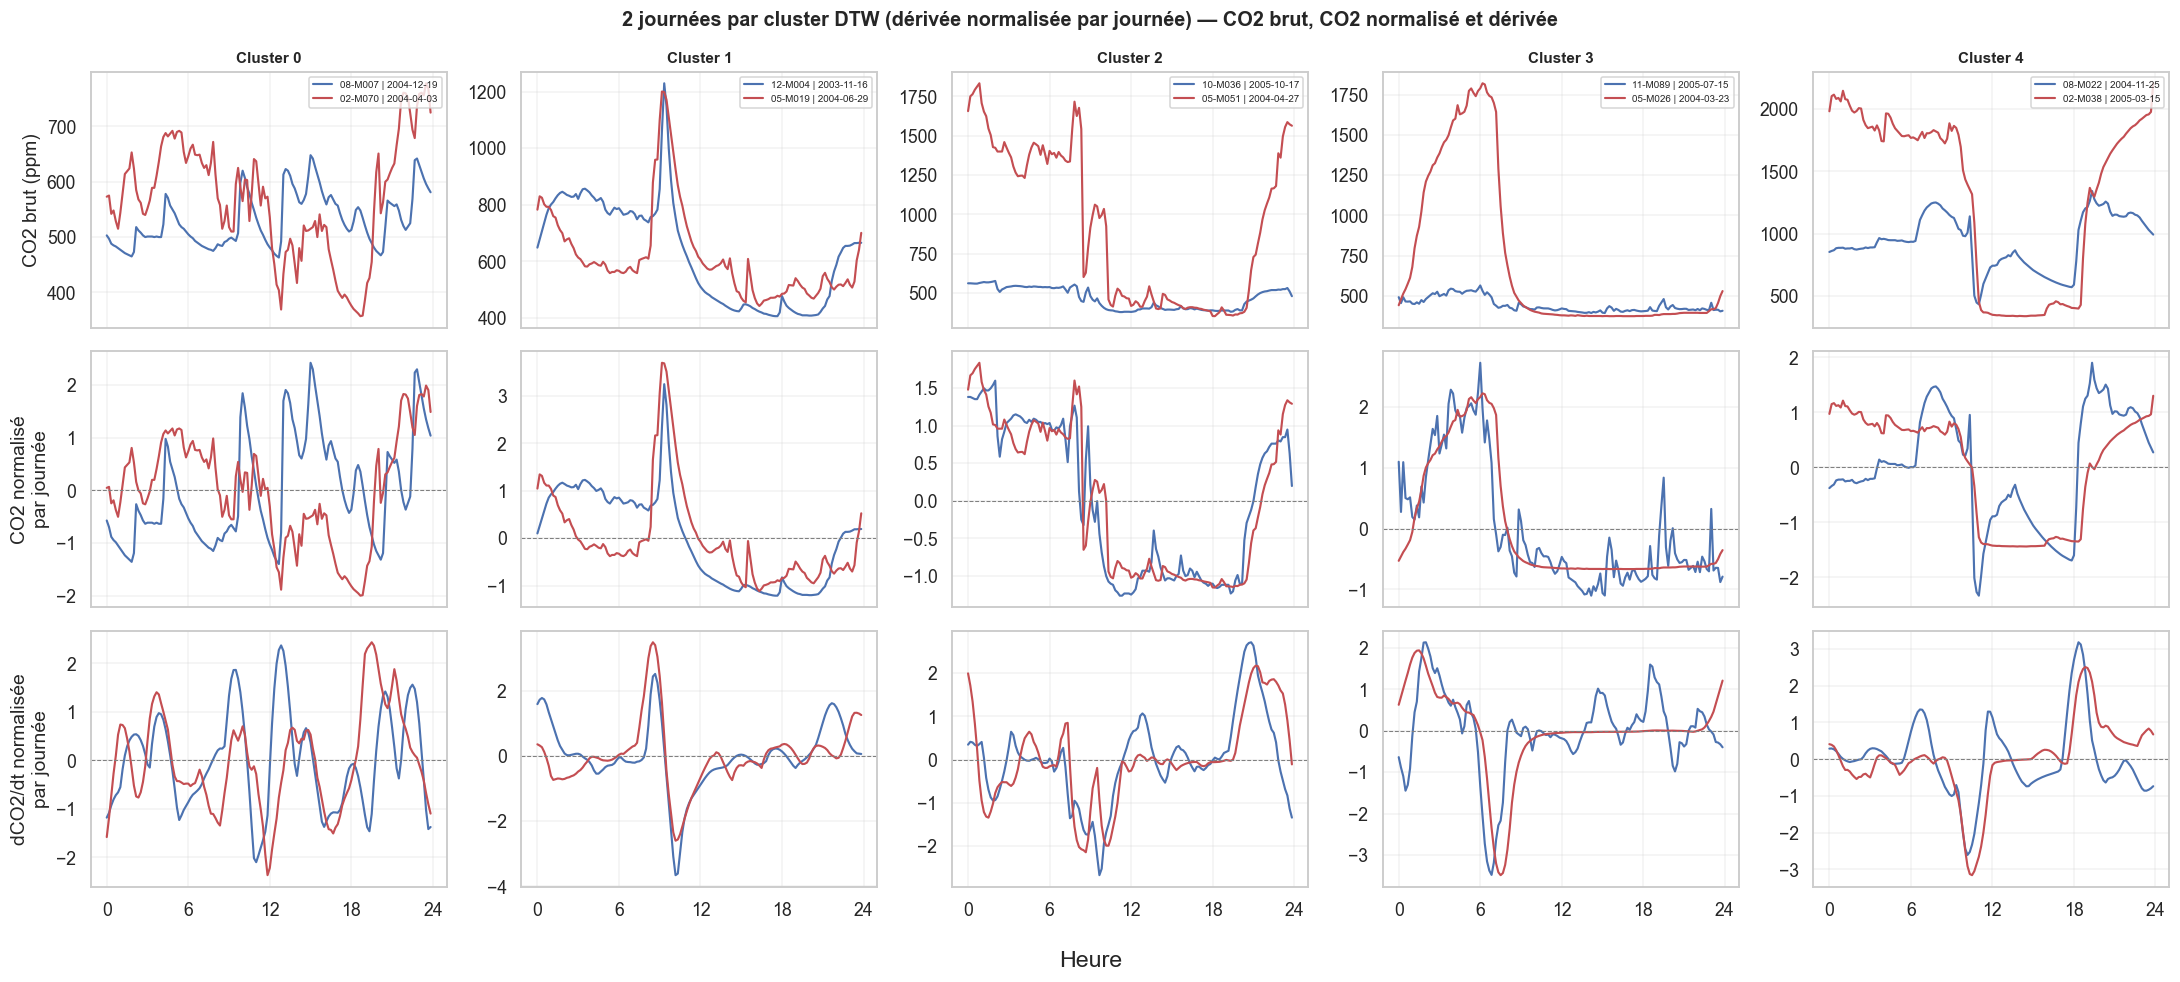

In [86]:
# 2 journées par cluster (DTW dérivée normalisée par journée)
# — CO2 brut + CO2 normalisé par journée + dérivée normalisée
EX_DAY = pd.concat([d.sample(min(2, len(d)), random_state=42)
                   for _, d in meta_day.groupby('cluster_day')])
print('Journées affichées (2 par cluster DTW normalisé par journée) :')
print(EX_DAY[['CODELIEU', 'DATE', 'cluster_day']].to_string(index=False))

# CO2 normalisé PAR JOURNEE (meme principe que D_day, applique au niveau plutot qu'a la derivee)
mu_co2_day  = raw_co2_day.mean(axis=1, keepdims=True)
sig_co2_day = raw_co2_day.std(axis=1, keepdims=True)
co2_day_norm = (raw_co2_day - mu_co2_day) / np.clip(sig_co2_day, 1e-9, None)

fig, axes = plt.subplots(3, K_DAY, figsize=(4 * K_DAY, 9), sharex=True)
colors_ex = ['#4C72B0', '#C44E52']

for c in range(K_DAY):
    sub = EX_DAY[EX_DAY['cluster_day'] == c]

    # Ligne 1 : CO2 brut (ppm)
    ax = axes[0, c]
    for (idx, row), color in zip(sub.iterrows(), colors_ex):
        ax.plot(hours, raw_co2_day[idx], lw=1.4, color=color,
                label=f"{row['CODELIEU']} | {row['DATE'].date()}")
    ax.set_title(f'Cluster {c}', fontsize=10, fontweight='bold')
    ax.set_xticks([0, 6, 12, 18, 24])
    ax.grid(True, alpha=0.25)
    ax.legend(fontsize=6.5, loc='upper right')
    if c == 0:
        ax.set_ylabel('CO2 brut (ppm)')

    # Ligne 2 : CO2 normalisé par journée (z-score)
    ax = axes[1, c]
    for (idx, row), color in zip(sub.iterrows(), colors_ex):
        ax.plot(hours, co2_day_norm[idx], lw=1.4, color=color)
    ax.axhline(0, color='grey', lw=0.7, ls='--')
    ax.set_xticks([0, 6, 12, 18, 24])
    ax.grid(True, alpha=0.25)
    if c == 0:
        ax.set_ylabel('CO2 normalisé\npar journée')

    # Ligne 3 : dérivée normalisée par journée
    ax = axes[2, c]
    for (idx, row), color in zip(sub.iterrows(), colors_ex):
        ax.plot(hours, D_day[idx], lw=1.4, color=color)
    ax.axhline(0, color='grey', lw=0.7, ls='--')
    ax.set_xticks([0, 6, 12, 18, 24])
    ax.grid(True, alpha=0.25)
    if c == 0:
        ax.set_ylabel('dCO2/dt normalisée\npar journée')

fig.supxlabel('Heure')
plt.suptitle('2 journées par cluster DTW (dérivée normalisée par journée) — CO2 brut, CO2 normalisé et dérivée',
            fontweight='bold', fontsize=13)
plt.tight_layout(); plt.show()


In [82]:
# ── Validation du clustering DTW (normalisé par journée) par le type d'aération ──
val_day = meta_day.copy()
val_day['aeration'] = val_day['CODELIEU'].map(ventilation)

# % de journées de chaque type d'aération, par cluster
ct_day = (pd.crosstab(val_day['cluster_day'], val_day['aeration'],
                      normalize='index').mul(100).round(1))
display(
    ct_day.style
    .background_gradient(cmap='YlOrRd', axis=None)
    .format('{:.1f}%')
    .set_caption("Type d'aération par cluster DTW (dérivée normalisée par journée)")
)

# Répartition en nombre de LOGEMENTS (pas de journées) par aération dominante
# -> évite qu'un logement à beaucoup de journées pèse plusieurs fois
log_aer = val_day.groupby('CODELIEU')['aeration'].first()
log_dom = val_day.groupby('CODELIEU')['cluster_day'].agg(lambda x: x.value_counts().idxmax())
ct_log = (pd.crosstab(log_dom, log_aer, normalize='index').mul(100).round(1))
display(
    ct_log.style
    .background_gradient(cmap='YlOrRd', axis=None)
    .format('{:.1f}%')
    .set_caption("Type d'aération par cluster DOMINANT (1 ligne = 1 logement)")
)


aeration,Aucune,Extracteurs,Naturelle,VMC
cluster_day,,,,
0,23.2%,8.7%,37.5%,30.5%
1,20.3%,7.3%,34.1%,38.3%
2,18.8%,10.8%,33.2%,37.2%
3,18.8%,11.3%,28.0%,41.9%
4,24.5%,8.5%,31.5%,35.4%


aeration,Aucune,Extracteurs,Naturelle,VMC
cluster_day,,,,
0,18.9%,9.4%,45.3%,26.4%
1,19.0%,8.6%,32.8%,39.7%
2,18.5%,8.4%,37.8%,35.3%
3,18.6%,10.9%,25.0%,45.5%
4,31.9%,8.7%,31.9%,27.5%


## DTW sur la dérivée continue — version NON normalisée

DTW appliqué directement à la dérivée continue brute (`piv_dco2`, ppm/h),
sans aucune normalisation (ni par logement, ni par journée) — pour
comparaison directe avec `daynorm_fit` (normalisé par journée).


In [ ]:
# Choix de K par méthode du coude (sous-échantillon — DTW coûteux)
SUBSAMPLE_NONORM = 800
rng_nonorm = np.random.RandomState(0)
sub_idx_nonorm = rng_nonorm.choice(len(piv_dco2), min(SUBSAMPLE_NONORM, len(piv_dco2)), replace=False)
X_sub_nonorm = piv_dco2.values[sub_idx_nonorm][:, :, None]

ks_nonorm = range(2, 15)
inerties_nonorm = []
for k in ks_nonorm:
    km = TimeSeriesKMeans(n_clusters=k, metric='dtw',
                          metric_params={'global_constraint': 'sakoe_chiba', 'sakoe_chiba_radius': 6},
                          random_state=42, n_jobs=-1)
    km.fit(X_sub_nonorm)
    inerties_nonorm.append(km.inertia_)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(list(ks_nonorm), inerties_nonorm, marker='o')
ax.set_xlabel('Nombre de clusters k'); ax.set_ylabel('Inertie DTW')
ax.set_title('Méthode du coude — DTW sur dérivée continue NON normalisée', fontweight='bold')
ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


In [88]:
K_NONORM = 6

X_nonorm = piv_dco2.values[:, :, None]   # (n_samples, 144, 1), AUCUNE normalisation

model_nonorm = TimeSeriesKMeans(
    n_clusters=K_NONORM, metric='dtw',
    metric_params={'global_constraint': 'sakoe_chiba', 'sakoe_chiba_radius': 6},
    random_state=42, n_jobs=-1, verbose=1,
)
labels_nonorm = model_nonorm.fit_predict(X_nonorm)
meta_nonorm = meta_dtw.copy()
meta_nonorm['cluster_nonorm'] = labels_nonorm

print(f'K_NONORM={K_NONORM}')
print('Taille des clusters (DTW dérivée continue, non normalisée) :')
print(pd.Series(labels_nonorm).value_counts().sort_index().to_string())


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 176 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 426 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 776 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 1226 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 1776 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 2426 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 2998 out of 2998 | elapsed:    0.1s finished
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 176 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 426 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 776 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 1226 tasks      | elapsed:    0.0s
[Parallel(n_job

2564810.806 --> 

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 176 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 426 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 776 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 1226 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 1776 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 2426 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 3176 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-1)]: Done 4026 tasks      | elapsed:    0.3s
[Parallel(n_jobs=-1)]: Done 4976 tasks      | elapsed:    0.3s
[Parallel(n_jobs=-1)]: Done 6026 tasks      | elapsed:    0.4s
[Parallel(n_jobs=-1)]: Done 7176 tasks      | elapsed:    0.5s
[Parallel(n_jobs=-1)]: Done 8426 tasks      | elapsed:    0.6s
[Parallel(n_jobs=-1)]: Done 9776 tasks      | elapsed:    0.7s
[Parallel(n_jobs=-1)]: Done 11226 tasks 

2299801.374 --> 

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 176 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 426 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 776 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 1226 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 1776 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 2426 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 3176 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-1)]: Done 4026 tasks      | elapsed:    0.3s
[Parallel(n_jobs=-1)]: Done 4976 tasks      | elapsed:    0.3s
[Parallel(n_jobs=-1)]: Done 6026 tasks      | elapsed:    0.4s
[Parallel(n_jobs=-1)]: Done 7176 tasks      | elapsed:    0.5s
[Parallel(n_jobs=-1)]: Done 8426 tasks      | elapsed:    0.6s
[Parallel(n_jobs=-1)]: Done 9776 tasks      | elapsed:    0.7s
[Parallel(n_jobs=-1)]: Done 11226 tasks 

...

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 176 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 426 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 776 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 1226 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 1776 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 2426 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 3176 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 4026 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-1)]: Done 4976 tasks      | elapsed:    0.3s
[Parallel(n_jobs=-1)]: Done 6026 tasks      | elapsed:    0.4s
[Parallel(n_jobs=-1)]: Done 7176 tasks      | elapsed:    0.4s
[Parallel(n_jobs=-1)]: Done 8426 tasks      | elapsed:    0.5s
[Parallel(n_jobs=-1)]: Done 9776 tasks      | elapsed:    0.7s
[Parallel(n_jobs=-1)]: Done 11226 tasks 

2276263.400 --> 


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 176 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 426 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 776 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 1226 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 1776 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 2426 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-1)]: Done 3176 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-1)]: Done 4026 tasks      | elapsed:    0.3s
[Parallel(n_jobs=-1)]: Done 4976 tasks      | elapsed:    0.4s
[Parallel(n_jobs=-1)]: Done 6026 tasks      | elapsed:    0.4s
[Parallel(n_jobs=-1)]: Done 7176 tasks      | elapsed:    0.5s
[Parallel(n_jobs=-1)]: Done 8426 tasks      | elapsed:    0.6s
[Parallel(n_jobs=-1)]: Done 9776 tasks      | elapsed:    0.7s
[Parallel(n_jobs=-1)]: Done 11226 tasks 

K_NONORM=6
Taille des clusters (DTW dérivée continue, non normalisée) :
0    1374
1      89
2      53
3     123
4    1096
5     263


[Parallel(n_jobs=-1)]: Done 16176 tasks      | elapsed:    1.2s
[Parallel(n_jobs=-1)]: Done 17988 out of 17988 | elapsed:    1.3s finished


Journées affichées (2 par cluster DTW non normalisé) :
CODELIEU       DATE  cluster_nonorm
 05-M015 2004-08-25               0
 06-M026 2004-03-12               0
 07-M013 2005-11-20               1
 07-M039 2005-10-07               1
 05-M009 2004-06-25               2
 11-M091 2004-04-24               2
 02-M047 2004-04-08               3
 03-M056 2004-05-04               3
 02-M005 2004-01-14               4
 06-M003 2004-05-03               4
 05-M026 2004-03-23               5
 05-M028 2004-04-16               5


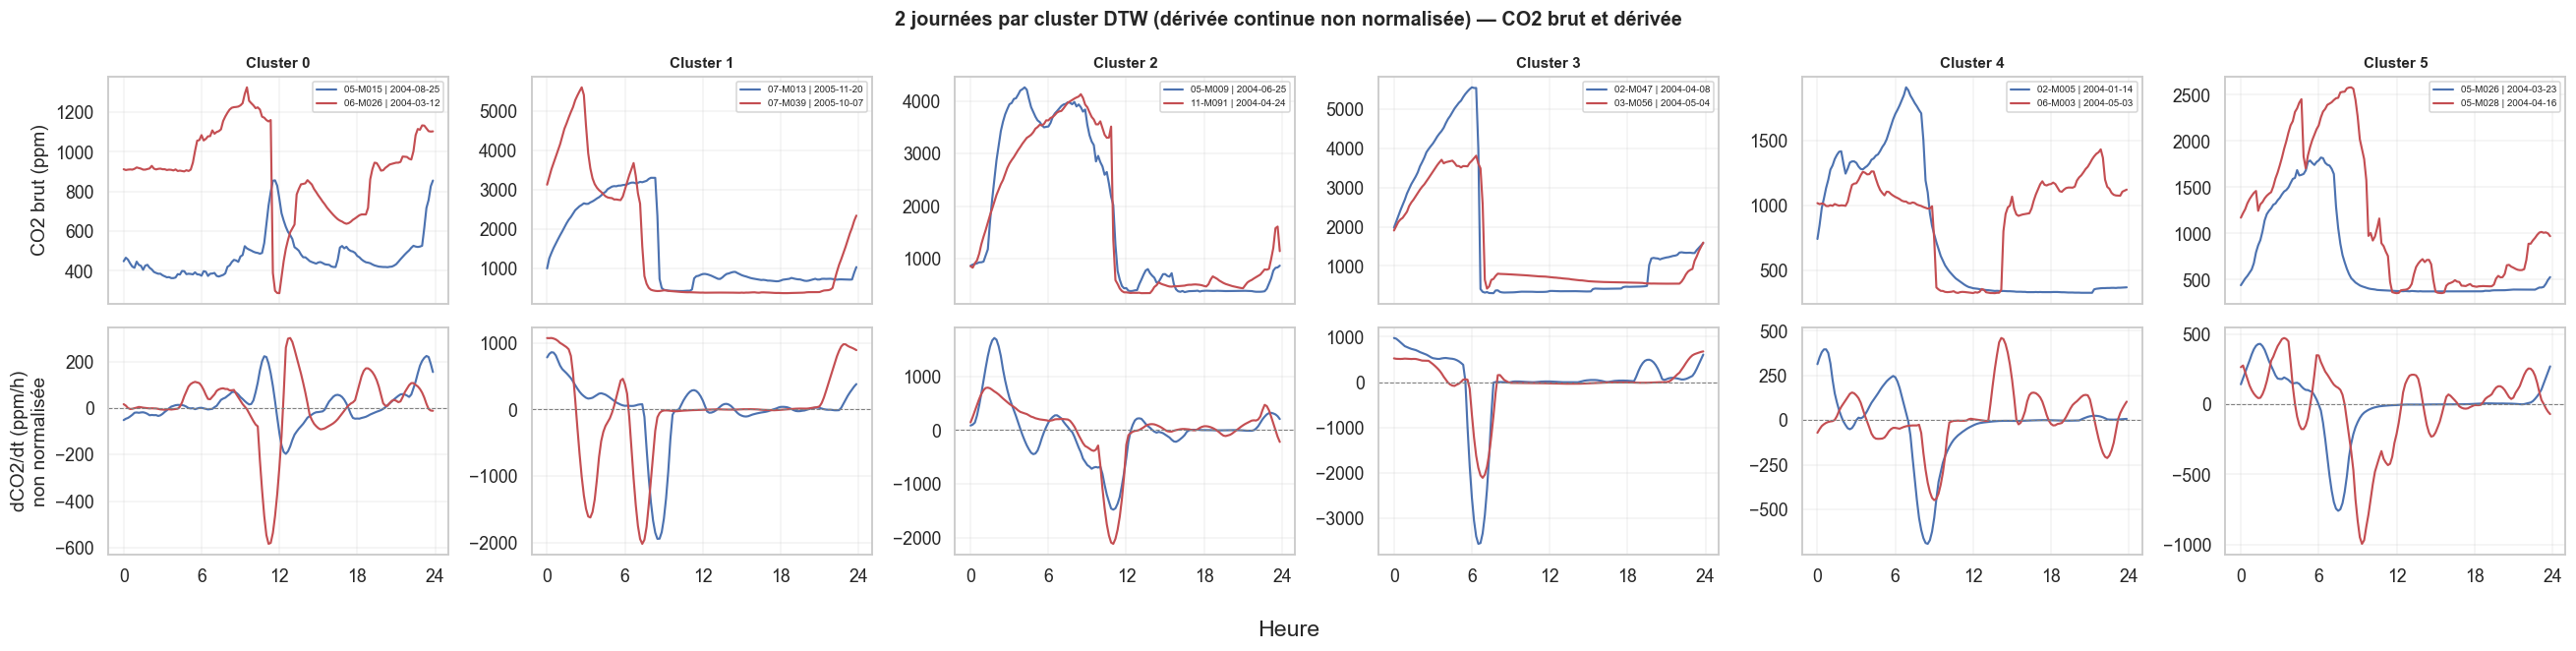

In [89]:
# 2 journées par cluster (DTW dérivée continue, non normalisée) — CO2 brut + dérivée brute
EX_NONORM = pd.concat([d.sample(min(2, len(d)), random_state=42)
                      for _, d in meta_nonorm.groupby('cluster_nonorm')])
print('Journées affichées (2 par cluster DTW non normalisé) :')
print(EX_NONORM[['CODELIEU', 'DATE', 'cluster_nonorm']].to_string(index=False))

raw_co2_nonorm = piv_co2_lvl.loc[piv_dco2.index].values   # CO2 brut aligné sur piv_dco2

fig, axes = plt.subplots(2, K_NONORM, figsize=(4 * K_NONORM, 6), sharex=True)
colors_ex = ['#4C72B0', '#C44E52']

for c in range(K_NONORM):
    sub = EX_NONORM[EX_NONORM['cluster_nonorm'] == c]

    # Ligne 1 : CO2 brut (ppm)
    ax = axes[0, c]
    for (idx, row), color in zip(sub.iterrows(), colors_ex):
        ax.plot(hours, raw_co2_nonorm[idx], lw=1.4, color=color,
                label=f"{row['CODELIEU']} | {row['DATE'].date()}")
    ax.set_title(f'Cluster {c}', fontsize=10, fontweight='bold')
    ax.set_xticks([0, 6, 12, 18, 24])
    ax.grid(True, alpha=0.25)
    ax.legend(fontsize=6.5, loc='upper right')
    if c == 0:
        ax.set_ylabel('CO2 brut (ppm)')

    # Ligne 2 : dérivée brute (ppm/h, non normalisée)
    ax = axes[1, c]
    for (idx, row), color in zip(sub.iterrows(), colors_ex):
        ax.plot(hours, piv_dco2.values[idx], lw=1.4, color=color)
    ax.axhline(0, color='grey', lw=0.7, ls='--')
    ax.set_xticks([0, 6, 12, 18, 24])
    ax.grid(True, alpha=0.25)
    if c == 0:
        ax.set_ylabel('dCO2/dt (ppm/h)\nnon normalisée')

fig.supxlabel('Heure')
plt.suptitle('2 journées par cluster DTW (dérivée continue non normalisée) — CO2 brut et dérivée',
            fontweight='bold', fontsize=13)
plt.tight_layout(); plt.show()


## Clustering sur la distribution des valeurs (par journée)

Différent du DTW : on ne compare pas la forme dans le temps, mais la
**distribution des 144 valeurs de dérivée** de chaque journée (normalisée
par journée, `D_day`) — peu importe à quelle heure elles surviennent. Deux
journées avec le même "profil de répartition" (ex. beaucoup de valeurs
extrêmes vs très concentrées près de 0) se retrouveront dans le même
cluster, même si leurs pics ne sont pas au même moment de la journée.

Méthode : histogramme normalisé (proportions) de chaque journée → K-means
euclidien classique sur ces histogrammes.


In [17]:
# Histogramme normalisé (proportions) des 144 valeurs de D_day, pour chaque journée
N_BINS_DIST = 20
BIN_RANGE = (-4, 4)
bin_edges = np.linspace(*BIN_RANGE, N_BINS_DIST + 1)

hist_matrix = np.apply_along_axis(
    lambda row: np.histogram(row, bins=bin_edges)[0], 1, D_day)
hist_matrix = hist_matrix / hist_matrix.sum(axis=1, keepdims=True)   # proportions (somme=1)

bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
print(f'hist_matrix : {hist_matrix.shape}  ({N_BINS_DIST} bins, plage {BIN_RANGE})')


hist_matrix : (2998, 20)  (20 bins, plage (-4, 4))


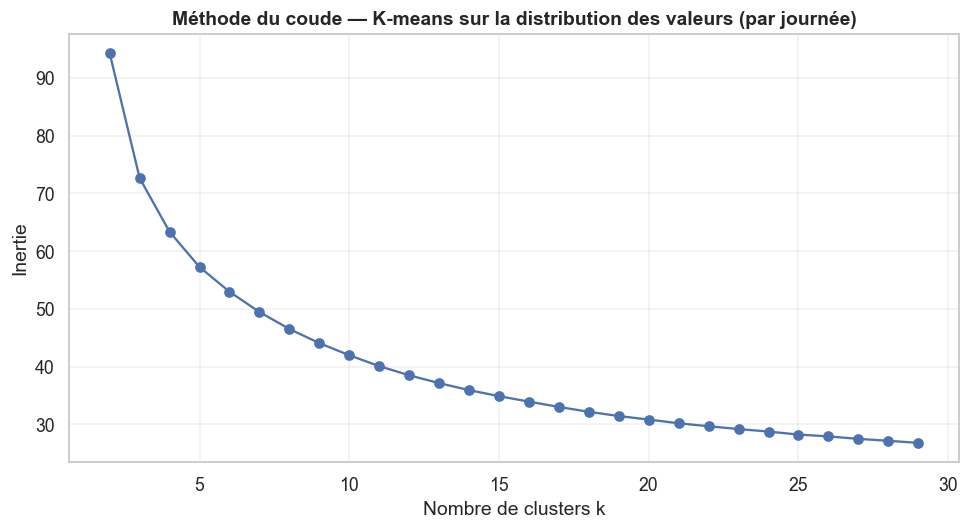

In [20]:
# Choix de K par méthode du coude — K-means euclidien, rapide
ks_dist = range(2, 30)
inerties_dist = []
for k in ks_dist:
    km = KMeans(n_clusters=k, random_state=42, n_init=60)
    km.fit(hist_matrix)
    inerties_dist.append(km.inertia_)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(list(ks_dist), inerties_dist, marker='o')
ax.set_xlabel('Nombre de clusters k'); ax.set_ylabel('Inertie')
ax.set_title('Méthode du coude — K-means sur la distribution des valeurs (par journée)',
             fontweight='bold')
ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


In [21]:
K_DIST = 6

km_dist = KMeans(n_clusters=K_DIST, random_state=42, n_init=20)
labels_dist = km_dist.fit_predict(hist_matrix)
meta_dist = meta_day.copy()
meta_dist['cluster_dist'] = labels_dist

print(f'K_DIST={K_DIST}')
print('Taille des clusters (distribution des valeurs, par journée) :')
print(pd.Series(labels_dist).value_counts().sort_index().to_string())


K_DIST=6
Taille des clusters (distribution des valeurs, par journée) :
0    589
1    669
2    354
3    399
4    659
5    328


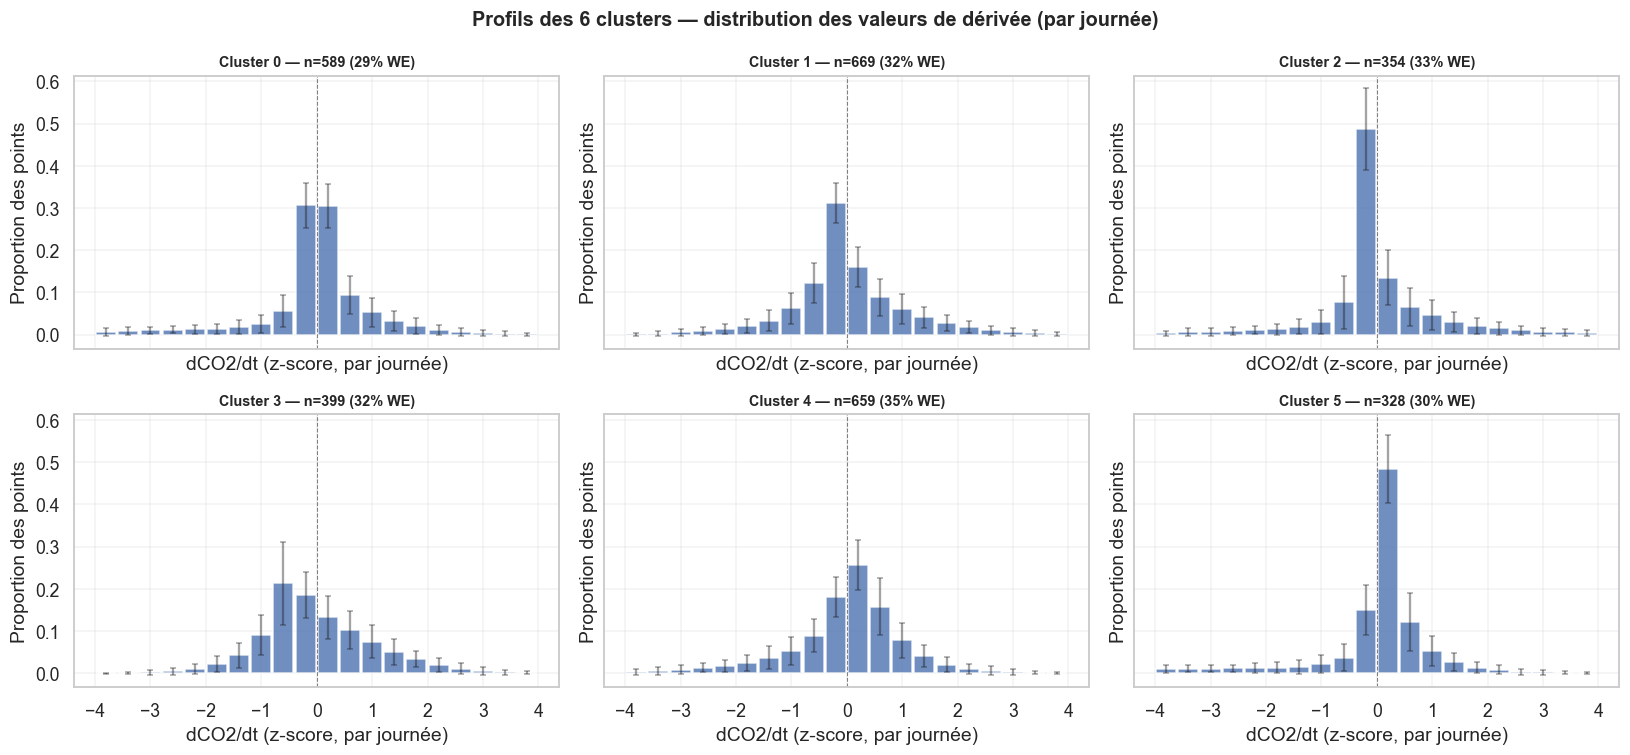

In [ ]:
# Profil de chaque cluster : histogramme moyen
n_cols = min(K_DIST, 3)
n_rows = int(np.ceil(K_DIST / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 3.5 * n_rows), sharex=True, sharey=True)
axes = np.atleast_1d(axes).ravel()

for c in range(K_DIST):
    ax = axes[c]
    sel = labels_dist == c
    n = sel.sum()
    pct_we = meta_dist.loc[sel, 'we'].mean() * 100

    m = hist_matrix[sel].mean(axis=0)
    s = hist_matrix[sel].std(axis=0)
    ax.bar(bin_centers, m, width=(bin_edges[1] - bin_edges[0]) * 0.9,
          color='#4C72B0', alpha=0.8, yerr=s, capsize=2, error_kw={'alpha': 0.4})
    ax.axvline(0, color='grey', lw=0.7, ls='--')
    ax.set_title(f'Cluster {c} — n={n:,} ({pct_we:.0f}% WE)', fontsize=9.5, fontweight='bold')
    ax.set_xlabel('dCO2/dt (z-score, par journée)'); ax.set_ylabel('Proportion des points')
    ax.grid(True, alpha=0.25)

for ax in axes[K_DIST:]:
    ax.axis('off')

plt.suptitle(f'Profils des {K_DIST} clusters — distribution des valeurs de dérivée (par journée)',
            fontweight='bold', fontsize=13)
plt.tight_layout(); plt.show()


### DTW sur la dérivée encodée par paliers



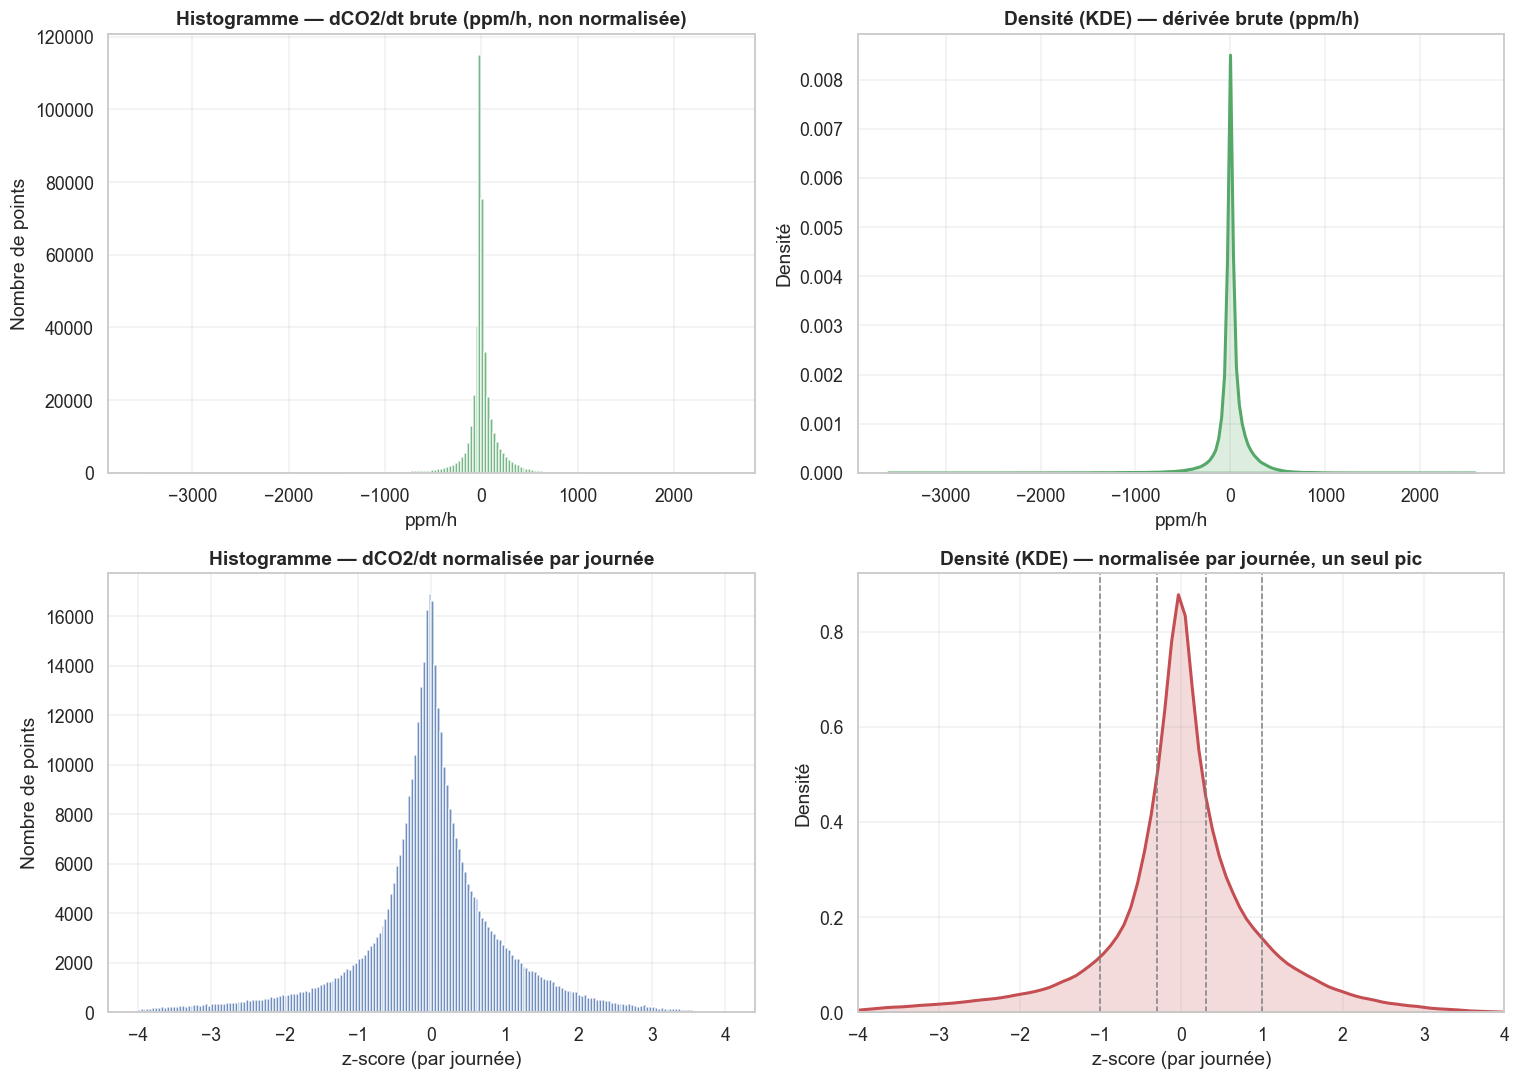

% des points (normalisés) dans [-0.2, 0.2) : 31.6%
Dérivée brute : min=-3568.0, max=2534.0, std=202.5 ppm/h


In [ ]:

vals_raw  = raw_deriv_day.ravel()
vals_norm = D_day.ravel()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Ligne 1 : dérivée brute (non normalisée, ppm/h)
ax = axes[0, 0]
ax.hist(vals_raw, bins=200, color='#55A868', alpha=0.8)
ax.set_title('Histogramme — dCO2/dt brute (ppm/h, non normalisée)', fontweight='bold')
ax.set_xlabel('ppm/h'); ax.set_ylabel('Nombre de points')
ax.grid(True, alpha=0.3)

ax = axes[0, 1]
sns.kdeplot(vals_raw, ax=ax, color='#55A868', lw=2, fill=True, alpha=0.2)
ax.set_title('Densité (KDE) — dérivée brute (ppm/h)', fontweight='bold')
ax.set_xlabel('ppm/h'); ax.set_ylabel('Densité')
ax.grid(True, alpha=0.3)

# Ligne 2 : dérivée normalisée par journée (D_day)
ax = axes[1, 0]
ax.hist(vals_norm, bins=200, range=(-4, 4), color='#4C72B0', alpha=0.8)
ax.set_title('Histogramme — dCO2/dt normalisée par journée', fontweight='bold')
ax.set_xlabel('z-score (par journée)'); ax.set_ylabel('Nombre de points')
ax.grid(True, alpha=0.3)

ax = axes[1, 1]
sns.kdeplot(vals_norm, ax=ax, color='#C44E52', lw=2, fill=True, alpha=0.2)
for seuil in [-1.0, -0.3, 0.3, 1.0]:
    ax.axvline(seuil, color='grey', lw=1, ls='--')
ax.set_title('Densité (KDE) — normalisée par journée, un seul pic', fontweight='bold')
ax.set_xlabel('z-score (par journée)'); ax.set_ylabel('Densité')
ax.set_xlim(-4, 4)
ax.grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

pct_center = 100 * ((vals_norm >= -0.2) & (vals_norm < 0.2)).mean()
print(f'% des points (normalisés) dans [-0.2, 0.2) : {pct_center:.1f}%')
print(f'Dérivée brute : min={vals_raw.min():.1f}, max={vals_raw.max():.1f}, '
      f'std={vals_raw.std():.1f} ppm/h')


In [ ]:
#  reutilise le MEME filtre Savitzky-Golay
D_day_smooth = np.apply_along_axis(lambda x: savgol_filter(x, SG_WINDOW, SG_POLY), 1, D_day)

N_PALIERS = 5
PALIER_NOMS = ['forte baisse', 'baisse', 'stable', 'hausse', 'forte hausse']
QUANTILES = [0.10, 0.30, 0.70, 0.90]   # forte=10% de chaque cote, stable=40%, baisse/hausse=20%
seuils = np.quantile(D_day_smooth.ravel(), QUANTILES)
print('Seuils (quantiles empiriques asymetriques, post-lissage) :', seuils.round(3))

D_palier = np.digitize(D_day_smooth, seuils)   # valeurs entieres 0..N_PALIERS-1

repartition = pd.Series(D_palier.ravel()).value_counts(normalize=True).sort_index().mul(100).round(1)
repartition.index = [PALIER_NOMS[i] for i in repartition.index]
print('\nRépartition des points par palier (%) :')
print(repartition.to_string())


Seuils (quantiles empiriques asymetriques, post-lissage) : [-1.066 -0.261  0.299  1.107]

Répartition des points par palier (%) :
forte baisse    10.0
baisse          20.0
stable          40.0
hausse          20.0
forte hausse    10.0


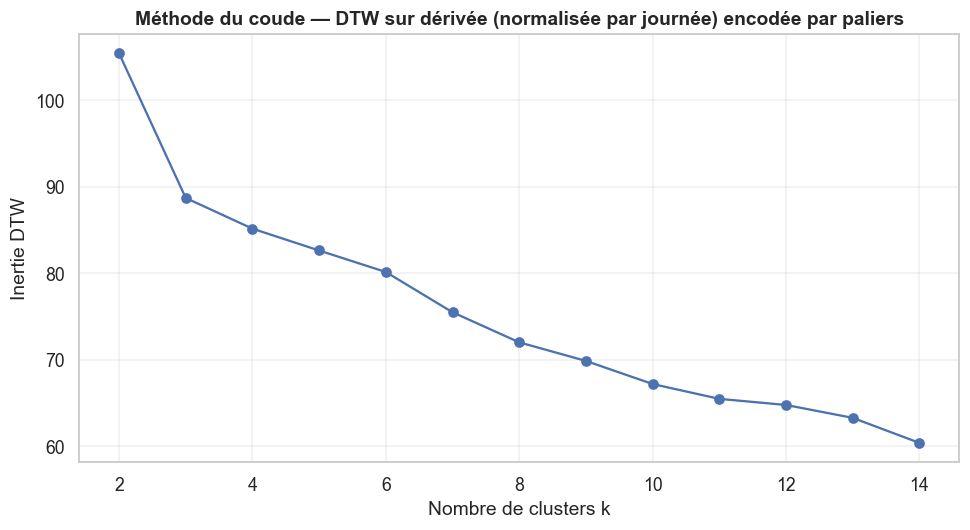

In [52]:
# Choix de K par méthode du coude (sous-échantillon — DTW coûteux)
SUBSAMPLE_PALIER = 800
rng_palier = np.random.RandomState(0)
sub_idx_palier = rng_palier.choice(len(D_palier),
                                   min(SUBSAMPLE_PALIER, len(D_palier)), replace=False)
X_sub_palier = D_palier[sub_idx_palier][:, :, None].astype(float)

ks_palier = range(2, 15)
inerties_palier = []
for k in ks_palier:
    km = TimeSeriesKMeans(n_clusters=k, metric='dtw',
                          metric_params={'global_constraint': 'sakoe_chiba', 'sakoe_chiba_radius': 6},
                          random_state=42, n_jobs=-1)
    km.fit(X_sub_palier)
    inerties_palier.append(km.inertia_)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(list(ks_palier), inerties_palier, marker='o')
ax.set_xlabel('Nombre de clusters k'); ax.set_ylabel('Inertie DTW')
ax.set_title('Méthode du coude — DTW sur dérivée (normalisée par journée) encodée par paliers',
             fontweight='bold')
ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


In [53]:
K_PALIER = 7

X_palier = D_palier[:, :, None].astype(float)   # (n_samples, 144, 1)

model_palier = TimeSeriesKMeans(
    n_clusters=K_PALIER, metric='dtw',
    metric_params={'global_constraint': 'sakoe_chiba', 'sakoe_chiba_radius': 6},
    random_state=42, n_jobs=-1, verbose=1,
)
labels_palier = model_palier.fit_predict(X_palier)
meta_palier = meta_day.copy()
meta_palier['cluster_palier'] = labels_palier

print(f'K_PALIER={K_PALIER}')
print('Taille des clusters (DTW sur paliers) :')
print(pd.Series(labels_palier).value_counts().sort_index().to_string())


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 176 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 426 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 776 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 1226 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 1776 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 2426 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 2998 out of 2998 | elapsed:    0.1s finished
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 176 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 426 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 776 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 1226 tasks      | elapsed:    0.0s
[Parallel(n_job

90.929 --> 

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 176 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 426 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 776 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 1226 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 1776 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 2426 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 3176 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 4026 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-1)]: Done 4976 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-1)]: Done 6026 tasks      | elapsed:    0.3s
[Parallel(n_jobs=-1)]: Done 7176 tasks      | elapsed:    0.4s
[Parallel(n_jobs=-1)]: Done 8426 tasks      | elapsed:    0.5s
[Parallel(n_jobs=-1)]: Done 9776 tasks      | elapsed:    0.5s
[Parallel(n_jobs=-1)]: Done 11226 tasks 

73.974 --> 

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 176 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 426 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 776 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 1226 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 1776 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 2426 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 3176 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 4026 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-1)]: Done 4976 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-1)]: Done 6026 tasks      | elapsed:    0.3s
[Parallel(n_jobs=-1)]: Done 7176 tasks      | elapsed:    0.4s
[Parallel(n_jobs=-1)]: Done 8426 tasks      | elapsed:    0.5s
[Parallel(n_jobs=-1)]: Done 9776 tasks      | elapsed:    0.6s
[Parallel(n_jobs=-1)]: Done 11226 tasks 

...

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 176 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 426 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 776 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 1226 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 1776 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 2426 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 3176 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 4026 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-1)]: Done 4976 tasks      | elapsed:    0.3s
[Parallel(n_jobs=-1)]: Done 6026 tasks      | elapsed:    0.3s
[Parallel(n_jobs=-1)]: Done 7176 tasks      | elapsed:    0.4s
[Parallel(n_jobs=-1)]: Done 8426 tasks      | elapsed:    0.5s
[Parallel(n_jobs=-1)]: Done 9776 tasks      | elapsed:    0.6s
[Parallel(n_jobs=-1)]: Done 11226 tasks 

73.800 --> 


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 176 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 426 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 776 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 1226 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 1776 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 2426 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 3176 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 4026 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-1)]: Done 4976 tasks      | elapsed:    0.3s
[Parallel(n_jobs=-1)]: Done 6026 tasks      | elapsed:    0.4s
[Parallel(n_jobs=-1)]: Done 7176 tasks      | elapsed:    0.4s
[Parallel(n_jobs=-1)]: Done 8426 tasks      | elapsed:    0.5s
[Parallel(n_jobs=-1)]: Done 9776 tasks      | elapsed:    0.6s
[Parallel(n_jobs=-1)]: Done 11226 tasks 

K_PALIER=7
Taille des clusters (DTW sur paliers) :
0    172
1    538
2    512
3    630
4    362
5    237
6    547


[Parallel(n_jobs=-1)]: Done 18026 tasks      | elapsed:    1.1s
[Parallel(n_jobs=-1)]: Done 19976 tasks      | elapsed:    1.2s
[Parallel(n_jobs=-1)]: Done 20986 out of 20986 | elapsed:    1.3s finished


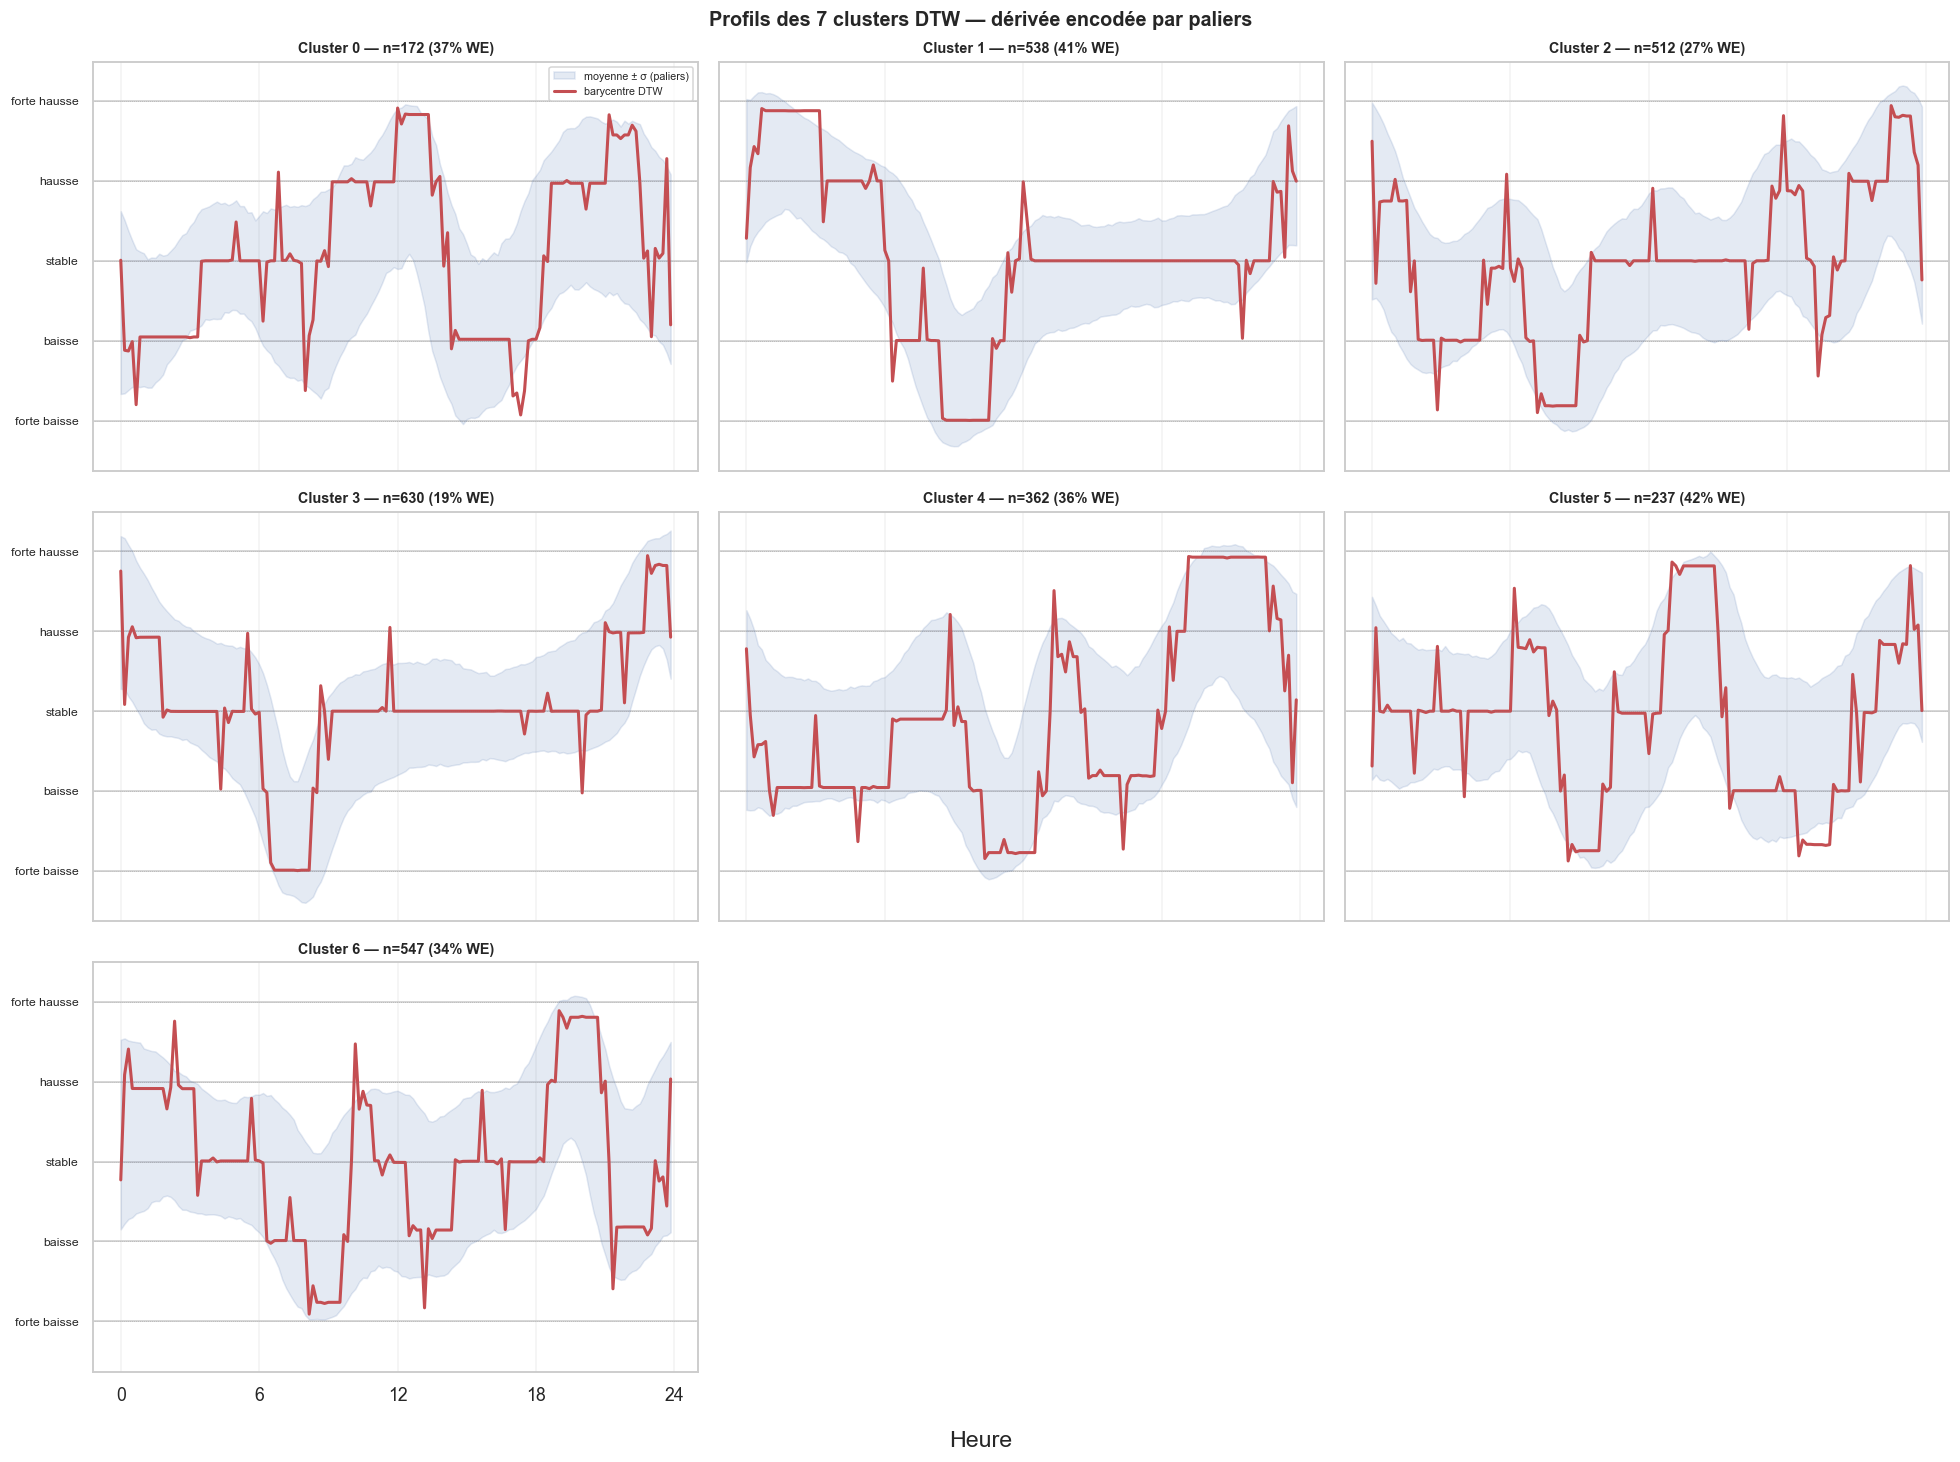

In [54]:
hours = np.arange(144) / 6
n_cols = min(K_PALIER, 3)
n_rows = int(np.ceil(K_PALIER / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4.5 * n_rows),
                         sharex=True, sharey=True)
axes = np.atleast_1d(axes).ravel()

for c in range(K_PALIER):
    ax = axes[c]
    sel = labels_palier == c
    n = sel.sum()
    pct_we = meta_palier.loc[sel, 'we'].mean() * 100

    bary = model_palier.cluster_centers_[c].ravel()
    m, s = D_palier[sel].mean(axis=0), D_palier[sel].std(axis=0)

    ax.fill_between(hours, m - s, m + s, alpha=0.15, color='#4C72B0',
                    label='moyenne ± σ (paliers)')
    ax.plot(hours, bary, lw=2, color='#C44E52', label='barycentre DTW')
    for p in range(N_PALIERS):
        ax.axhline(p, color='grey', lw=0.5, ls=':', alpha=0.5)
    ax.set_yticks(range(N_PALIERS)); ax.set_yticklabels(PALIER_NOMS, fontsize=8)
    ax.set_title(f'Cluster {c} — n={n:,} ({pct_we:.0f}% WE)', fontsize=9.5, fontweight='bold')
    ax.set_xticks([0, 6, 12, 18, 24])
    ax.grid(True, axis='x', alpha=0.25)
    if c == 0:
        ax.legend(fontsize=7, loc='upper right')

for ax in axes[K_PALIER:]:
    ax.axis('off')

fig.supxlabel('Heure')
plt.suptitle(f'Profils des {K_PALIER} clusters DTW — dérivée encodée par paliers',
            fontweight='bold', fontsize=13)
plt.tight_layout(); plt.show()


Journées affichées (2 par cluster DTW paliers) :
CODELIEU       DATE  cluster_palier
 06-M001 2004-01-28               0
 10-M036 2005-10-14               0
 11-M075 2004-04-26               1
 02-M039 2004-05-03               1
 07-M022 2005-12-17               2
 12-M015 2003-11-11               2
 10-M034 2005-10-06               3
 05-M017 2004-06-08               3
 06-M022 2004-01-14               4
 02-M045 2004-02-19               4
 06-M075 2004-10-26               5
 02-M032 2003-11-25               5
 05-M003 2003-10-09               6
 02-M069 2004-03-13               6


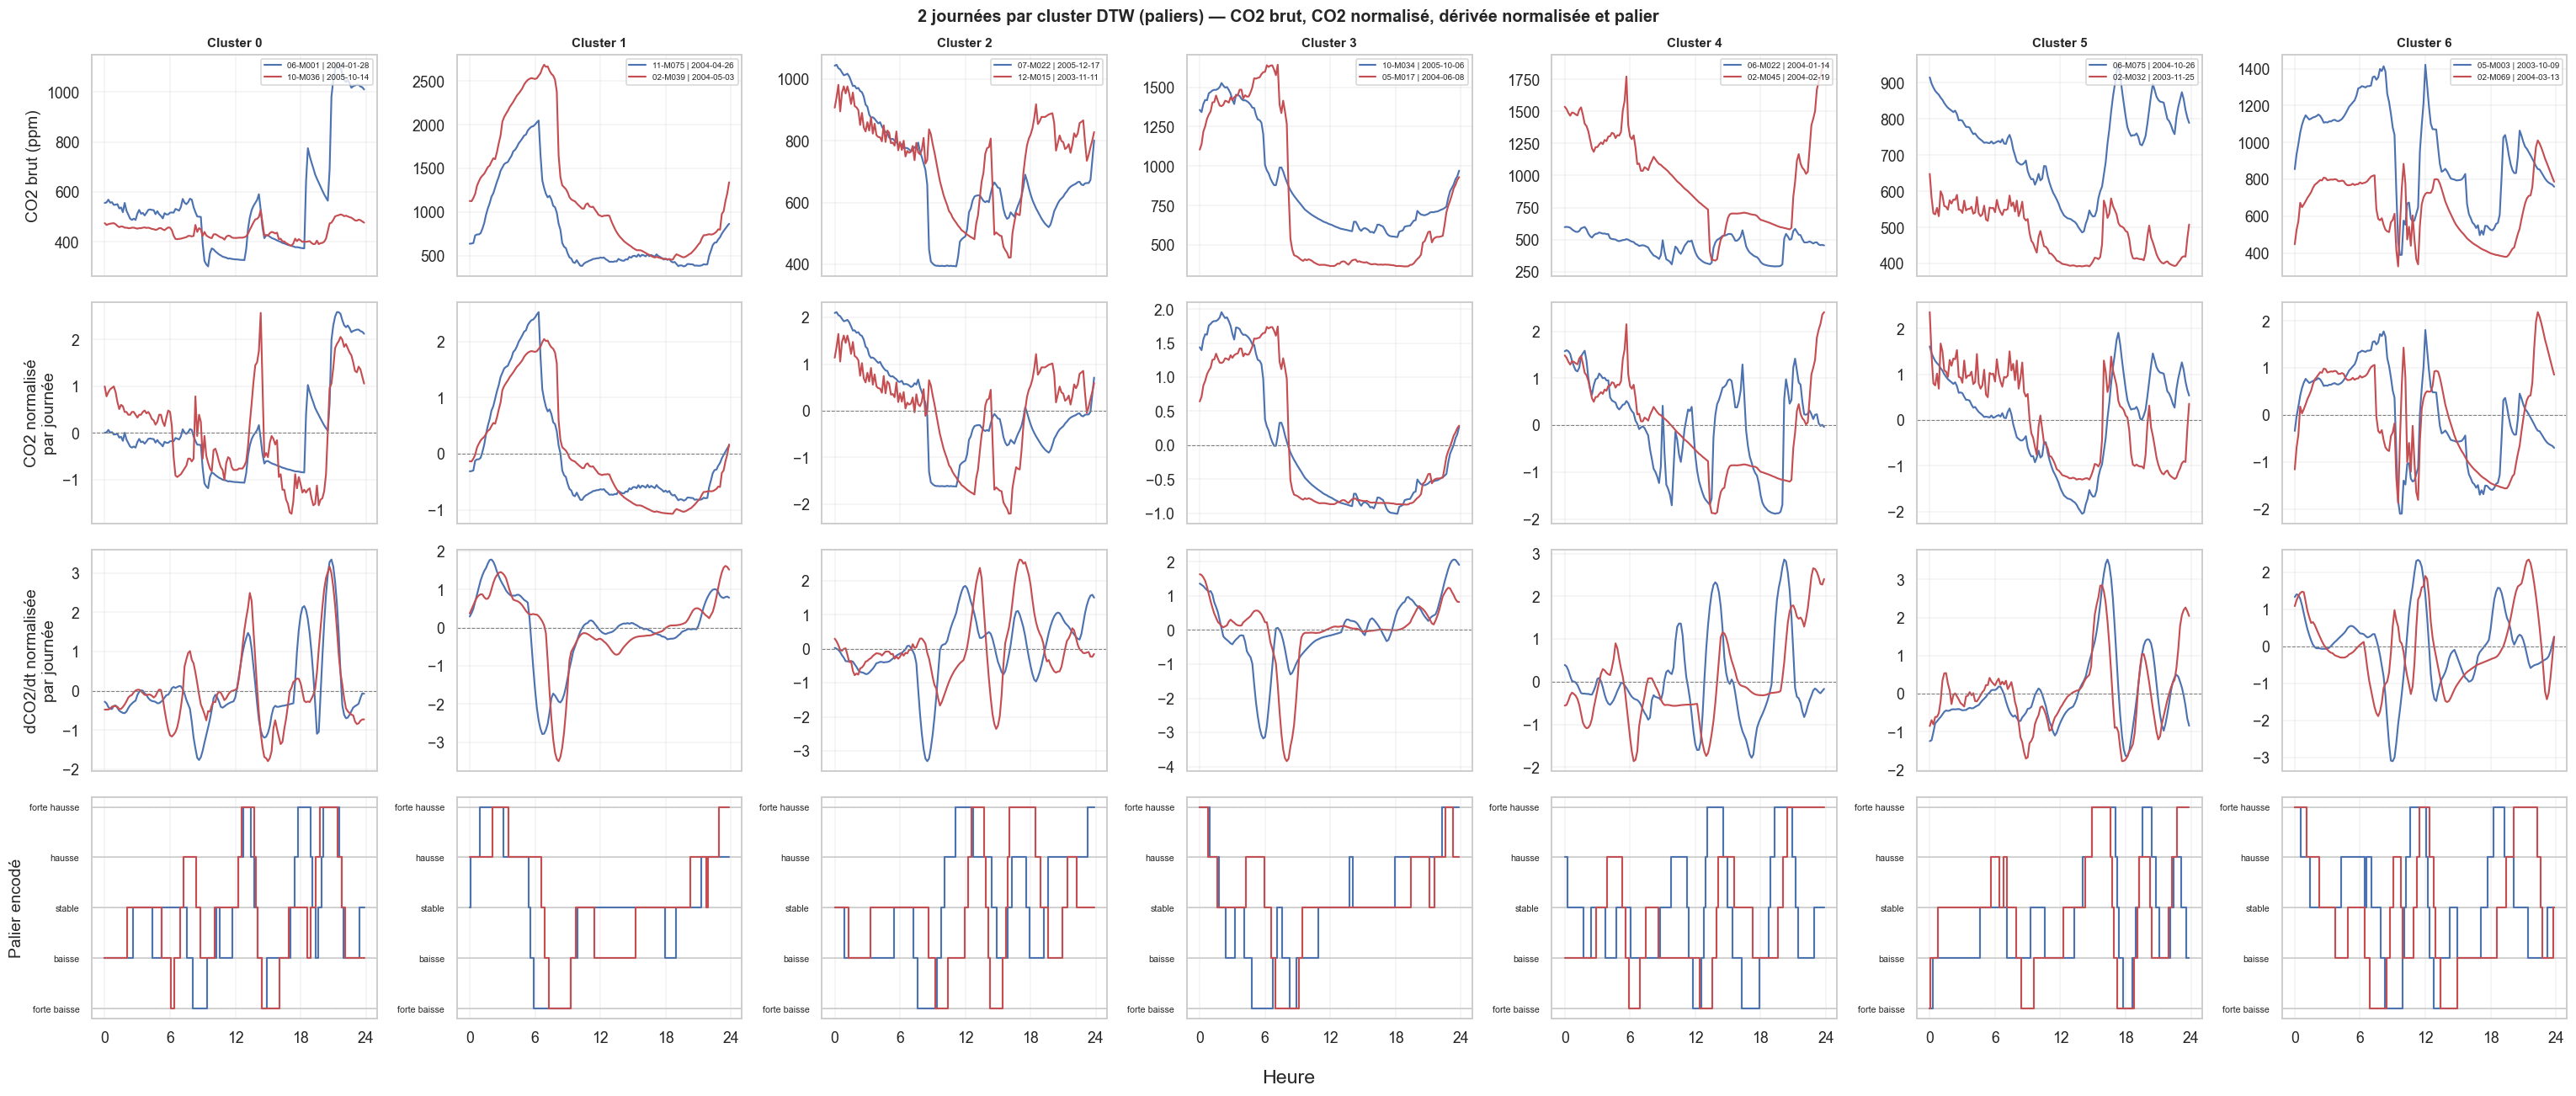

In [56]:
# 2 journées par cluster (DTW sur paliers) — CO2 brut + CO2 normalisé par journée
# + dérivée (normalisée par journée) + encodage par palier
EX_PALIER = pd.concat([d.sample(min(2, len(d)), random_state=42)
                       for _, d in meta_palier.groupby('cluster_palier')])
print('Journées affichées (2 par cluster DTW paliers) :')
print(EX_PALIER[['CODELIEU', 'DATE', 'cluster_palier']].to_string(index=False))

# CO2 normalisé PAR JOURNEE (meme principe que D_day, applique au niveau plutot qu'a la derivee)
mu_co2_day  = raw_co2_day.mean(axis=1, keepdims=True)
sig_co2_day = raw_co2_day.std(axis=1, keepdims=True)
co2_day_norm = (raw_co2_day - mu_co2_day) / np.clip(sig_co2_day, 1e-9, None)

fig, axes = plt.subplots(4, K_PALIER, figsize=(4 * K_PALIER, 12), sharex=True)
colors_ex = ['#4C72B0', '#C44E52']

for c in range(K_PALIER):
    sub = EX_PALIER[EX_PALIER['cluster_palier'] == c]

    # Ligne 1 : CO2 brut (ppm)
    ax = axes[0, c]
    for (idx, row), color in zip(sub.iterrows(), colors_ex):
        ax.plot(hours, raw_co2_day[idx], lw=1.4, color=color,
                label=f"{row['CODELIEU']} | {row['DATE'].date()}")
    ax.set_title(f'Cluster {c}', fontsize=10, fontweight='bold')
    ax.set_xticks([0, 6, 12, 18, 24])
    ax.grid(True, alpha=0.25)
    ax.legend(fontsize=6.5, loc='upper right')
    if c == 0:
        ax.set_ylabel('CO2 brut (ppm)')

    # Ligne 2 : CO2 normalisé par journée (z-score)
    ax = axes[1, c]
    for (idx, row), color in zip(sub.iterrows(), colors_ex):
        ax.plot(hours, co2_day_norm[idx], lw=1.4, color=color)
    ax.axhline(0, color='grey', lw=0.7, ls='--')
    ax.set_xticks([0, 6, 12, 18, 24])
    ax.grid(True, alpha=0.25)
    if c == 0:
        ax.set_ylabel('CO2 normalisé\npar journée')

    # Ligne 3 : dérivée normalisée par journée
    ax = axes[2, c]
    for (idx, row), color in zip(sub.iterrows(), colors_ex):
        ax.plot(hours, D_day[idx], lw=1.4, color=color)
    ax.axhline(0, color='grey', lw=0.7, ls='--')
    ax.set_xticks([0, 6, 12, 18, 24])
    ax.grid(True, alpha=0.25)
    if c == 0:
        ax.set_ylabel('dCO2/dt normalisée\npar journée')

    # Ligne 4 : encodage par palier
    ax = axes[3, c]
    for (idx, row), color in zip(sub.iterrows(), colors_ex):
        ax.step(hours, D_palier[idx], where='mid', lw=1.4, color=color)
    for p in range(N_PALIERS):
        ax.axhline(p, color='grey', lw=0.4, ls=':', alpha=0.5)
    ax.set_yticks(range(N_PALIERS)); ax.set_yticklabels(PALIER_NOMS, fontsize=7)
    ax.set_xticks([0, 6, 12, 18, 24])
    ax.grid(True, axis='x', alpha=0.25)
    if c == 0:
        ax.set_ylabel('Palier encodé')

fig.supxlabel('Heure')
plt.suptitle('2 journées par cluster DTW (paliers) — CO2 brut, CO2 normalisé, dérivée normalisée et palier',
            fontweight='bold', fontsize=13)
plt.tight_layout(); plt.show()


### K-means  sur les paliers — alternative au DTW



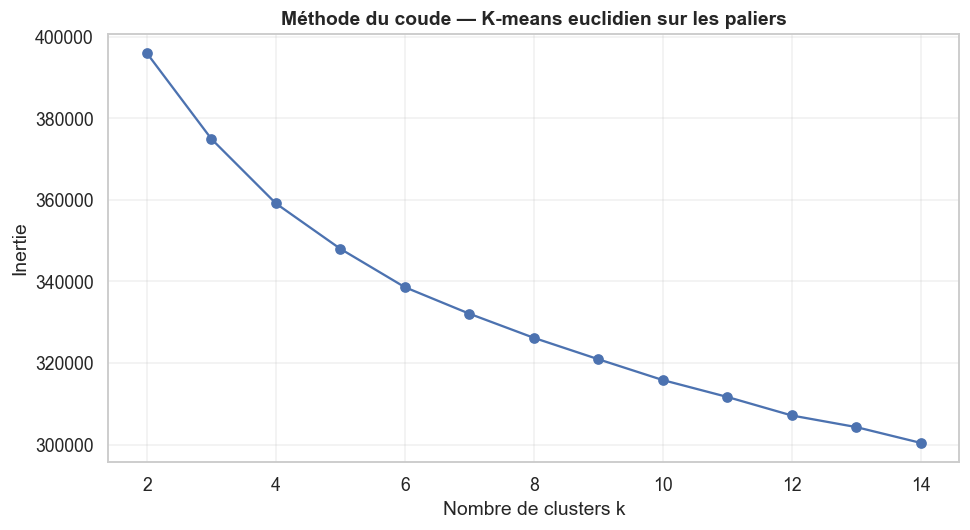

In [57]:
# Choix de K par méthode du coude — K-means euclidien, rapide (pas de sous-échantillonnage)
ks_palier_km = range(2, 15)
inerties_palier_km = []
for k in ks_palier_km:
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    km.fit(D_palier)
    inerties_palier_km.append(km.inertia_)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(list(ks_palier_km), inerties_palier_km, marker='o')
ax.set_xlabel('Nombre de clusters k'); ax.set_ylabel('Inertie')
ax.set_title('Méthode du coude — K-means euclidien sur les paliers', fontweight='bold')
ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


In [58]:
K_PALIER_KM = 6

km_palier = KMeans(n_clusters=K_PALIER_KM, random_state=42, n_init=20)
labels_palier_km = km_palier.fit_predict(D_palier)
meta_palier_km = meta_day.copy()
meta_palier_km['cluster_palier_km'] = labels_palier_km

print(f'K_PALIER_KM={K_PALIER_KM}')
print('Taille des clusters (K-means euclidien sur paliers) :')
print(pd.Series(labels_palier_km).value_counts().sort_index().to_string())


K_PALIER_KM=6
Taille des clusters (K-means euclidien sur paliers) :
0    603
1    356
2    729
3    356
4    392
5    562


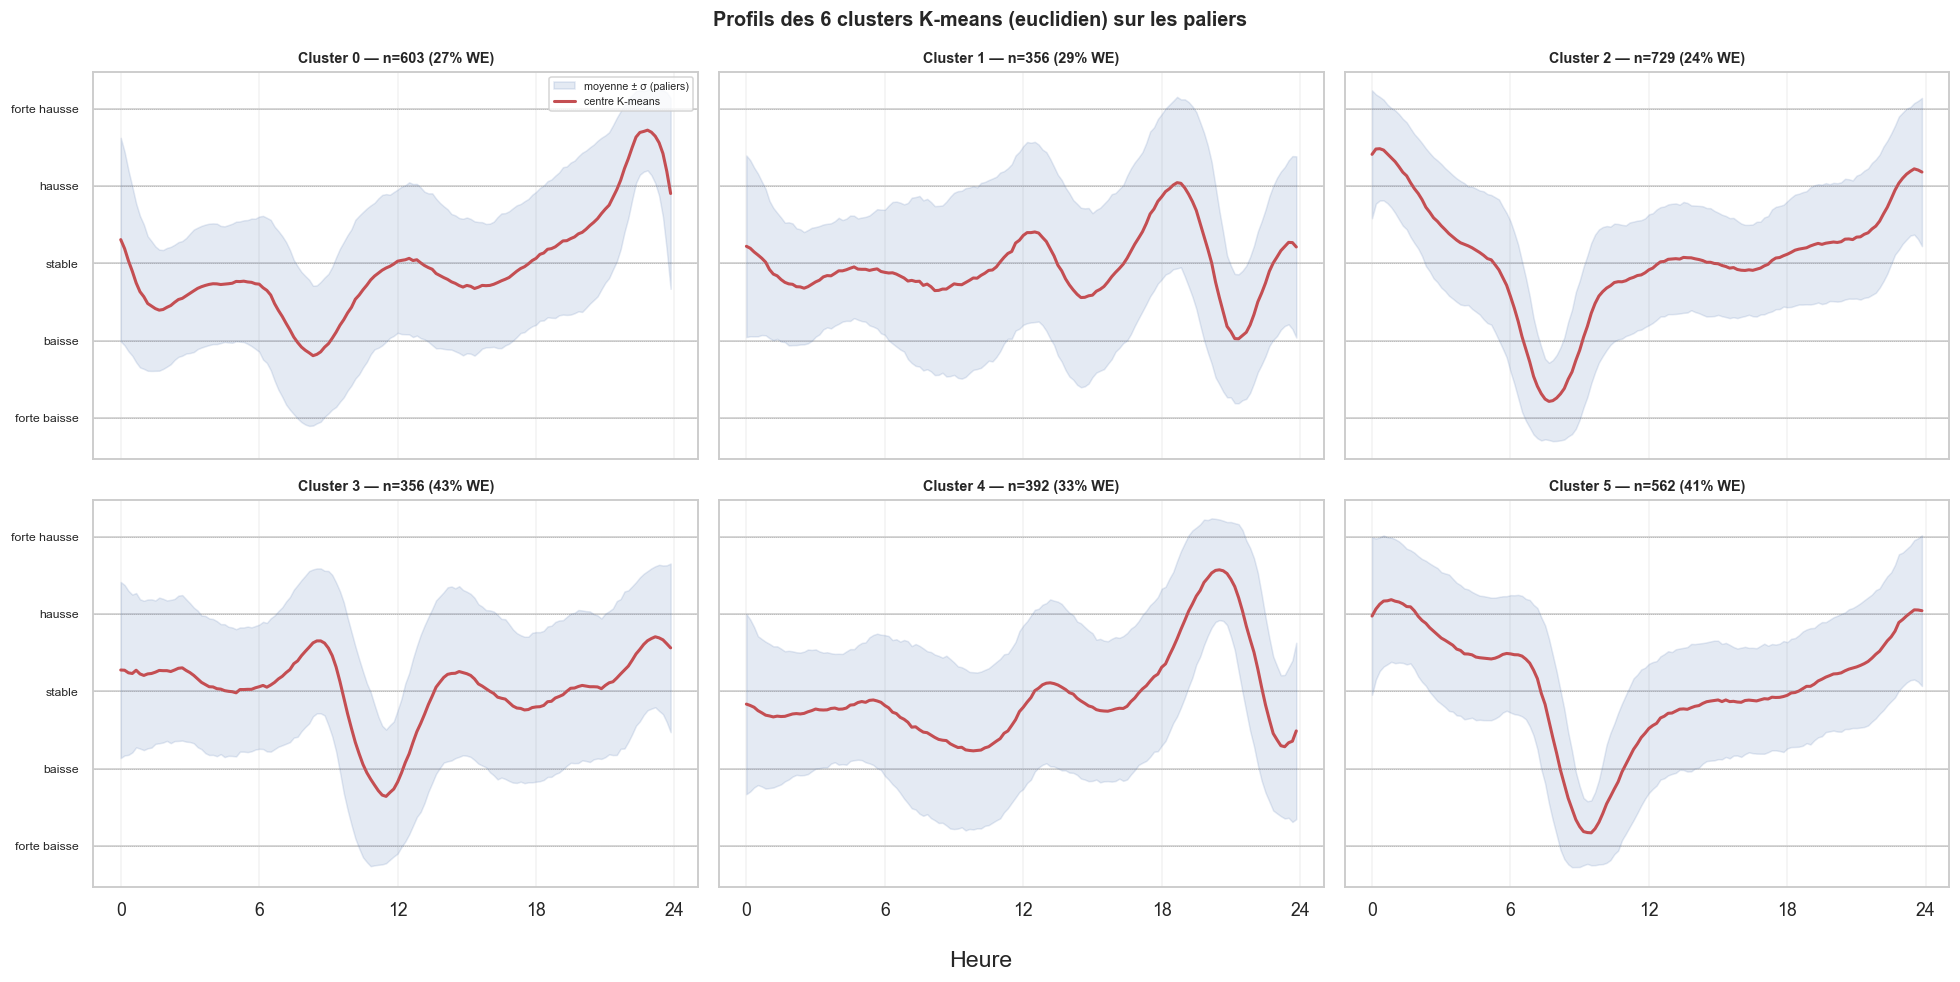

In [59]:
hours = np.arange(144) / 6
n_cols = min(K_PALIER_KM, 3)
n_rows = int(np.ceil(K_PALIER_KM / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4.5 * n_rows),
                         sharex=True, sharey=True)
axes = np.atleast_1d(axes).ravel()

for c in range(K_PALIER_KM):
    ax = axes[c]
    sel = labels_palier_km == c
    n = sel.sum()
    pct_we = meta_palier_km.loc[sel, 'we'].mean() * 100

    centre = km_palier.cluster_centers_[c]
    m, s = D_palier[sel].mean(axis=0), D_palier[sel].std(axis=0)

    ax.fill_between(hours, m - s, m + s, alpha=0.15, color='#4C72B0',
                    label='moyenne ± σ (paliers)')
    ax.plot(hours, centre, lw=2, color='#C44E52', label='centre K-means')
    for p in range(N_PALIERS):
        ax.axhline(p, color='grey', lw=0.5, ls=':', alpha=0.5)
    ax.set_yticks(range(N_PALIERS)); ax.set_yticklabels(PALIER_NOMS, fontsize=8)
    ax.set_title(f'Cluster {c} — n={n:,} ({pct_we:.0f}% WE)', fontsize=9.5, fontweight='bold')
    ax.set_xticks([0, 6, 12, 18, 24])
    ax.grid(True, axis='x', alpha=0.25)
    if c == 0:
        ax.legend(fontsize=7, loc='upper right')

for ax in axes[K_PALIER_KM:]:
    ax.axis('off')

fig.supxlabel('Heure')
plt.suptitle(f'Profils des {K_PALIER_KM} clusters K-means (euclidien) sur les paliers',
            fontweight='bold', fontsize=13)
plt.tight_layout(); plt.show()


### DTW sur la dérivée encodée par paliers — version NON normalisée


In [ ]:

raw_deriv_day_smooth = np.apply_along_axis(lambda x: savgol_filter(x, SG_WINDOW, SG_POLY),
                                           1, raw_deriv_day)

N_PALIERS_RAW = 5
PALIER_NOMS_RAW = ['forte baisse', 'baisse', 'stable', 'hausse', 'forte hausse']
QUANTILES_RAW = [0.10, 0.30, 0.70, 0.90]   # forte=10% de chaque cote, stable=40%, baisse/hausse=20%
seuils_raw = np.quantile(raw_deriv_day_smooth.ravel(), QUANTILES_RAW)
print('Seuils (quantiles empiriques asymetriques, ppm/h) :', seuils_raw.round(1))

D_palier_raw = np.digitize(raw_deriv_day_smooth, seuils_raw)

repartition_raw = (pd.Series(D_palier_raw.ravel()).value_counts(normalize=True)
                   .sort_index().mul(100).round(1))
repartition_raw.index = [PALIER_NOMS_RAW[i] for i in repartition_raw.index]
print('\nRépartition des points par palier (%) :')
print(repartition_raw.to_string())


Seuils (quantiles empiriques asymetriques, ppm/h) : [-117.   -22.8   28.8  157.6]

Répartition des points par palier (%) :
forte baisse    10.0
baisse          20.0
stable          40.0
hausse          20.0
forte hausse    10.0


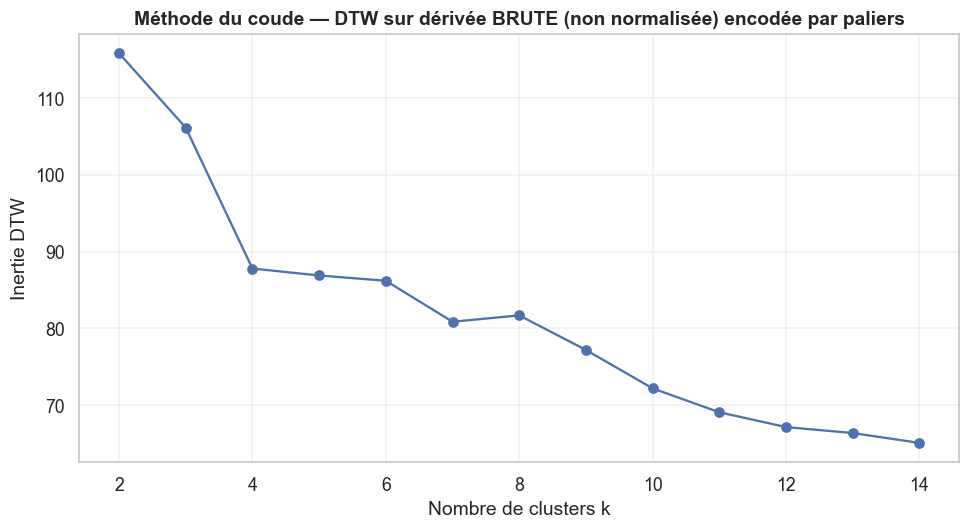

In [61]:
# Choix de K par méthode du coude 
SUBSAMPLE_PALIER_RAW = 800
rng_palier_raw = np.random.RandomState(0)
sub_idx_palier_raw = rng_palier_raw.choice(len(D_palier_raw),
                                           min(SUBSAMPLE_PALIER_RAW, len(D_palier_raw)),
                                           replace=False)
X_sub_palier_raw = D_palier_raw[sub_idx_palier_raw][:, :, None].astype(float)

ks_palier_raw = range(2, 15)
inerties_palier_raw = []
for k in ks_palier_raw:
    km = TimeSeriesKMeans(n_clusters=k, metric='dtw',
                          metric_params={'global_constraint': 'sakoe_chiba', 'sakoe_chiba_radius': 6},
                          random_state=42, n_jobs=-1)
    km.fit(X_sub_palier_raw)
    inerties_palier_raw.append(km.inertia_)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(list(ks_palier_raw), inerties_palier_raw, marker='o')
ax.set_xlabel('Nombre de clusters k'); ax.set_ylabel('Inertie DTW')
ax.set_title('Méthode du coude — DTW sur dérivée BRUTE (non normalisée) encodée par paliers',
             fontweight='bold')
ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


In [ ]:
K_PALIER_RAW = 4

X_palier_raw = D_palier_raw[:, :, None].astype(float)

model_palier_raw = TimeSeriesKMeans(
    n_clusters=K_PALIER_RAW, metric='dtw',
    metric_params={'global_constraint': 'sakoe_chiba', 'sakoe_chiba_radius': 6},
    random_state=42, n_jobs=-1, verbose=1,
)
labels_palier_raw = model_palier_raw.fit_predict(X_palier_raw)
meta_palier_raw = meta_day.copy()
meta_palier_raw['cluster_palier_raw'] = labels_palier_raw

print(f'K_PALIER_RAW={K_PALIER_RAW}')
print('Taille des clusters (DTW sur paliers, non normalisé) :')
print(pd.Series(labels_palier_raw).value_counts().sort_index().to_string())


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 176 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 426 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 776 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 1226 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 1776 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 2426 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 2998 out of 2998 | elapsed:    0.1s finished
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 176 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 426 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 776 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 1226 tasks      | elapsed:    0.0s
[Parallel(n_job

106.414 --> 

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 176 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 426 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 776 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 1226 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 1776 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 2426 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 3176 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 4026 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-1)]: Done 4976 tasks      | elapsed:    0.3s
[Parallel(n_jobs=-1)]: Done 6026 tasks      | elapsed:    0.3s
[Parallel(n_jobs=-1)]: Done 7176 tasks      | elapsed:    0.4s
[Parallel(n_jobs=-1)]: Done 8426 tasks      | elapsed:    0.5s
[Parallel(n_jobs=-1)]: Done 9776 tasks      | elapsed:    0.6s
[Parallel(n_jobs=-1)]: Done 11226 tasks 

91.078 --> 

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 176 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 426 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 776 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 1226 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 1776 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 2426 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 3176 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 4026 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-1)]: Done 4976 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-1)]: Done 6026 tasks      | elapsed:    0.3s
[Parallel(n_jobs=-1)]: Done 7176 tasks      | elapsed:    0.3s
[Parallel(n_jobs=-1)]: Done 8426 tasks      | elapsed:    0.4s
[Parallel(n_jobs=-1)]: Done 9776 tasks      | elapsed:    0.5s
[Parallel(n_jobs=-1)]: Done 11226 tasks 

...

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 176 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 426 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 776 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 1226 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 1776 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 2426 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 3176 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 4026 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-1)]: Done 4976 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-1)]: Done 6026 tasks      | elapsed:    0.3s
[Parallel(n_jobs=-1)]: Done 7176 tasks      | elapsed:    0.4s
[Parallel(n_jobs=-1)]: Done 8426 tasks      | elapsed:    0.4s
[Parallel(n_jobs=-1)]: Done 9776 tasks      | elapsed:    0.5s
[Parallel(n_jobs=-1)]: Done 11226 tasks 

91.441 --> 


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 176 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 426 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 776 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 1226 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 1776 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 2426 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 3176 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 4026 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-1)]: Done 4976 tasks      | elapsed:    0.3s
[Parallel(n_jobs=-1)]: Done 6026 tasks      | elapsed:    0.4s
[Parallel(n_jobs=-1)]: Done 7176 tasks      | elapsed:    0.4s
[Parallel(n_jobs=-1)]: Done 8426 tasks      | elapsed:    0.5s


K_PALIER_RAW=4
Taille des clusters (DTW sur paliers, non normalisé) :
0     476
1    1319
2     706
3     497


[Parallel(n_jobs=-1)]: Done 9776 tasks      | elapsed:    0.6s
[Parallel(n_jobs=-1)]: Done 11226 tasks      | elapsed:    0.7s
[Parallel(n_jobs=-1)]: Done 11992 out of 11992 | elapsed:    0.7s finished


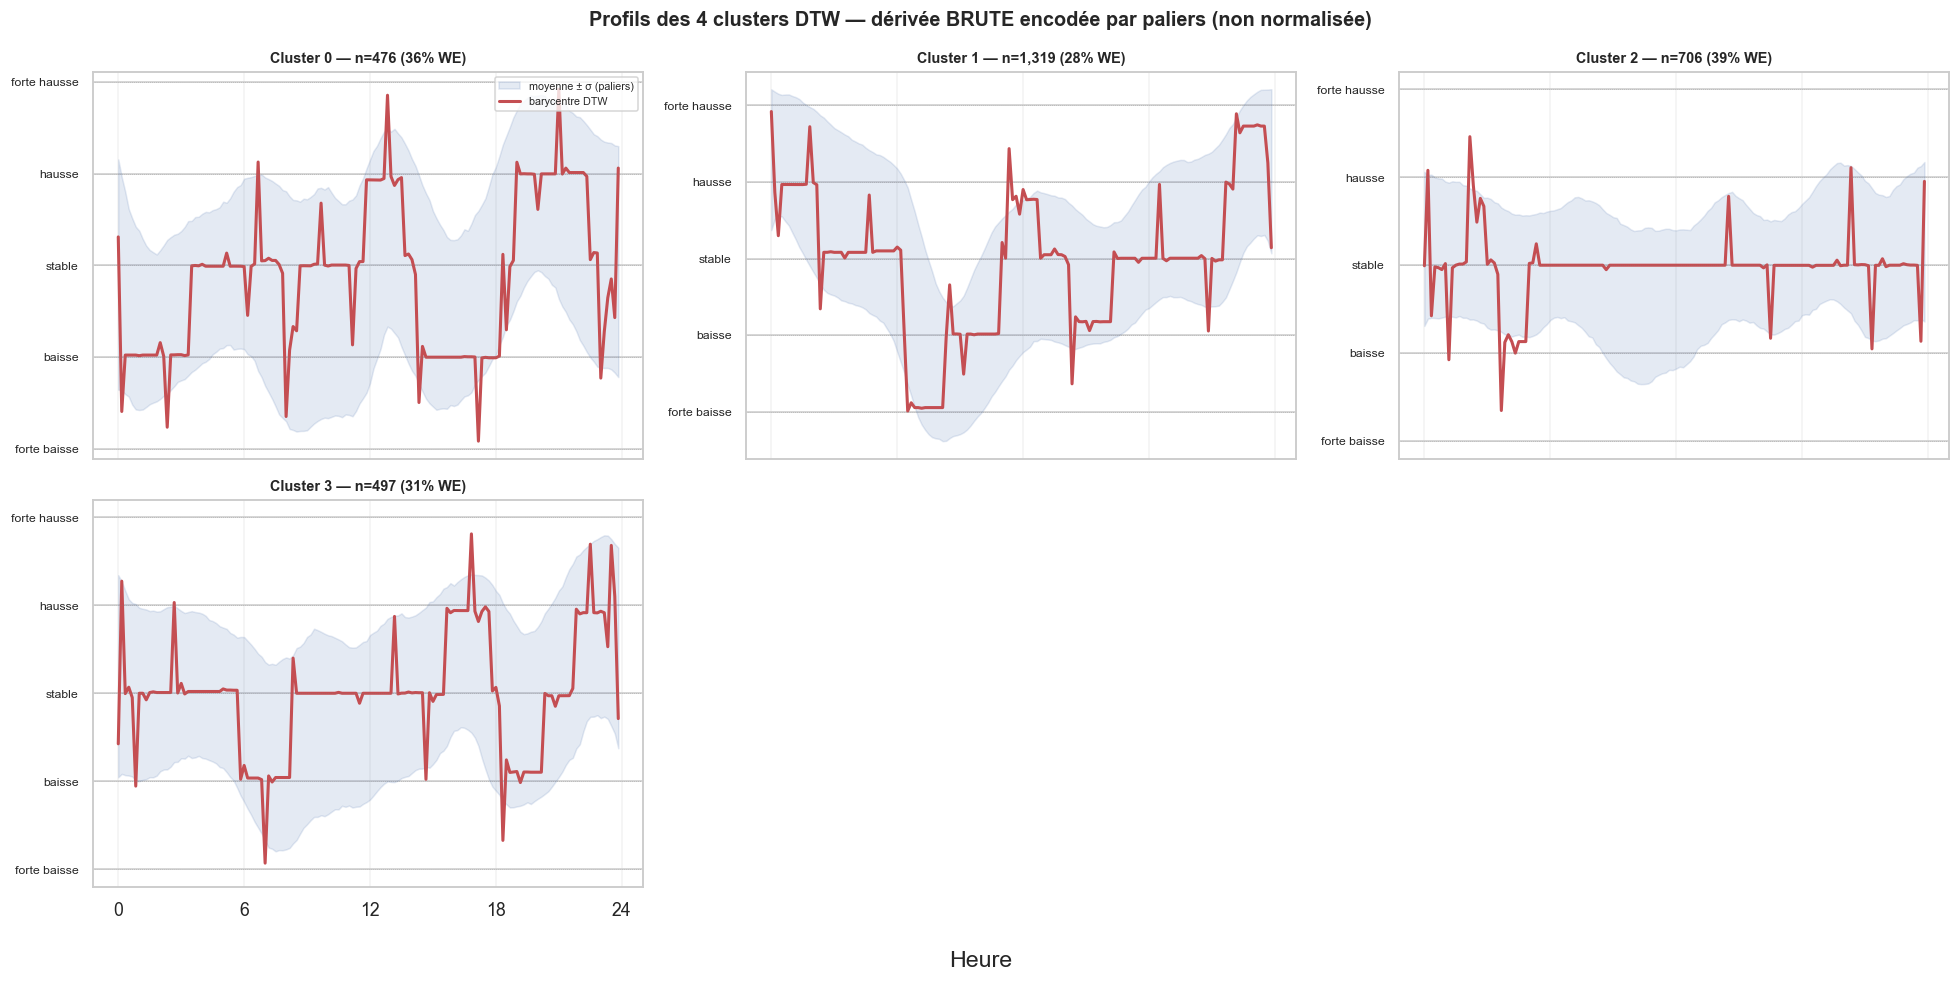

In [63]:
hours = np.arange(144) / 6
n_cols = min(K_PALIER_RAW, 3)
n_rows = int(np.ceil(K_PALIER_RAW / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4.5 * n_rows), sharex=True)
axes = np.atleast_1d(axes).ravel()

for c in range(K_PALIER_RAW):
    ax = axes[c]
    sel = labels_palier_raw == c
    n = sel.sum()
    pct_we = meta_palier_raw.loc[sel, 'we'].mean() * 100

    bary = model_palier_raw.cluster_centers_[c].ravel()
    m, s = D_palier_raw[sel].mean(axis=0), D_palier_raw[sel].std(axis=0)

    ax.fill_between(hours, m - s, m + s, alpha=0.15, color='#4C72B0',
                    label='moyenne ± σ (paliers)')
    ax.plot(hours, bary, lw=2, color='#C44E52', label='barycentre DTW')
    for p in range(N_PALIERS_RAW):
        ax.axhline(p, color='grey', lw=0.5, ls=':', alpha=0.5)
    ax.set_yticks(range(N_PALIERS_RAW)); ax.set_yticklabels(PALIER_NOMS_RAW, fontsize=8)
    ax.set_title(f'Cluster {c} — n={n:,} ({pct_we:.0f}% WE)', fontsize=9.5, fontweight='bold')
    ax.set_xticks([0, 6, 12, 18, 24])
    ax.grid(True, axis='x', alpha=0.25)
    if c == 0:
        ax.legend(fontsize=7, loc='upper right')

for ax in axes[K_PALIER_RAW:]:
    ax.axis('off')

fig.supxlabel('Heure')
plt.suptitle(f'Profils des {K_PALIER_RAW} clusters DTW — dérivée BRUTE encodée par paliers (non normalisée)',
            fontweight='bold', fontsize=13)
plt.tight_layout(); plt.show()


Journées affichées (2 par cluster DTW paliers, non normalisé) :
CODELIEU       DATE  cluster_palier_raw
 12-M020 2004-06-22                   0
 02-M038 2005-03-10                   0
 05-M071 2004-05-21                   1
 10-M026 2005-10-16                   1
 10-M048 2005-06-18                   2
 02-M072 2004-06-13                   2
 12-M012 2003-11-10                   3
 02-M089 2004-05-18                   3


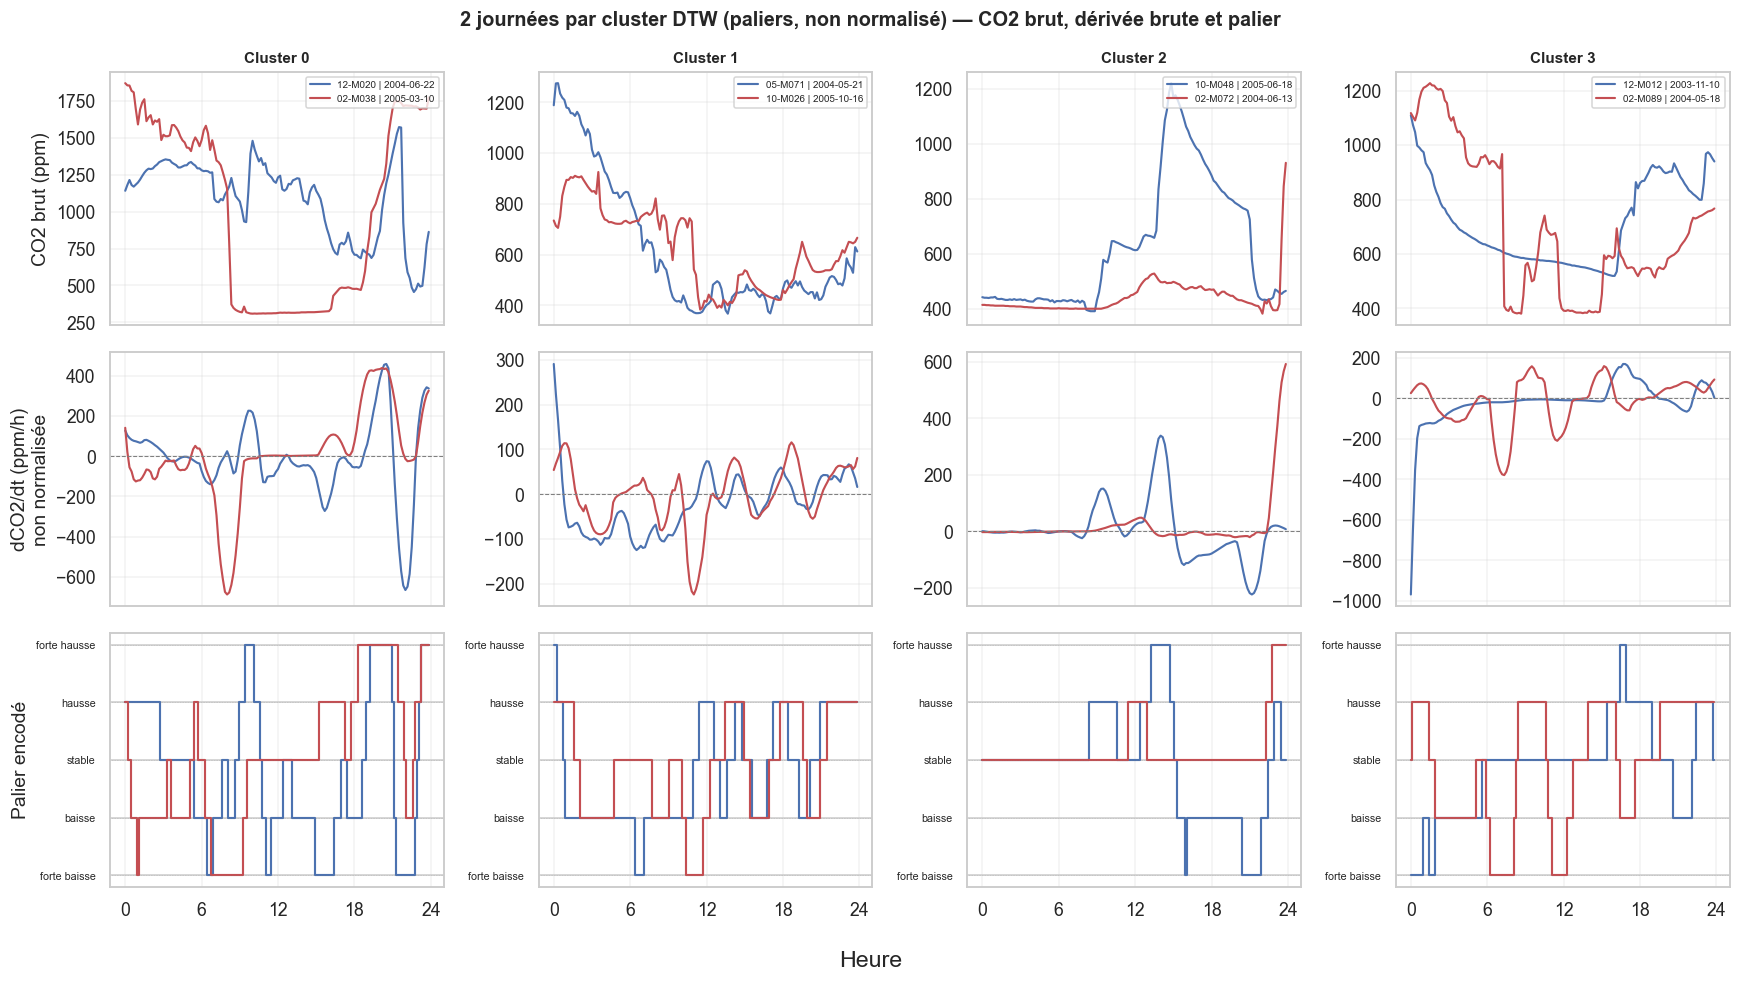

In [64]:
# 2 journées par cluster (DTW paliers, version NON normalisée) — CO2 brut + dérivée brute + palier
EX_PALIER_RAW = pd.concat([d.sample(min(2, len(d)), random_state=42)
                          for _, d in meta_palier_raw.groupby('cluster_palier_raw')])
print('Journées affichées (2 par cluster DTW paliers, non normalisé) :')
print(EX_PALIER_RAW[['CODELIEU', 'DATE', 'cluster_palier_raw']].to_string(index=False))

fig, axes = plt.subplots(3, K_PALIER_RAW, figsize=(4 * K_PALIER_RAW, 9), sharex=True)
colors_ex = ['#4C72B0', '#C44E52']

for c in range(K_PALIER_RAW):
    sub = EX_PALIER_RAW[EX_PALIER_RAW['cluster_palier_raw'] == c]

    # Ligne 1 : CO2 brut (ppm)
    ax = axes[0, c]
    for (idx, row), color in zip(sub.iterrows(), colors_ex):
        ax.plot(hours, raw_co2_day[idx], lw=1.4, color=color,
                label=f"{row['CODELIEU']} | {row['DATE'].date()}")
    ax.set_title(f'Cluster {c}', fontsize=10, fontweight='bold')
    ax.set_xticks([0, 6, 12, 18, 24])
    ax.grid(True, alpha=0.25)
    ax.legend(fontsize=6.5, loc='upper right')
    if c == 0:
        ax.set_ylabel('CO2 brut (ppm)')

    # Ligne 2 : dérivée brute (ppm/h, non normalisée)
    ax = axes[1, c]
    for (idx, row), color in zip(sub.iterrows(), colors_ex):
        ax.plot(hours, raw_deriv_day[idx], lw=1.4, color=color)
    ax.axhline(0, color='grey', lw=0.7, ls='--')
    ax.set_xticks([0, 6, 12, 18, 24])
    ax.grid(True, alpha=0.25)
    if c == 0:
        ax.set_ylabel('dCO2/dt (ppm/h)\nnon normalisée')

    # Ligne 3 : encodage par palier (non normalise)
    ax = axes[2, c]
    for (idx, row), color in zip(sub.iterrows(), colors_ex):
        ax.step(hours, D_palier_raw[idx], where='mid', lw=1.4, color=color)
    for p in range(N_PALIERS_RAW):
        ax.axhline(p, color='grey', lw=0.4, ls=':', alpha=0.5)
    ax.set_yticks(range(N_PALIERS_RAW)); ax.set_yticklabels(PALIER_NOMS_RAW, fontsize=7)
    ax.set_xticks([0, 6, 12, 18, 24])
    ax.grid(True, axis='x', alpha=0.25)
    if c == 0:
        ax.set_ylabel('Palier encodé')

fig.supxlabel('Heure')
plt.suptitle('2 journées par cluster DTW (paliers, non normalisé) — CO2 brut, dérivée brute et palier',
            fontweight='bold', fontsize=13)
plt.tight_layout(); plt.show()


## Clustering DTW multivarié — CO2 + température + humidité


In [ ]:
# Température / humidité — appareil QTR uniquement (même sonde que le CO2,
def _load_qtr_144(fname):
    df = pd.read_csv(f'{DATA}/Mesures_Confort_Dynamique/{fname}', sep='\t', encoding='latin1',
                     usecols=['CODELIEU', 'DATE_HEURE', 'VALEUR', 'APPAREIL'],
                     parse_dates=['DATE_HEURE'])
    df = df[df['APPAREIL'] == 'QTR']
    df['VALEUR'] = pd.to_numeric(df['VALEUR'], errors='coerce')
    df = df.dropna(subset=['VALEUR'])
    df['DATE'] = df['DATE_HEURE'].dt.normalize()
    df['slot'] = df['DATE_HEURE'].dt.hour * 6 + df['DATE_HEURE'].dt.minute // 10
    agg = df.groupby(['CODELIEU', 'DATE', 'slot'])['VALEUR'].mean().reset_index()

    piv_raw = (agg.pivot(index=['CODELIEU', 'DATE'], columns='slot', values='VALEUR')
              .reindex(columns=range(144)).dropna(axis=0))   # 144 tranches toutes renseignées

    # Normalisation du NIVEAU, PAR JOURNÉE (moyenne/écart-type de ses 144 points propres)
    mu = piv_raw.values.mean(axis=1, keepdims=True)
    sig = piv_raw.values.std(axis=1, keepdims=True)
    piv_z = pd.DataFrame((piv_raw.values - mu) / np.clip(sig, 1e-9, None),
                         index=piv_raw.index, columns=piv_raw.columns)
    return piv_raw, piv_z

piv_tpt, piv_tpt_z = _load_qtr_144('CNL1_SERIE_TPT.txt')
piv_hre, piv_hre_z = _load_qtr_144('CNL1_SERIE_HRE.txt')
print(f'Température (QTR) complète : {len(piv_tpt_z):,} journées — '
      f'Humidité (QTR) complète : {len(piv_hre_z):,} journées')

# Intersection avec les journées CO2 déjà retenues (dtw_tensor : piv_dco2 / daynorm_prep : piv_day)
common_idx = piv_dco2.index.intersection(piv_tpt_z.index).intersection(piv_hre_z.index)
print(f'Journées communes CO2 + température + humidité : {len(common_idx):,} / {len(piv_dco2):,} '
      f'(perte {(1 - len(common_idx) / len(piv_dco2)) * 100:.2f}%)')

D_multi   = piv_day.loc[common_idx].values     # dérivée CO2 normalisée par journée (daynorm_prep)
TPT_multi = piv_tpt_z.loc[common_idx].values
HRE_multi = piv_hre_z.loc[common_idx].values

X_multi = np.stack([D_multi, TPT_multi, HRE_multi], axis=-1)   # (n, 144, 3)
meta_multi = pd.DataFrame(index=common_idx).reset_index()
meta_multi['we'] = meta_multi['DATE'].dt.dayofweek >= 5
print(f'X_multi : {X_multi.shape}  (canaux : dCO2/dt, température, humidité — tous normalisés par journée)')


Température (QTR) complète : 3,046 journées — Humidité (QTR) complète : 3,034 journées
Journées communes CO2 + température + humidité : 2,986 / 2,998 (perte 0.40%)
X_multi : (2986, 144, 3)  (canaux : dCO2/dt, température, humidité — tous normalisés par journée)


In [66]:
# Standardisation globale, canal par canal (même logique que le DTW univarié)
n_samples_m, n_time_m, n_feat_m = X_multi.shape
scaler_multi = StandardScaler()
X_scaled_multi = (scaler_multi.fit_transform(X_multi.reshape(-1, n_feat_m))
                 .reshape(n_samples_m, n_time_m, n_feat_m))

print(f'X_scaled_multi : {X_scaled_multi.shape}')
print('Moyenne par canal :', X_scaled_multi.reshape(-1, n_feat_m).mean(axis=0).round(3))
print('Std par canal     :', X_scaled_multi.reshape(-1, n_feat_m).std(axis=0).round(3))


NameError: name 'StandardScaler' is not defined

In [ ]:
# Choix de K par méthode du coude (sous-échantillon — DTW multivarié coûteux)
SUBSAMPLE_MULTI = 800
rng_multi = np.random.RandomState(0)
sub_idx_multi = rng_multi.choice(len(X_scaled_multi),
                                 min(SUBSAMPLE_MULTI, len(X_scaled_multi)), replace=False)
X_sub_multi = X_scaled_multi[sub_idx_multi]

ks_multi = range(2, 13)
inerties_multi = []
for k in ks_multi:
    km = TimeSeriesKMeans(n_clusters=k, metric='dtw',
                          metric_params={'global_constraint': 'sakoe_chiba', 'sakoe_chiba_radius': 6},
                          random_state=42, n_jobs=-1)
    km.fit(X_sub_multi)
    inerties_multi.append(km.inertia_)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(list(ks_multi), inerties_multi, marker='o')
ax.set_xlabel('Nombre de clusters k'); ax.set_ylabel('Inertie DTW')
ax.set_title('Méthode du coude — DTW multivarié (CO2 + température + humidité)',
             fontweight='bold')
ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


KeyboardInterrupt: 

In [ ]:
K_MULTI = 6

model_multi = TimeSeriesKMeans(
    n_clusters=K_MULTI, metric='dtw',
    metric_params={'global_constraint': 'sakoe_chiba', 'sakoe_chiba_radius': 6},
    random_state=42, n_jobs=-1, verbose=1,
)
labels_multi = model_multi.fit_predict(X_scaled_multi)
meta_multi['cluster_multi'] = labels_multi

print(f'K_MULTI={K_MULTI}')
print('Taille des clusters (DTW multivarié) :')
print(pd.Series(labels_multi).value_counts().sort_index().to_string())


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 176 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 426 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 776 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 1226 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 1776 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 2426 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 2986 out of 2986 | elapsed:    0.1s finished
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 176 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 426 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 776 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 1226 tasks      | elapsed:    0.0s
[Parallel(n_job

359.186 --> 

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 176 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 426 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 776 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 1226 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 1776 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-1)]: Done 2426 tasks      | elapsed:    0.3s
[Parallel(n_jobs=-1)]: Done 3176 tasks      | elapsed:    0.5s
[Parallel(n_jobs=-1)]: Done 4026 tasks      | elapsed:    0.6s
[Parallel(n_jobs=-1)]: Done 4976 tasks      | elapsed:    0.8s
[Parallel(n_jobs=-1)]: Done 6026 tasks      | elapsed:    0.9s
[Parallel(n_jobs=-1)]: Done 7176 tasks      | elapsed:    1.1s
[Parallel(n_jobs=-1)]: Done 8426 tasks      | elapsed:    1.2s
[Parallel(n_jobs=-1)]: Done 9776 tasks      | elapsed:    1.4s
[Parallel(n_jobs=-1)]: Done 11226 tasks 

303.887 --> 

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 176 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 426 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 776 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 1226 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 1776 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 2426 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 3176 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 4026 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-1)]: Done 4976 tasks      | elapsed:    0.3s
[Parallel(n_jobs=-1)]: Done 6026 tasks      | elapsed:    0.4s
[Parallel(n_jobs=-1)]: Done 7176 tasks      | elapsed:    0.5s
[Parallel(n_jobs=-1)]: Done 8426 tasks      | elapsed:    0.7s
[Parallel(n_jobs=-1)]: Done 9776 tasks      | elapsed:    0.9s
[Parallel(n_jobs=-1)]: Done 11226 tasks 

...

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 176 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 426 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 776 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 1226 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-1)]: Done 1776 tasks      | elapsed:    0.4s
[Parallel(n_jobs=-1)]: Done 2426 tasks      | elapsed:    0.5s
[Parallel(n_jobs=-1)]: Done 3176 tasks      | elapsed:    0.6s
[Parallel(n_jobs=-1)]: Done 4026 tasks      | elapsed:    0.8s
[Parallel(n_jobs=-1)]: Done 4976 tasks      | elapsed:    0.9s
[Parallel(n_jobs=-1)]: Done 6026 tasks      | elapsed:    1.0s
[Parallel(n_jobs=-1)]: Done 7176 tasks      | elapsed:    1.2s
[Parallel(n_jobs=-1)]: Done 8426 tasks      | elapsed:    1.4s
[Parallel(n_jobs=-1)]: Done 9776 tasks      | elapsed:    1.5s
[Parallel(n_jobs=-1)]: Done 11226 tasks 

288.443 --> 


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 176 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 426 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 776 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 1226 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 1776 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 2426 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 3176 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-1)]: Done 4026 tasks      | elapsed:    0.3s
[Parallel(n_jobs=-1)]: Done 4976 tasks      | elapsed:    0.3s
[Parallel(n_jobs=-1)]: Done 6026 tasks      | elapsed:    0.4s
[Parallel(n_jobs=-1)]: Done 7176 tasks      | elapsed:    0.5s
[Parallel(n_jobs=-1)]: Done 8426 tasks      | elapsed:    0.6s
[Parallel(n_jobs=-1)]: Done 9776 tasks      | elapsed:    0.7s
[Parallel(n_jobs=-1)]: Done 11226 tasks 

K_MULTI=6
Taille des clusters (DTW multivarié) :
0    467
1    581
2    221
3    876
4    650
5    191


[Parallel(n_jobs=-1)]: Done 17916 out of 17916 | elapsed:    1.3s finished


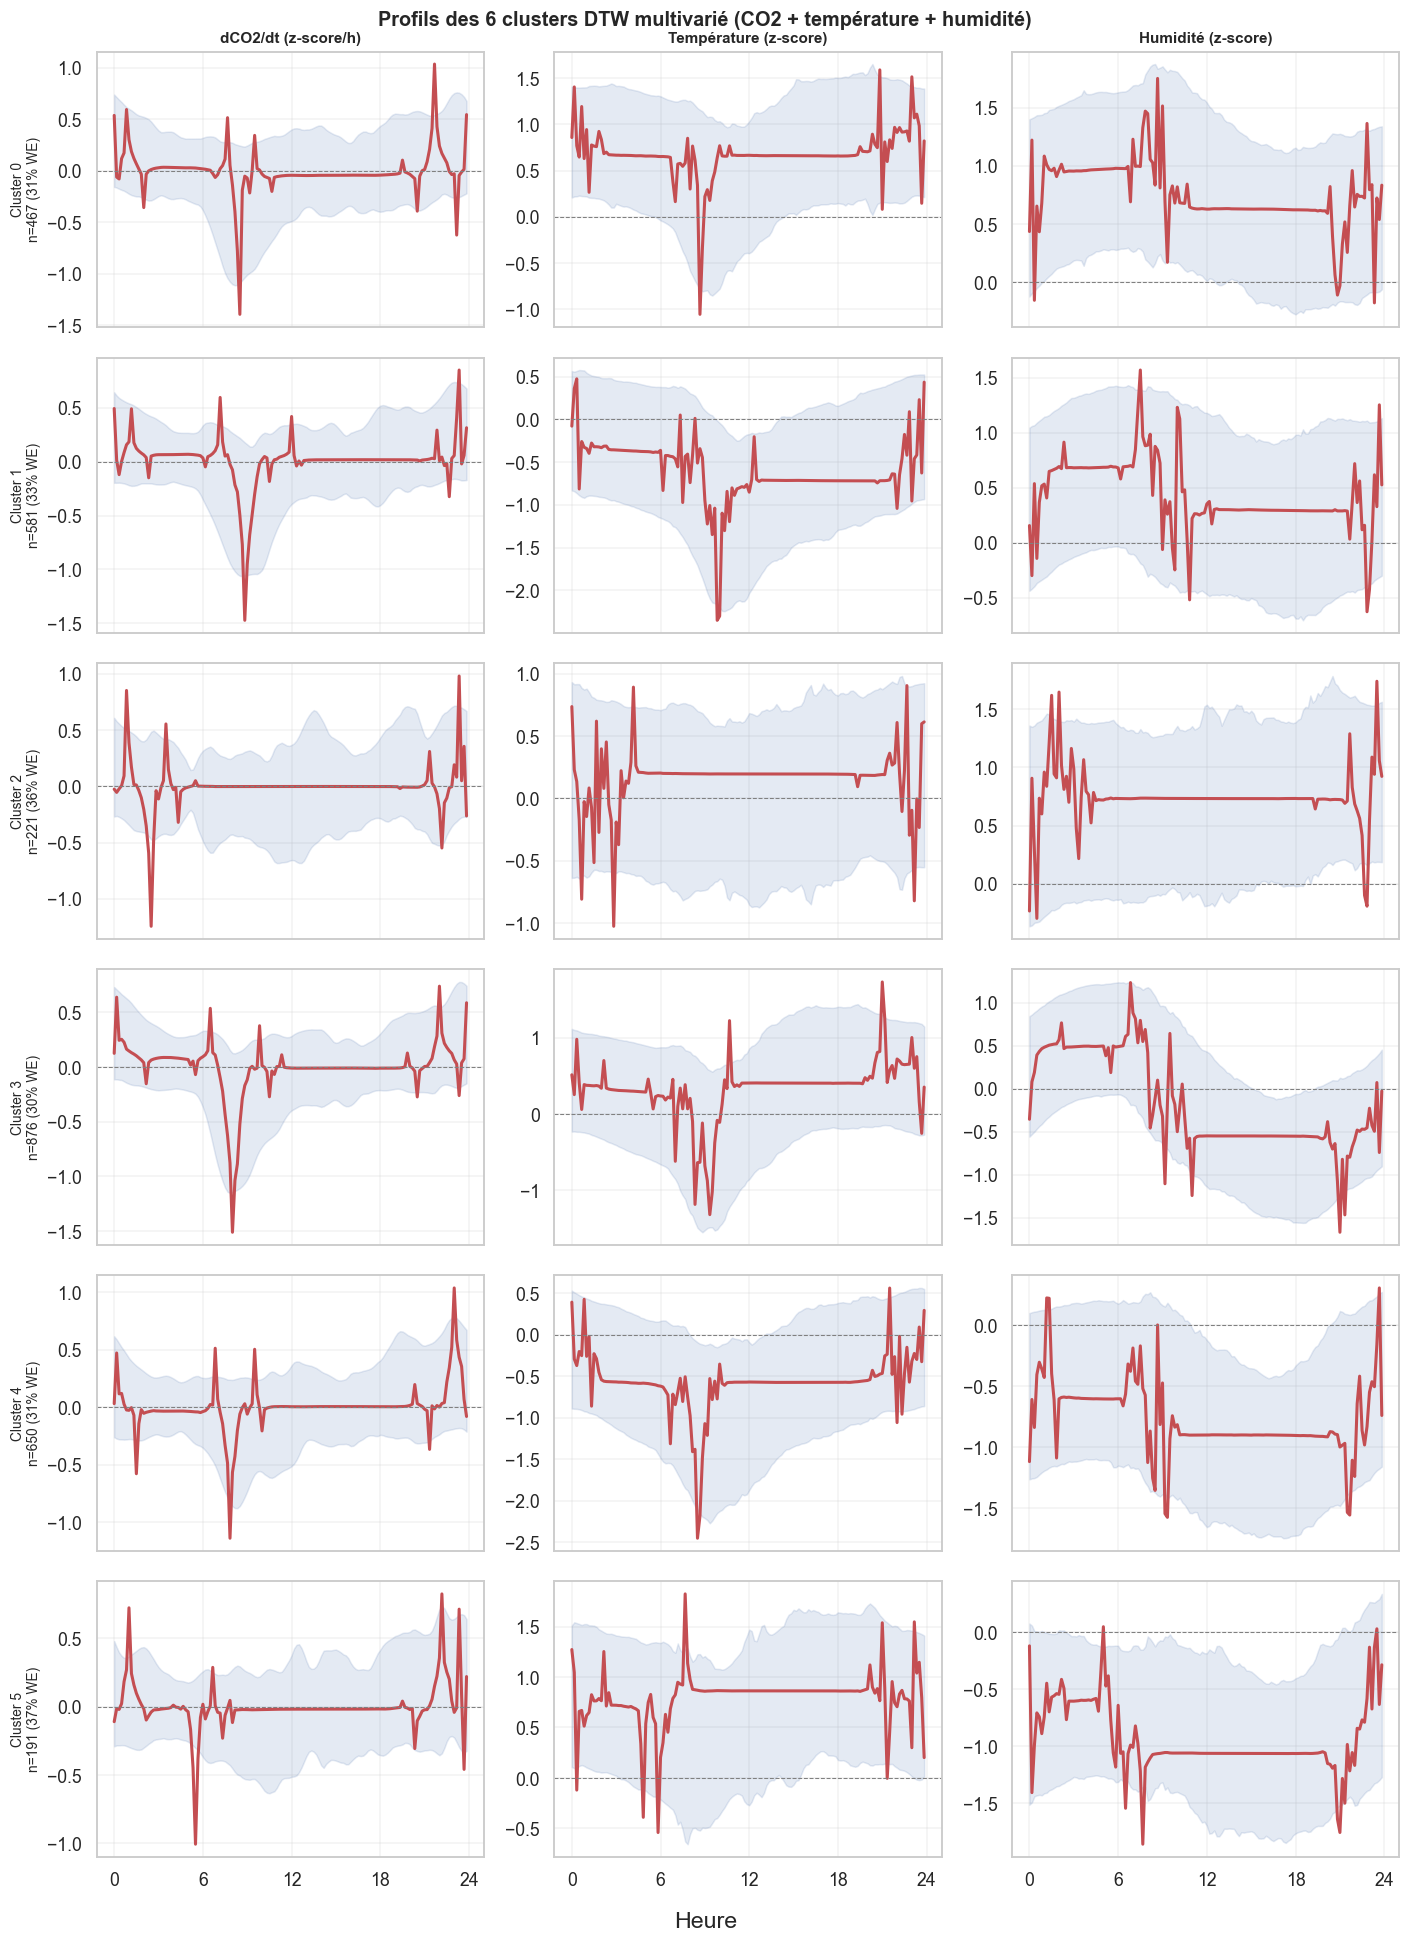

In [ ]:
CHANNEL_NAMES = ['dCO2/dt (z-score/h)', 'Température (z-score)', 'Humidité (z-score)']
hours = np.arange(144) / 6

fig, axes = plt.subplots(K_MULTI, 3, figsize=(13, 3 * K_MULTI), sharex=True)

for c in range(K_MULTI):
    sel = labels_multi == c
    n = sel.sum()
    pct_we = meta_multi.loc[sel, 'we'].mean() * 100
    bary = scaler_multi.inverse_transform(
        model_multi.cluster_centers_[c].reshape(-1, 3)).reshape(144, 3)

    for ch in range(3):
        ax = axes[c, ch]
        m = X_multi[sel, :, ch].mean(axis=0)
        s = X_multi[sel, :, ch].std(axis=0)
        ax.fill_between(hours, m - s, m + s, alpha=0.15, color='#4C72B0')
        ax.plot(hours, bary[:, ch], lw=2, color='#C44E52')
        ax.axhline(0, color='grey', lw=0.7, ls='--')
        ax.set_xticks([0, 6, 12, 18, 24])
        ax.grid(True, alpha=0.25)
        if c == 0:
            ax.set_title(CHANNEL_NAMES[ch], fontweight='bold', fontsize=10)
        if ch == 0:
            ax.set_ylabel(f'Cluster {c}\nn={n:,} ({pct_we:.0f}% WE)', fontsize=9)

fig.supxlabel('Heure')
plt.suptitle(f'Profils des {K_MULTI} clusters DTW multivarié (CO2 + température + humidité)',
            fontweight='bold', fontsize=13)
plt.tight_layout(); plt.show()


In [ ]:
# 2 journées individuelles tirées au hasard par cluster DTW multivarié
# — CO2 brut, dérivée CO2, température brute, humidité brute
EX_MULTI = pd.concat([d.sample(min(2, len(d)), random_state=42)
                     for _, d in meta_multi.groupby('cluster_multi')])
print('Journées affichées (2 par cluster DTW multivarié) :')
print(EX_MULTI[['CODELIEU', 'DATE', 'cluster_multi']].to_string(index=False))

# Valeurs brutes (non z-normalisées), alignées sur les mêmes lignes que X_multi
raw_co2_multi = piv_co2_lvl.loc[common_idx].values
raw_tpt_multi = piv_tpt.loc[common_idx].values
raw_hre_multi = piv_hre.loc[common_idx].values

PANELS = [
    ('CO2 brut (ppm)', raw_co2_multi),
    ('dCO2/dt (z-score/h)', D_multi),
    ('Température (°C)', raw_tpt_multi),
    ('Humidité (%)', raw_hre_multi),
]
colors_ex = ['#4C72B0', '#C44E52']

fig, axes = plt.subplots(len(PANELS), K_MULTI, figsize=(4 * K_MULTI, 3 * len(PANELS)), sharex=True)

for c in range(K_MULTI):
    sub = EX_MULTI[EX_MULTI['cluster_multi'] == c]
    for row, (label, arr) in enumerate(PANELS):
        ax = axes[row, c]
        for (idx, drow), color in zip(sub.iterrows(), colors_ex):
            ax.plot(hours, arr[idx], lw=1.4, color=color,
                    label=f"{drow['CODELIEU']} | {drow['DATE'].date()}")
        if row == 1:
            ax.axhline(0, color='grey', lw=0.7, ls='--')
        ax.set_xticks([0, 6, 12, 18, 24])
        ax.grid(True, alpha=0.25)
        if row == 0:
            ax.set_title(f'Cluster {c}', fontsize=10, fontweight='bold')
            ax.legend(fontsize=6.5, loc='upper right')
        if c == 0:
            ax.set_ylabel(label, fontsize=9)

fig.supxlabel('Heure')
plt.suptitle('2 journées individuelles par cluster DTW multivarié — CO2 brut, dérivée, température, humidité',
            fontweight='bold', fontsize=13)
plt.tight_layout(); plt.show()
